**Project Objective**

The objective of this project is to build a multitask deep learning model capable of accurately predicting both gender and age from facial images using the UTKFace dataset. This model will aim to achieve high performance across both tasks in a single pass by using multitask learning techniques and a convolutional neural network architecture.

We will be using accuracy as well f1 score metrics for gender classification. For age classification MAE and RMSE to compare different approaches.

#### Libraries

In [ ]:
!pip install optuna optuna-integration[pytorch_lightning] pytorch_lightning lime

In [ ]:
import os
import csv
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import random
import numpy as np
from PIL import Image
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam, SGD, AdamW
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision import models
from pytorch_lightning import Trainer, LightningModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from torchmetrics import Accuracy, MeanAbsoluteError
from torchmetrics.classification import BinaryAccuracy
import optuna
from optuna.integration.pytorch_lightning import PyTorchLightningPruningCallback
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_sample_weight
from lime.lime_image import LimeImageExplainer
from lime.wrappers.scikit_image import SegmentationAlgorithm
from skimage.segmentation import mark_boundaries

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Data load

In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
 99% 327M/331M [00:04<00:00, 92.3MB/s]
100% 331M/331M [00:04<00:00, 74.9MB/s]


In [ ]:
with zipfile.ZipFile("utkface-new.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/UTKFace")

In [ ]:
def load_utkface_data(data_path):
    file_paths = []
    ages = []
    genders = []
    races = []

    file_list = os.listdir(data_path)

    for file in file_list:
        if len(file.split("_")) >= 4:
            try:
                age, gender, race, *_ = file.split("_")
                file_paths.append(os.path.join(data_path, file))
                ages.append(int(age))
                genders.append(int(gender))
                races.append(int(race))
            except ValueError:
                print(f"Skipping file {file} due to a parsing error")
        else:
            print(f"Skipping file {file} due to format error")

    metadata_df = pd.DataFrame({
        'file_path': file_paths,
        'age': ages,
        'gender': genders,
        'race': races
    })

    return metadata_df

In [ ]:
data_path = "/content/UTKFace/UTKFace"
metadata_df = load_utkface_data(data_path)

Skipping file 61_1_20170109150557335.jpg.chip.jpg due to format error
Skipping file 61_1_20170109142408075.jpg.chip.jpg due to format error
Skipping file 39_1_20170116174525125.jpg.chip.jpg due to format error


#### Data split

**Data split** will be stratified by gender, age groups and race to insure we samples from each of these groups in all 3 sets. For training we will use 70% of the data, 15% for validation and 15% for testing.

In [ ]:
cleaned_metadata_df = pd.read_csv('/content/cleaned_metadata.csv')

In [ ]:
cleaned_metadata_df['composite_label'] = cleaned_metadata_df['gender'].astype(str) + '-' + cleaned_metadata_df['age_group'].astype(str) + '-' + cleaned_metadata_df['race'].astype(str)

In [ ]:
train_data, temp_data = train_test_split(
    cleaned_metadata_df, test_size=0.3, stratify=cleaned_metadata_df['composite_label'], random_state=42
)

val_data, test_data = train_test_split(
    temp_data, test_size=0.5, stratify=temp_data['composite_label'], random_state=42
)

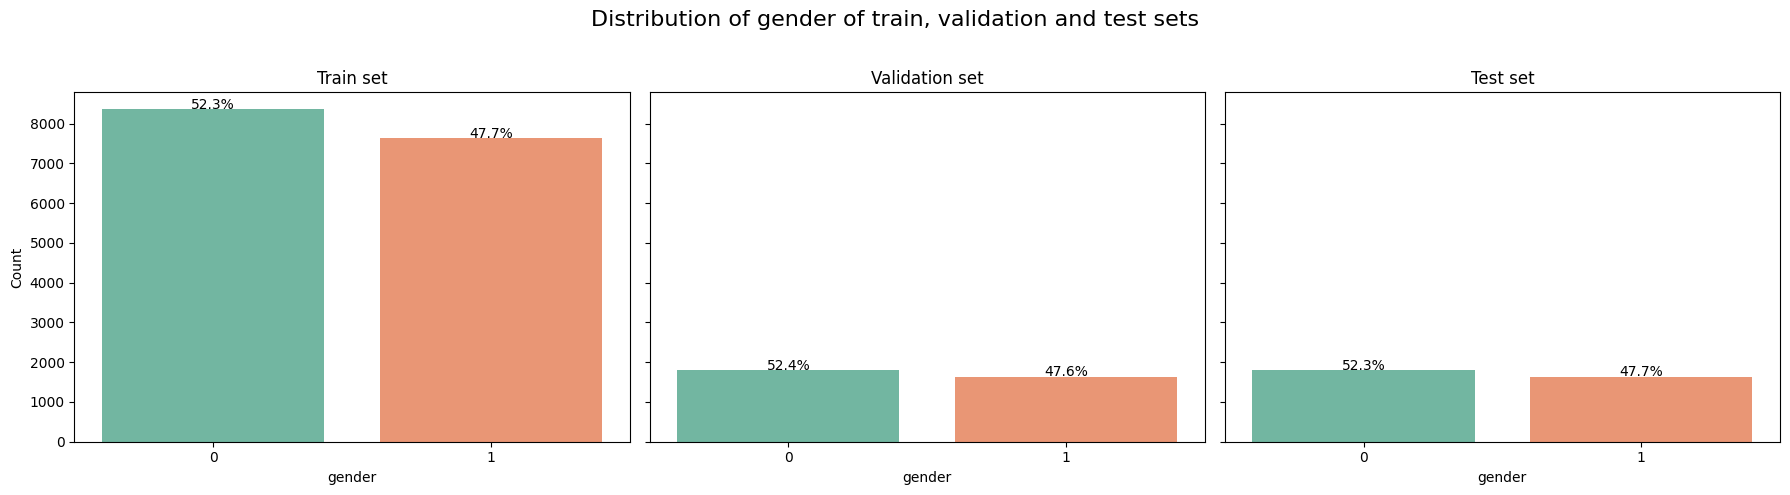

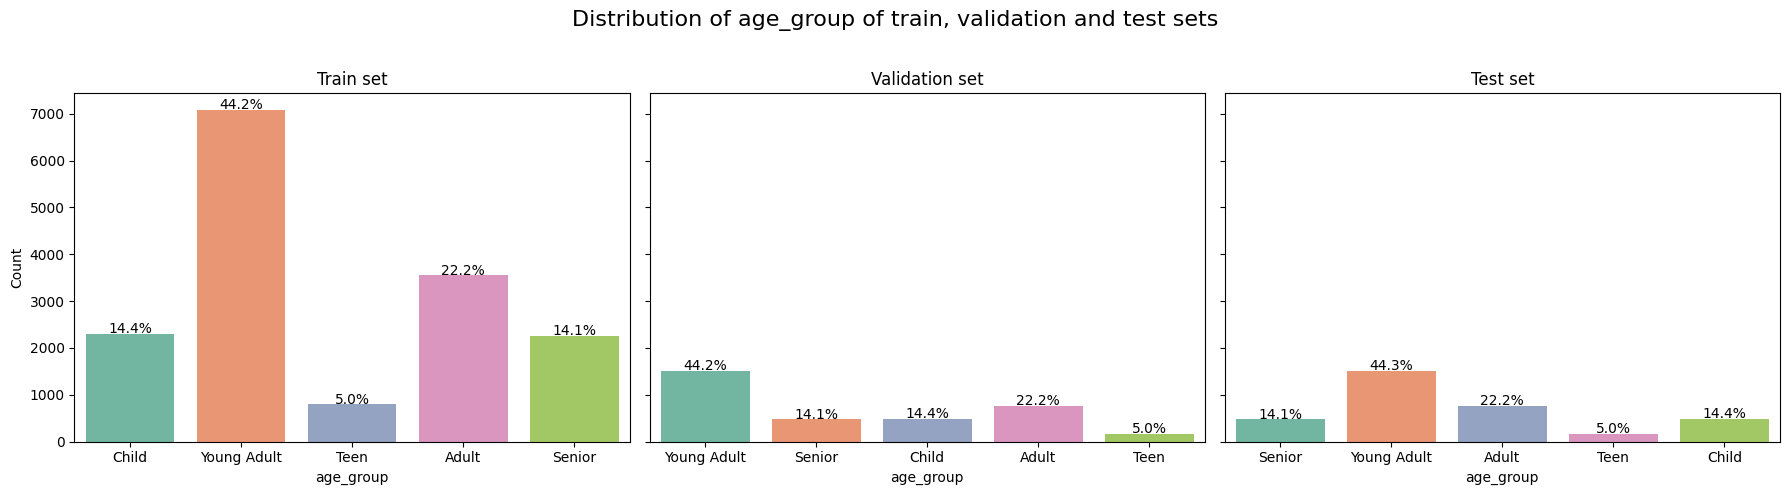

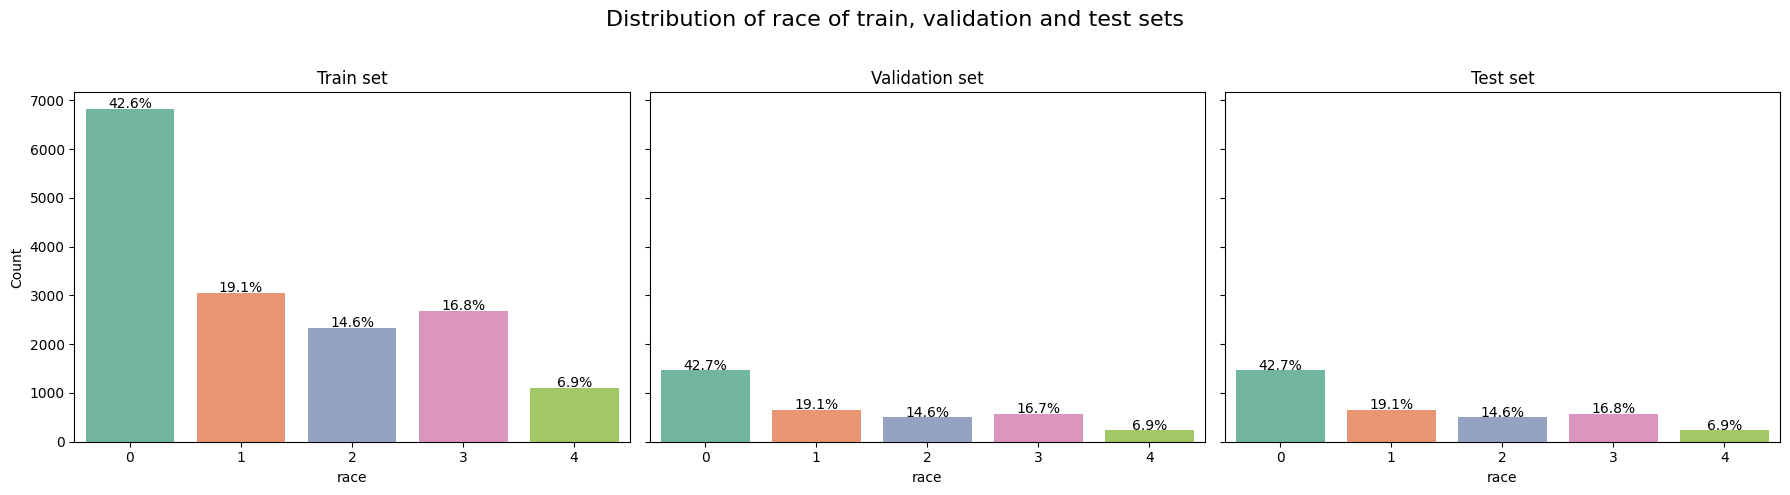

In [ ]:
def plot_distribution_by_attribute(train_data, val_data, test_data, attribute):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f"Distribution of {attribute} of train, validation and test sets", fontsize=16)

    sns.countplot(x=attribute, data=train_data, ax=axes[0], hue=attribute, palette="Set2", legend=False)
    axes[0].set_title("Train set")
    axes[0].set_ylabel("Count")
    axes[0].set_xlabel(attribute)
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height() / len(train_data) * 100:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height() + 10), ha="center")

    sns.countplot(x=attribute, data=val_data, ax=axes[1], hue=attribute, palette="Set2", legend=False)
    axes[1].set_title("Validation set")
    axes[1].set_xlabel(attribute)
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height() / len(val_data) * 100:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height() + 10), ha="center")

    sns.countplot(x=attribute, data=test_data, ax=axes[2], hue=attribute, palette="Set2", legend=False)
    axes[2].set_title("Test set")
    axes[2].set_xlabel(attribute)
    for p in axes[2].patches:
        axes[2].annotate(f"{p.get_height() / len(test_data) * 100:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height() + 10), ha="center")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_distribution_by_attribute(train_data, val_data, test_data, "gender")
plot_distribution_by_attribute(train_data, val_data, test_data, "age_group")
plot_distribution_by_attribute(train_data, val_data, test_data, "race")

#### Baseline model

We have selected MobileNetV2 as the starting point for this project because it could provide a good balance between performance and efficiency. While less complex models could potentially perform well many similar prediction tasks have opted for MobileNet models due to their proven ability to deliver a good performance. Given that this gender and age predictions we evaluate this multi- task as having a medium level of risk which largely depends on the specific application, meaning we will be prioritizing accuracy over explainability, however we will evaluate model biases.

Images are padded to have 224x224 pixels as it is expected input size for MobileNetV2. Images are also normalized to match the mean and standard deviation of ImageNet images.

In [ ]:
def get_transform():
    return transforms.Compose([
        transforms.Pad((12, 12, 12, 12)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

In [ ]:
class AgeGenderDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['file_path']
        image = Image.open(img_path).convert('RGB')
        gender = self.dataframe.iloc[idx]['gender']
        age = self.dataframe.iloc[idx]['age']

        if self.transform:
            image = self.transform(image)

        return image, (torch.tensor(gender, dtype=torch.float32), torch.tensor(age, dtype=torch.float32))

In [ ]:
class AgeGenderDataModule(pl.LightningDataModule):
    def __init__(self, train_df, val_df, test_df, batch_size=32):
        super().__init__()
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.batch_size = batch_size
        self.transform = get_transform()

    def setup(self, stage=None):
        self.train_dataset = AgeGenderDataset(self.train_df, transform=self.transform)
        self.val_dataset = AgeGenderDataset(self.val_df, transform=self.transform)
        self.test_dataset = AgeGenderDataset(self.test_df, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2)

In this first experiment we have modify the MobileNetV2 by replacing its output layers with custom layers for gender and age prediction. This model is designed to perform both tasks at the same time:

**Gender Classification:** Will be optimized using binary crossentropy loss with sigmoid activation function to produce probabilities.

**Age Regression:** It will be optimized using mean squared error.

**The total loss** is the sum of both losses.

For feature extraction we are going to use a global average pooling layer to aggregate spatial features. We will also be using a randomly selected learning rate of 0.0001, which is relativly low and should do fine as of beggining and Adam optimizer as it is a commonly used and reliable choice. We have selected batch size 32.

In [ ]:
class AgeGenderModelMobileNetFeatureExtract(pl.LightningModule):
    def __init__(self, learning_rate=0.0001):
        super(AgeGenderModelMobileNetFeatureExtract, self).__init__()
        self.base_model = models.mobilenet_v2(weights="MobileNet_V2_Weights.IMAGENET1K_V1")
        self.base_model.classifier = nn.Identity()

        for param in self.base_model.parameters():
            param.requires_grad = False

        in_features = self.base_model.last_channel

        self.gender_output = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.Sigmoid()
        )
        self.age_output = nn.Linear(in_features, 1)

        self.gender_accuracy = BinaryAccuracy()
        self.age_mae = MeanAbsoluteError()

        self.gender_loss_fn = nn.BCELoss()
        self.age_loss_fn = nn.MSELoss()

        self.learning_rate = learning_rate

    def forward(self, x):
        features = self.base_model.features(x)
        pooled_features = features.mean([2, 3]) #GAP

        gender_pred = self.gender_output(pooled_features).squeeze()
        age_pred = self.age_output(pooled_features).squeeze()

        return gender_pred, age_pred

    def training_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels.float())
        age_loss = self.age_loss_fn(age_pred, age_labels.float())
        total_loss = gender_loss + age_loss

        self.log("train_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("train_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("train_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("train_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def validation_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels.float())
        age_loss = self.age_loss_fn(age_pred, age_labels.float())
        total_loss = gender_loss + age_loss

        self.log("val_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("val_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("val_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("val_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("val_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def configure_optimizers(self):
        return Adam(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=self.learning_rate
        )

In [ ]:
csv_logger = CSVLogger("logs", name="AgeGenderModelBase")

In [ ]:
early_stopping = EarlyStopping(monitor='val_total_loss', patience=5, mode='min')

In [ ]:
checkpoint_callback = ModelCheckpoint(monitor='val_total_loss', save_top_k=1, mode='min', filename='best-checkpoint')

In [ ]:
data_module = AgeGenderDataModule(train_df=train_data, val_df=val_data, test_df=test_data, batch_size=32)

In [ ]:
base_model = AgeGenderModelMobileNetFeatureExtract(learning_rate=0.0001)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 98.4MB/s]


In [ ]:
trainer = pl.Trainer(
    max_epochs=20,
    log_every_n_steps=1,
    logger=csv_logger,
    callbacks=[early_stopping, checkpoint_callback]
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(base_model, data_module)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type              | Params | Mode 
--------------------------------------------------------------
0 | base_model      | MobileNetV2       | 2.2 M  | train
1 | gender_output   | Sequential        | 1.3 K  | train
2 | age_output      | Linear            | 1.3 K  | train
3 | gender_accuracy | BinaryAccuracy    | 0      | train
4 | age_mae         | MeanAbsoluteError | 0      | train
5 | gender_loss_fn  | BCELoss           | 0      | train
6 | age_loss_fn     | MSELoss           | 0      | train
--------------------------------------------------------------
2.6 K     Trainable params
2.2 M     Non-trainable params
2.2 M     Total params
8.906     Total estimated model params size (MB)
219       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


In [ ]:
base_model.eval()

In [ ]:
gender_preds = []
gender_labels = []
age_preds = []
age_labels = []

for batch in data_module.val_dataloader():
    images, (gender, age) = batch
    with torch.no_grad():
        gender_pred, age_pred = base_model(images)

    gender_preds.extend((gender_pred > 0.5).int().cpu().numpy())
    gender_labels.extend(gender.cpu().numpy())
    age_preds.extend(age_pred.cpu().numpy())
    age_labels.extend(age.cpu().numpy())

gender_preds = np.array(gender_preds)
gender_labels = np.array(gender_labels)
age_preds = np.array(age_preds)
age_labels = np.array(age_labels)

In [ ]:
print("Gender classification report:")
print(classification_report(gender_labels, gender_preds, target_names=["Male", "Female"]))

Gender classification report:
              precision    recall  f1-score   support

        Male       0.83      0.83      0.83      1794
      Female       0.81      0.81      0.81      1636

    accuracy                           0.82      3430
   macro avg       0.82      0.82      0.82      3430
weighted avg       0.82      0.82      0.82      3430



The gender classification report shows an accuracy of 82%, with quite balanced precision, recall and F1-scores for both classes.

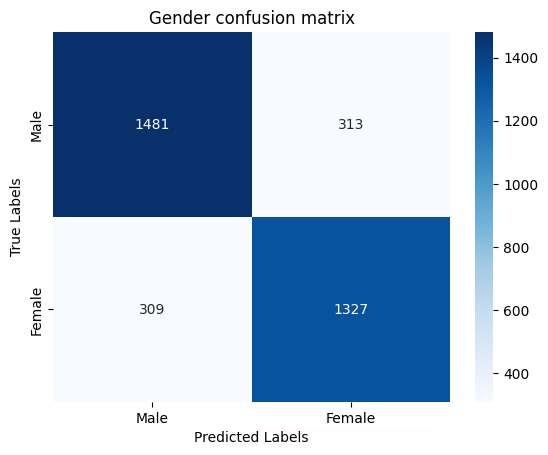

In [ ]:
conf_matrix = confusion_matrix(gender_labels, gender_preds)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Gender confusion matrix")
plt.show()

The confusion matrix indicates a reasonable degree of accuracy for both male and female classes.

In [ ]:
age_mae = mean_absolute_error(age_labels, age_preds)
age_rmse = mean_squared_error(age_labels, age_preds, squared=False)

print(f"Age MAE: {age_mae:.2f}")
print(f"Age RMSE: {age_rmse:.2f}")

Age MAE: 10.76
Age RMSE: 13.84


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Mean absolute error for age prediction is 10.76 and root mean squared error is 13.84 suggesting that model can capture age values ok, but errors as of this model set up are quite high.


In [ ]:
log_dir = "logs/AgeGenderModelBase/version_0/metrics.csv"
loss_data = pd.read_csv(log_dir)

In [ ]:
train_data_loss = loss_data[loss_data['train_age_loss'].notna()]
val_data_loss = loss_data[loss_data['val_age_loss'].notna()]

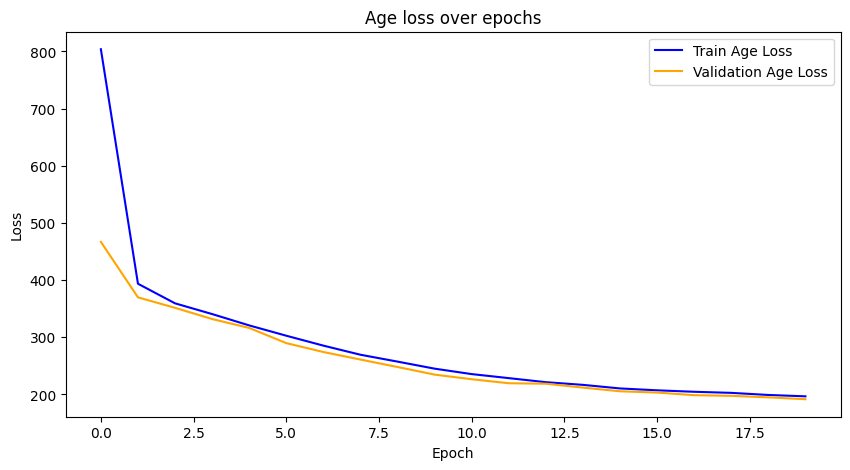

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_age_loss'], label='Train Age Loss', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_age_loss'], label='Validation Age Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Age loss over epochs')
plt.legend()
plt.show()

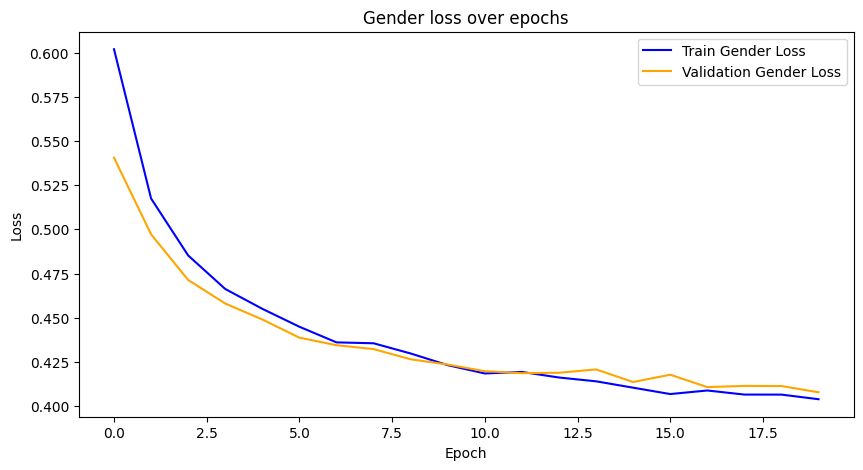

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_gender_loss'], label='Train Gender Loss', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_gender_loss'], label='Validation Gender Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Gender loss over epochs')
plt.legend()
plt.show()

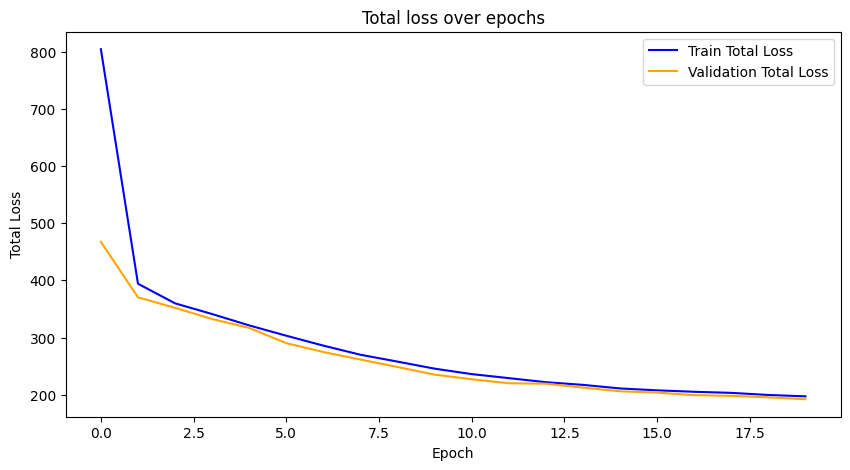

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_total_loss'], label='Train Total Loss', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_total_loss'], label='Validation Total Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Total loss over epochs')
plt.legend()
plt.show()

Loss curves for gender, age and total loss demonstrate steady convergence indicating that the model trains efficiently. This even suggests that increasing the number of epochs could further improve performance as the model does not appear to be overfitting and still shows potential.

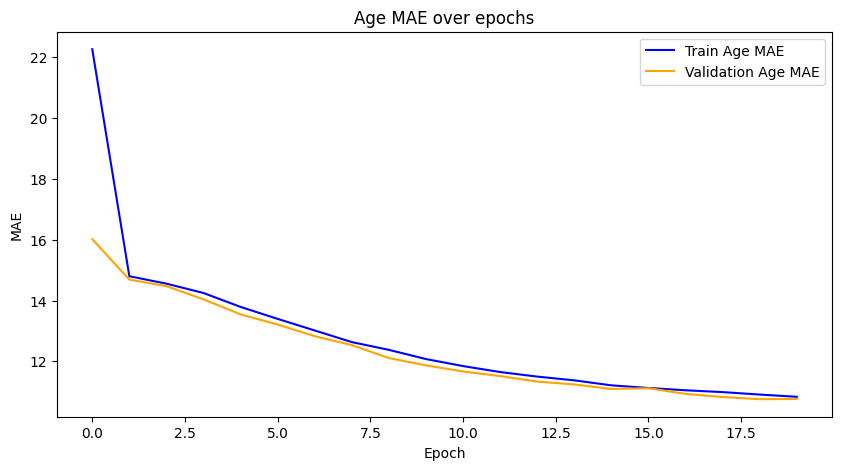

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_age_mae'], label='Train Age MAE', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_age_mae'], label='Validation Age MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age MAE over epochs')
plt.legend()
plt.show()

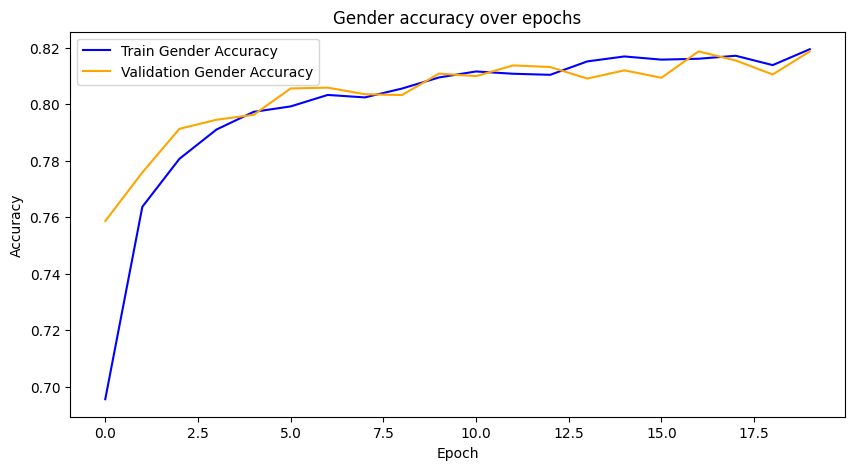

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_gender_accuracy'], label='Train Gender Accuracy', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_gender_accuracy'], label='Validation Gender Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender accuracy over epochs')
plt.legend()
plt.show()

Accuracy for gender steadily improves during training. Fluctuations in validations accuracy shows that model might be converging and enough epochs have been selected after all.

##### Model with max pooling instead of GAP

In the following part we will explore the use of global max pooling as an alternative to the global average pooling (GAP) used before. While GAP aggregates the mean of spatial features, max pooling focuses on the most outstanding features which might be beneficial in gender and age predictions.

In [ ]:
class AgeGenderModelMobileNetFeatureExtractMaxPool(pl.LightningModule):
    def __init__(self, learning_rate=1e-4):
        super(AgeGenderModelMobileNetFeatureExtractMaxPool, self).__init__()
        self.base_model = models.mobilenet_v2(weights="MobileNet_V2_Weights.IMAGENET1K_V1")
        self.base_model.classifier = nn.Identity()

        for param in self.base_model.parameters():
            param.requires_grad = False

        in_features = self.base_model.last_channel

        self.gender_output = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.Sigmoid()
        )
        self.age_output = nn.Linear(in_features, 1)

        self.gender_accuracy = BinaryAccuracy()
        self.age_mae = MeanAbsoluteError()
        self.gender_loss_fn = nn.BCELoss()
        self.age_loss_fn = nn.MSELoss()

        self.learning_rate = learning_rate

    def forward(self, x):
        features = self.base_model.features(x)

        # max pooling
        pooled_features = features.max(dim=2)[0].max(dim=2)[0]

        gender_pred = self.gender_output(pooled_features).squeeze()
        age_pred = self.age_output(pooled_features).squeeze()

        return gender_pred, age_pred

    def training_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels.float())
        age_loss = self.age_loss_fn(age_pred, age_labels.float())
        total_loss = gender_loss + age_loss

        self.log("train_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("train_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("train_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("train_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def validation_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels.float())
        age_loss = self.age_loss_fn(age_pred, age_labels.float())
        total_loss = gender_loss + age_loss

        self.log("val_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("val_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("val_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("val_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("val_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def configure_optimizers(self):
        return Adam(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=self.learning_rate
        )

In [ ]:
csv_logger = CSVLogger("logs", name="AgeGenderModelBaseMaxpool")

In [ ]:
base_model_maxpool = AgeGenderModelMobileNetFeatureExtractMaxPool(learning_rate=1e-4)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 147MB/s]


In [ ]:
trainer = pl.Trainer(
    max_epochs=20,
    log_every_n_steps=1,
    logger=csv_logger,
    callbacks=[early_stopping, checkpoint_callback]
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(base_model_maxpool, data_module)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type              | Params | Mode 
--------------------------------------------------------------
0 | base_model      | MobileNetV2       | 2.2 M  | train
1 | gender_output   | Sequential        | 1.3 K  | train
2 | age_output      | Linear            | 1.3 K  | train
3 | gender_accuracy | BinaryAccuracy    | 0      | train
4 | age_mae         | MeanAbsoluteError | 0      | train
5 | gender_loss_fn  | BCELoss           | 0      | train
6 | age_loss_fn     | MSELoss           | 0      | train
--------------------------------------------------------------
2.6 K     Trainable params
2.2 M     Non-trainable params
2.2 M     Total params
8.906     Total estimated model params size (MB)
219       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


In [ ]:
base_model_maxpool.eval()

In [ ]:
gender_preds = []
gender_labels = []
age_preds = []
age_labels = []

for batch in data_module.val_dataloader():
    images, (gender, age) = batch
    with torch.no_grad():
        gender_pred, age_pred = base_model_maxpool(images)

    gender_preds.extend((gender_pred > 0.5).int().cpu().numpy())
    gender_labels.extend(gender.cpu().numpy())
    age_preds.extend(age_pred.cpu().numpy())
    age_labels.extend(age.cpu().numpy())

gender_preds = np.array(gender_preds)
gender_labels = np.array(gender_labels)
age_preds = np.array(age_preds)
age_labels = np.array(age_labels)

In [ ]:
print("Gender classification report:")
print(classification_report(gender_labels, gender_preds, target_names=["Male", "Female"]))

Gender classification report:
              precision    recall  f1-score   support

        Male       0.76      0.91      0.82      1796
      Female       0.87      0.68      0.76      1634

    accuracy                           0.80      3430
   macro avg       0.81      0.79      0.79      3430
weighted avg       0.81      0.80      0.79      3430



Classification results a bit worse than with GAP. Accuracy is 81% and f1 score is 79% while previous feature extraction model with GAP had:



```
Gender classification report:
              precision    recall  f1-score   support

        Male       0.83      0.83      0.83      1794
      Female       0.81      0.81      0.81      1636

    accuracy                           0.82      3430
   macro avg       0.82      0.82      0.82      3430
weighted avg       0.82      0.82      0.82      3430
```

In [ ]:
conf_matrix = confusion_matrix(gender_labels, gender_preds)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Gender confusion matrix")
plt.show()

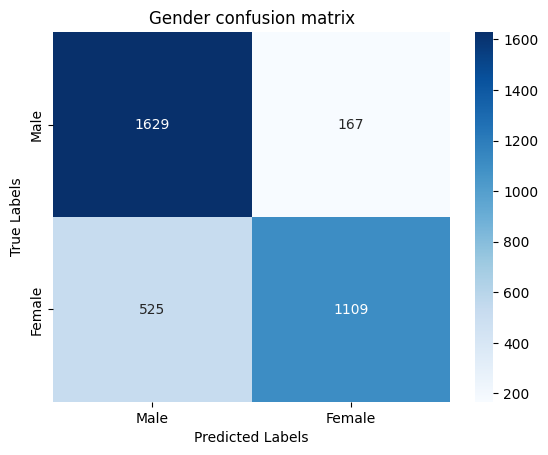

Confusion matrix as what classification report has shown is a lot more imbalanced, max pooling resulted in better males classification than females.

In [ ]:
age_mae = mean_absolute_error(age_labels, age_preds)
age_rmse = mean_squared_error(age_labels, age_preds, squared=False)

print(f"Age MAE: {age_mae:.2f}")
print(f"Age RMSE: {age_rmse:.2f}")

Age MAE: 10.53
Age RMSE: 13.60


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Age MAE and RMSE improved just by a few decimal points:

Before: Age MAE: 10.76,
Age RMSE: 13.84

In [ ]:
log_dir = "logs/AgeGenderModelBaseMaxpool/version_0/metrics.csv"
loss_data = pd.read_csv(log_dir)

In [ ]:
train_data_loss = loss_data[loss_data['train_age_loss'].notna()]
val_data_loss = loss_data[loss_data['val_age_loss'].notna()]

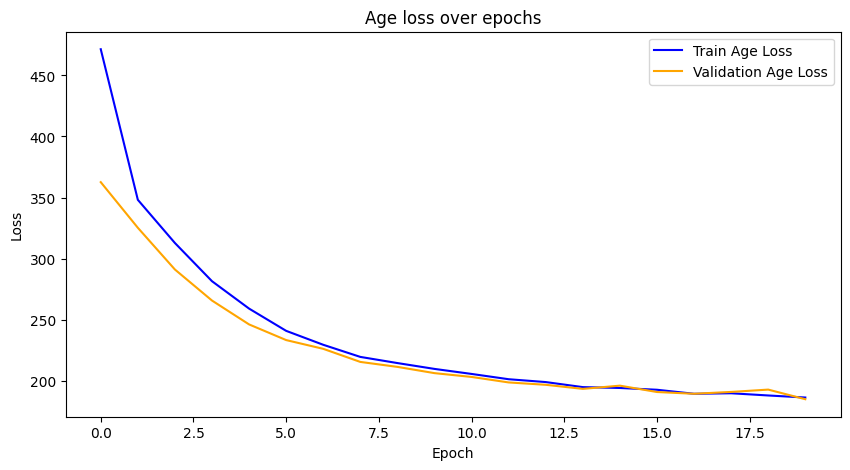

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_age_loss'], label='Train Age Loss', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_age_loss'], label='Validation Age Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Age loss over epochs')
plt.legend()
plt.show()

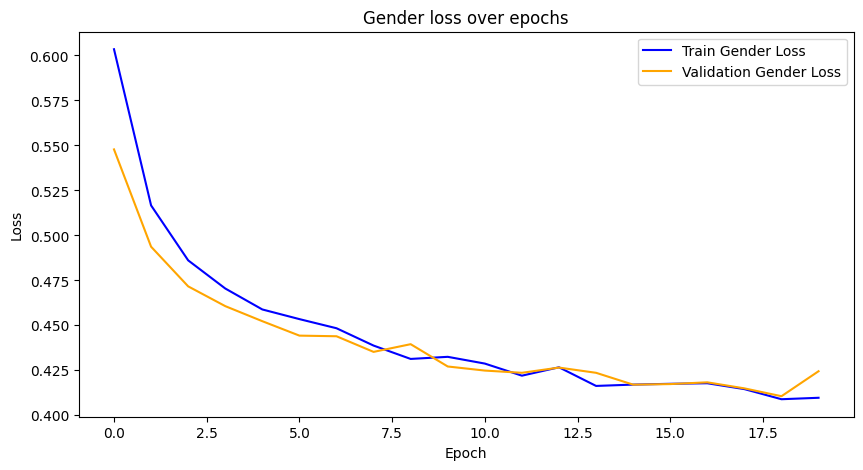

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_gender_loss'], label='Train Gender Loss', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_gender_loss'], label='Validation Gender Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Gender loss over epochs')
plt.legend()
plt.show()

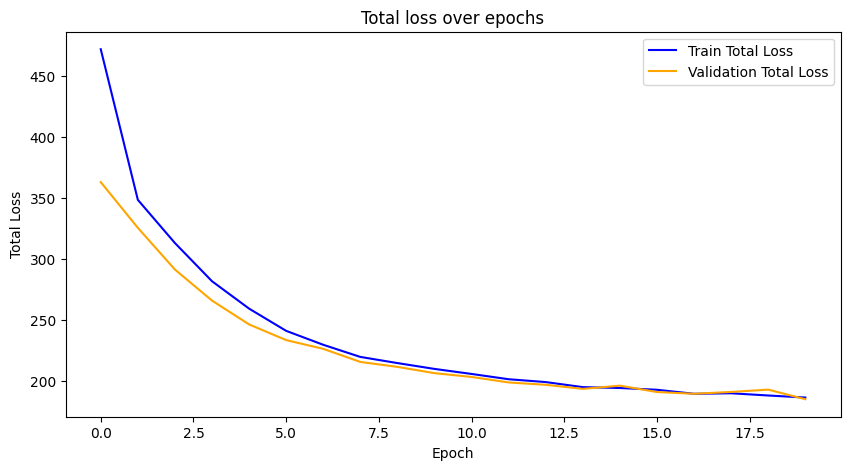

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_total_loss'], label='Train Total Loss', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_total_loss'], label='Validation Total Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Total loss over epochs')
plt.legend()
plt.show()

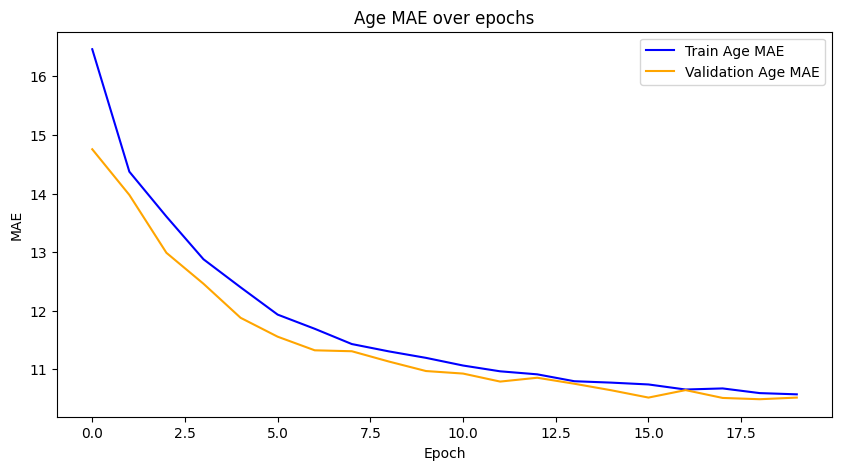

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_age_mae'], label='Train Age MAE', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_age_mae'], label='Validation Age MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age MAE over epochs')
plt.legend()
plt.show()

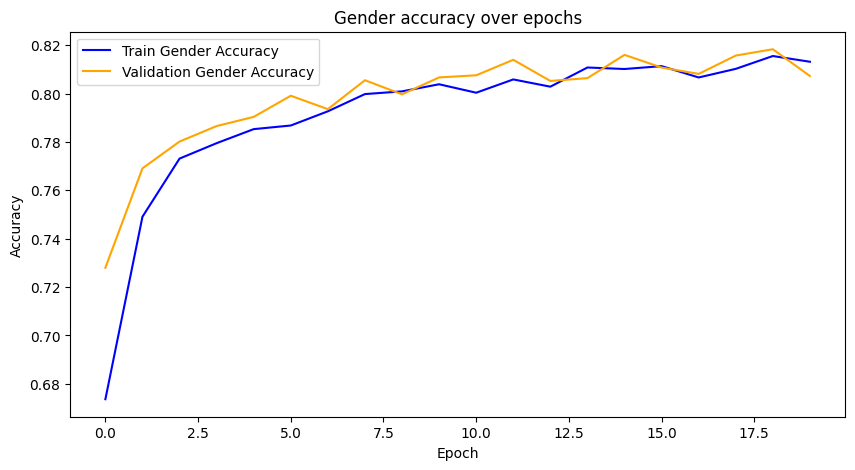

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_gender_accuracy'], label='Train Gender Accuracy', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_gender_accuracy'], label='Validation Gender Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender accuracy over epochs')
plt.legend()
plt.show()

Loss and accuracy trends over epochs do not show significant differences compared to the first experiment. The training remains stable and the model appears to be converging.

##### Model with standadized age values

In the following baseline model exploration we standardize age values using the training set mean and standard deviation. This transformation centers the age values around zero with a variance of 1. This might help the model to handle the continuous age values better. Since max pooling showed worse results for gender classification and only slightly better age MAE we will be using GAP through out the project.

In [ ]:
age_mean = train_data['age'].mean()
age_std = train_data['age'].std()

In [ ]:
class AgeGenderDataset(Dataset):
    def __init__(self, dataframe, transform=None, normalize_age=True):
        self.dataframe = dataframe
        self.transform = transform
        self.normalize_age = normalize_age

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['file_path']
        image = Image.open(img_path).convert('RGB')
        gender = self.dataframe.iloc[idx]['gender']
        age = self.dataframe.iloc[idx]['age']

        if self.normalize_age:
            age = (age - age_mean) / age_std

        if self.transform:
            image = self.transform(image)

        return image, (torch.tensor(gender, dtype=torch.float32), torch.tensor(age, dtype=torch.float32))

In [ ]:
csv_logger = CSVLogger("logs", name="AgeGenderModelBaseAgeNorm")

In [ ]:
base_model_normage = AgeGenderModelMobileNetFeatureExtract(learning_rate=1e-4)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 47.6MB/s]


In [ ]:
trainer = pl.Trainer(
    max_epochs=20,
    log_every_n_steps=1,
    logger=csv_logger,
    callbacks=[early_stopping, checkpoint_callback]
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(base_model_normage, data_module)

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory logs/AgeGenderModelBaseAgeNorm/version_0/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type              | Params | Mode 
--------------------------------------------------------------
0 | base_model      | MobileNetV2       | 2.2 M  | train
1 | gender_output   | Sequential        | 1.3 K  | train
2 | age_output      | Linear            | 1.3 K  | train
3 | gender_accuracy | BinaryAccuracy    | 0      | train
4 | age_mae         | MeanAbsoluteError | 0      | train
5 | gender_loss_fn  | BCELoss           | 0      | train
6 | age_loss_fn     | MSELoss           | 0      | train
--------------------------------------------------------------
2.6 K     Trainable params
2.2 M     Non-trainable params
2.2 M     Total params
8.906     Tota

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


In [ ]:
base_model_normage.eval()

In [ ]:
gender_preds = []
gender_labels = []
age_preds = []
age_labels = []

for batch in data_module.val_dataloader():
    images, (gender, age) = batch
    with torch.no_grad():
        gender_pred, age_pred = base_model_normage(images)

    gender_preds.extend((gender_pred > 0.5).int().cpu().numpy())
    gender_labels.extend(gender.cpu().numpy())
    age_preds.extend(age_pred.cpu().numpy())
    age_labels.extend(age.cpu().numpy())

gender_preds = np.array(gender_preds)
gender_labels = np.array(gender_labels)
age_preds = np.array(age_preds)
age_labels = np.array(age_labels)

In [ ]:
print("Gender classification report:")
print(classification_report(gender_labels, gender_preds, target_names=["Male", "Female"]))

Gender classification report:
              precision    recall  f1-score   support

        Male       0.82      0.84      0.83      1796
      Female       0.82      0.80      0.81      1634

    accuracy                           0.82      3430
   macro avg       0.82      0.82      0.82      3430
weighted avg       0.82      0.82      0.82      3430



Neither accuracy nor f1 score have improved, there are some slight changes in each class precision and recall metrics, however f1 score in each group is the same. It is expected as the only change made compared to the first expirement is related to the age regression part. Previous model's results:

```
Gender classification report:
              precision    recall  f1-score   support

        Male       0.83      0.83      0.83      1794
      Female       0.81      0.81      0.81      1636

    accuracy                           0.82      3430
   macro avg       0.82      0.82      0.82      3430
weighted avg       0.82      0.82      0.82      3430
```



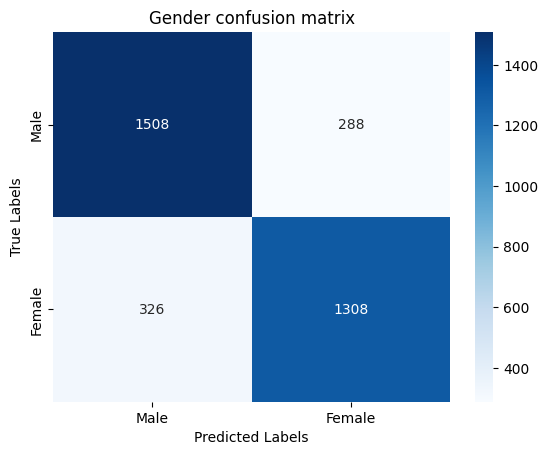

In [ ]:
conf_matrix = confusion_matrix(gender_labels, gender_preds)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Gender confusion matrix")
plt.show()

Even though classification report did not show any significant differences we can see more clearly that age standartization changed results a little bit in gender classification as well. We do have few less missclassifications. 614 < 622, First basemodel with GAP confosion matrix:

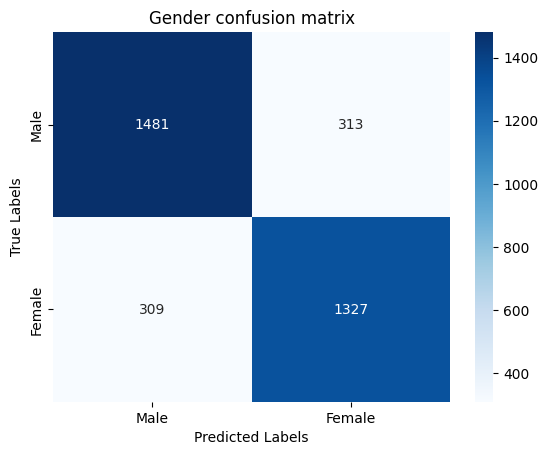

Also models performance on females is slightly worse which aligns with our  finding in the EDA that dataset is slightly imbalanced in terms of gender. These differences in both sample distribution and features quality may have an influence to the models ability to generalize across genders.

In [ ]:
age_preds = age_preds * age_std + age_mean
age_labels = age_labels * age_std + age_mean

In [ ]:
age_mae = mean_absolute_error(age_labels, age_preds)
age_rmse = mean_squared_error(age_labels, age_preds, squared=False)

print(f"Age MAE: {age_mae:.2f}")
print(f"Age RMSE: {age_rmse:.2f}")

Age MAE: 9.58
Age RMSE: 12.37


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Normalized age values did improve age predictions by even more than 1 year. Previous results:

Age MAE: 10.76,
Age RMSE: 13.84

In [ ]:
log_dir = "logs/AgeGenderModelBaseAgeNorm/version_0/metrics.csv"
loss_data = pd.read_csv(log_dir)

In [ ]:
train_data_loss = loss_data[loss_data['train_age_loss'].notna()]
val_data_loss = loss_data[loss_data['val_age_loss'].notna()]

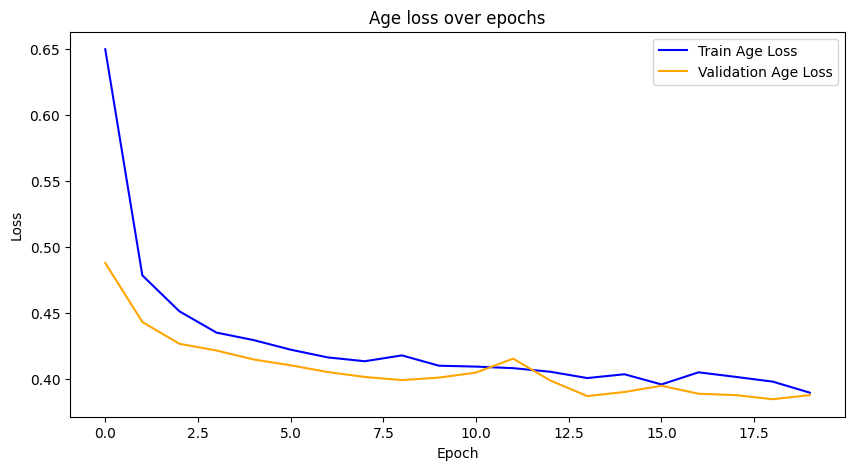

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_age_loss'], label='Train Age Loss', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_age_loss'], label='Validation Age Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Age loss over epochs')
plt.legend()
plt.show()

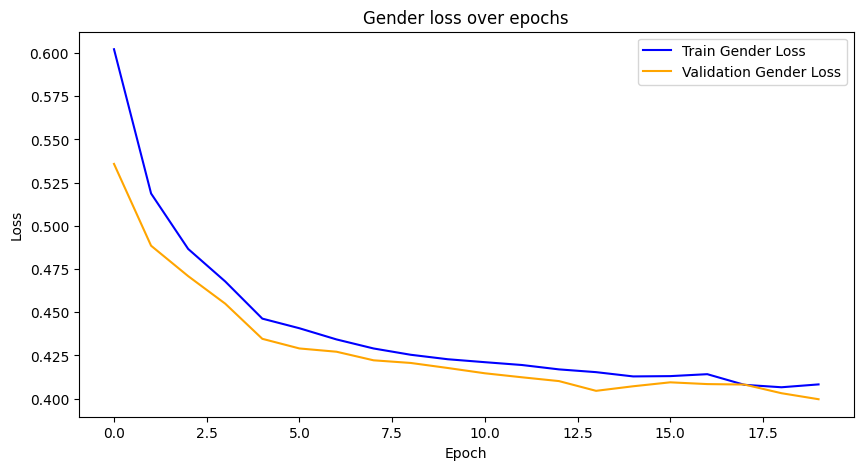

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_gender_loss'], label='Train Gender Loss', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_gender_loss'], label='Validation Gender Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Gender loss over epochs')
plt.legend()
plt.show()

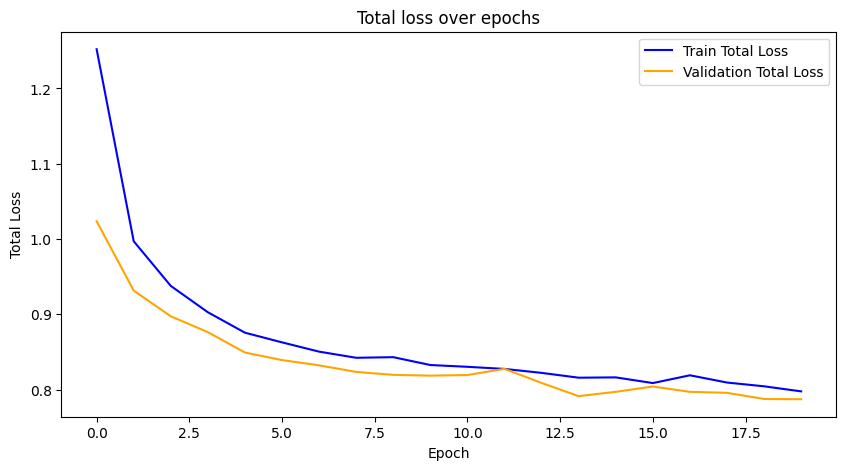

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_total_loss'], label='Train Total Loss', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_total_loss'], label='Validation Total Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Total loss over epochs')
plt.legend()
plt.show()

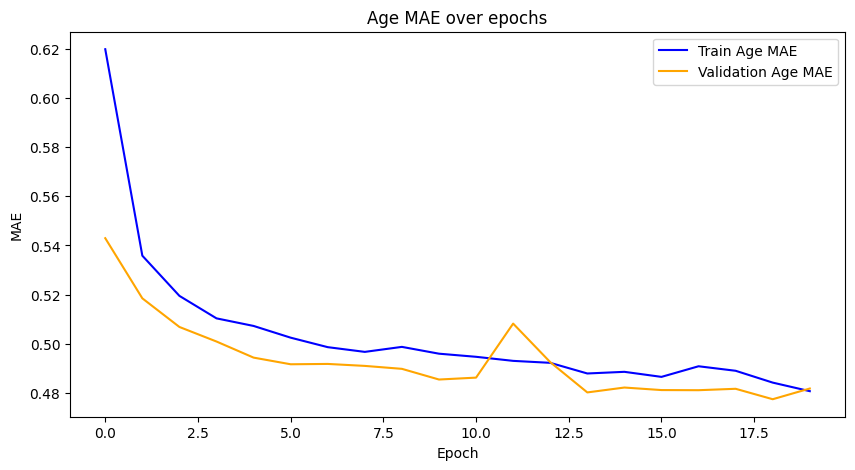

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_age_mae'], label='Train Age MAE', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_age_mae'], label='Validation Age MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age MAE over epochs')
plt.legend()
plt.show()

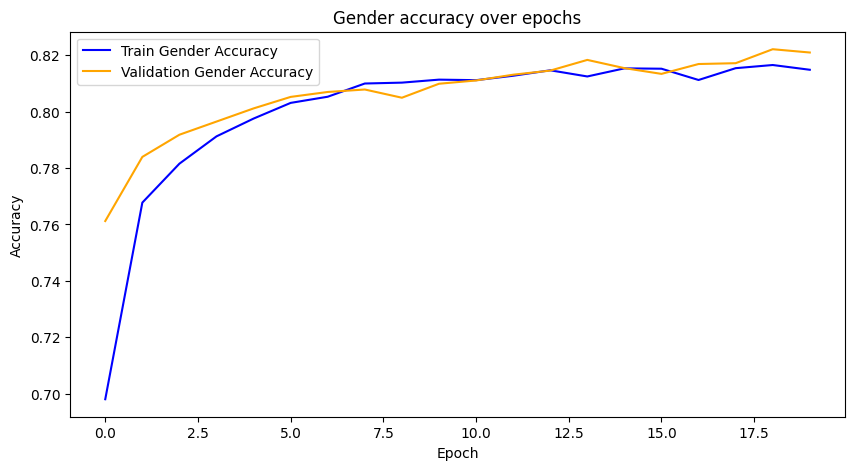

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_loss['epoch'], train_data_loss['train_gender_accuracy'], label='Train Gender Accuracy', color='blue')
plt.plot(val_data_loss['epoch'], val_data_loss['val_gender_accuracy'], label='Validation Gender Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender accuracy over epochs')
plt.legend()
plt.show()

This additional base line model experiment showed us that normalized age values are beneficial to the total loss estimation and is improving both tasks.

Overall MobileNetV2 demonstrated promising results even with feature extraction alone. In the next phase of this project we will explore and evaluate various models with architectures and parameters potencially good for gender and age predictions. MobileNetV2 will be included as a baseline for comparison to assess its performance against more complex alternatives.

#### Backbone exploration

In this exercise we aim to compare the performance of four different model architectures for the gender and age prediction tasks: MobileNetV2, ResNet18, EfficientNet-B0 and VGG16. While we have already explored MobileNetV2 this experiment will provide a direct comparison with other models to evaluate their relative performance. Fine tuning more layers or even the entire model can potentially lead to better results. For this experiment we have chosen to unfreeze the last two layers of each backbone to balance computational cost and potential performance improvement. This will allow us to assess each models promises. Additionally we will train each model for 3 epochs using the same learning rate and optimizer as in previous experiments to maintain consistency.

In [ ]:
class AgeGenderModelBackbones(pl.LightningModule):
    def __init__(self, backbone_name='mobilenet_v2', learning_rate=1e-4):
        super(AgeGenderModelBackbones, self).__init__()
        self.backbone_name = backbone_name

        if backbone_name == 'resnet18':
            self.base_model = models.resnet18(pretrained=True)
            in_features = self.base_model.fc.in_features
            self.base_model.fc = nn.Identity()
            layers = list(self.base_model.children())  # ResNet model
        elif backbone_name == 'efficientnet_b0':
            self.base_model = models.efficientnet_b0(pretrained=True)
            in_features = self.base_model.classifier[1].in_features
            self.base_model.classifier = nn.Identity()
            layers = list(self.base_model.children())  # EfficientNet model
        elif backbone_name == 'vgg16':
            self.base_model = models.vgg16(pretrained=True)
            in_features = 25088
            self.base_model.classifier = nn.Identity()
            self.flatten = nn.Flatten()
            layers = list(self.base_model.features)  # VGG16
        elif backbone_name == 'mobilenet_v2':
            self.base_model = models.mobilenet_v2(pretrained=True)
            in_features = self.base_model.classifier[1].in_features
            self.base_model.classifier = nn.Identity()
            layers = list(self.base_model.features)  # MobileNet
        else:
            raise ValueError("Unsupported backbone. Choose from 'resnet18', 'efficientnet_b0', 'vgg16', or 'mobilenet_v2'.")

        for param in self.base_model.parameters():
            param.requires_grad = False

        for layer in layers[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        self.gender_output = nn.Sequential(nn.Linear(in_features, 1), nn.Sigmoid())
        self.age_output = nn.Linear(in_features, 1)

        self.gender_accuracy = BinaryAccuracy()
        self.age_mae = MeanAbsoluteError()
        self.gender_loss_fn = nn.BCELoss()
        self.age_loss_fn = nn.MSELoss()
        self.learning_rate = learning_rate

    def forward(self, x):
        features = self.base_model(x)
        if self.backbone_name == 'vgg16':
            features = self.flatten(features)
        gender_pred = self.gender_output(features).view(-1)
        age_pred = self.age_output(features).view(-1)
        return gender_pred, age_pred

    def training_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels.float())
        age_loss = self.age_loss_fn(age_pred, age_labels.float())
        total_loss = gender_loss + age_loss

        self.log("train_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("train_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("train_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("train_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def validation_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels.float())
        age_loss = self.age_loss_fn(age_pred, age_labels.float())
        total_loss = gender_loss + age_loss

        self.log("val_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("val_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("val_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("val_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("val_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

In [ ]:
csv_logger_backbone = CSVLogger("logs", name="AgeGenderModelBackboneVersion")

In [ ]:
early_stopping = EarlyStopping(monitor='val_total_loss', patience=10, mode='min')

In [ ]:
checkpoint_callback = ModelCheckpoint(monitor='val_total_loss', save_top_k=1, mode='min', filename='best-checkpoint')

In [ ]:
backbones = ['mobilenet_v2', 'resnet18', 'efficientnet_b0', 'vgg16']

In [ ]:
for backbone in backbones:
    print(f"Training with backbone: {backbone}")

    model = AgeGenderModelBackbones(backbone_name=backbone, learning_rate=1e-4)

    csv_logger_backbone = CSVLogger("logs", name=f"AgeGenderModel_{backbone}")

    trainer = pl.Trainer(
        max_epochs=3,
        log_every_n_steps=1,
        logger=csv_logger_backbone,
        callbacks=[early_stopping, checkpoint_callback]
    )

    trainer.fit(model, data_module)

Training with backbone: mobilenet_v2


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, usin

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


In [ ]:
backbone_metrics_data = {}

for backbone in backbones:
    file_path = f"logs/AgeGenderModel_{backbone}/version_1/metrics.csv"
    if os.path.exists(file_path):
        metrics_df = pd.read_csv(file_path)
        val_metrics_df = metrics_df[['epoch', 'val_age_loss', 'val_age_mae', 'val_gender_accuracy', 'val_total_loss']].dropna()
        backbone_metrics_data[backbone] = val_metrics_df

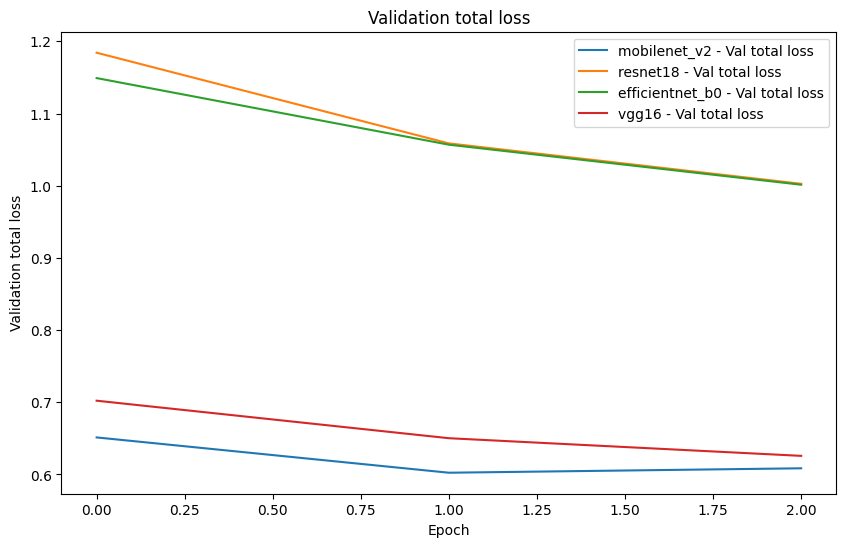

In [ ]:
plt.figure(figsize=(10, 6))
for backbone, df in backbone_metrics_data.items():
    plt.plot(df['epoch'], df['val_total_loss'], label=f'{backbone} - Val total loss')
plt.xlabel('Epoch')
plt.ylabel('Validation total loss')
plt.title('Validation total loss')
plt.legend()
plt.show()

MobileNetV2 backbone achieves the lowest validation total loss consistently across all three epochs.

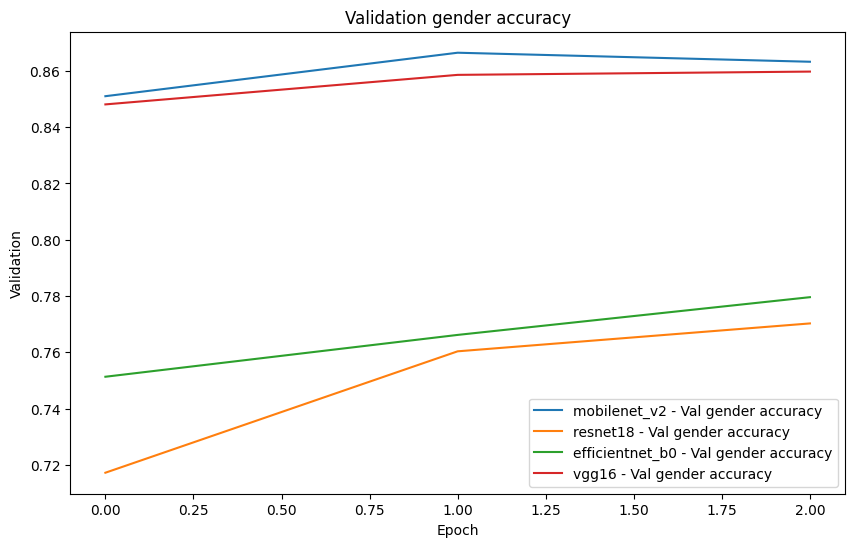

In [ ]:
plt.figure(figsize=(10, 6))
for backbone, df in backbone_metrics_data.items():
    plt.plot(df['epoch'], df['val_gender_accuracy'], label=f'{backbone} - Val gender accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation')
plt.title('Validation gender accuracy')
plt.legend()
plt.show()

MobileNetV2 and VGG16 show the highest validation gender accuracy, both converging close to 86% by the third epoch.

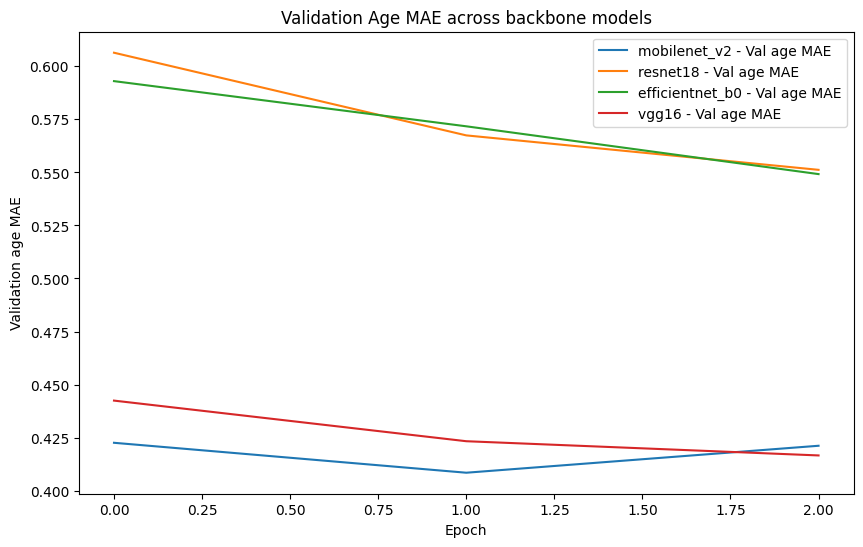

In [ ]:
plt.figure(figsize=(10, 6))
for backbone, df in backbone_metrics_data.items():
    plt.plot(df['epoch'], df['val_age_mae'], label=f'{backbone} - Val age MAE')
plt.xlabel('Epoch')
plt.ylabel('Validation age MAE')
plt.title('Validation Age MAE across backbone models')
plt.legend()
plt.show()

Both MobileNetV2 and VGG16 achieved the lowest validation MAE for age regression remaining consistently below 0.425 after just 3 epochs.

Based on these promising results and the strong performance of MobileNetV2 during baseline explorations we have selected this model for further optimization.

### Optuna hyperparameters search

In the next phase we will use Optuna to tune hyperparameters including learning rate, dropout rate, weight decay, and optimizer selection (Adam and AdamW). Regularization methods will be necessary since we are considering training even all the layers. Additionally we will explore the optimal number of layers to fine tune, aiming to identify good configuration for this model.

Also in this part we introduce scaled loss to balance contributions from gender classification and age regression to total loss. The binary crossentropy loss for gender classification and the mean squared error loss for age regression will be each scaled by 0.5 as we might consider in further stages experiment with different scales.

In [ ]:
class AgeGenderModelMobileNet(pl.LightningModule):
    def __init__(
        self,
        learning_rate=1e-4,
        dropout_rate=0.3,
        weight_decay=1e-4,
        unfreeze_layers=0,
        optimizer_name="Adam"
    ):
        super(AgeGenderModelMobileNet, self).__init__()
        self.save_hyperparameters()

        self.base_model = models.mobilenet_v2(weights="MobileNet_V2_Weights.IMAGENET1K_V1")
        self.base_model.classifier = nn.Identity()
        in_features = self.base_model.last_channel

        for param in self.base_model.parameters():
            param.requires_grad = False

        if unfreeze_layers == 0:
            for param in self.base_model.parameters():
                param.requires_grad = True
        elif unfreeze_layers > 0:
            for layer in list(self.base_model.features[-unfreeze_layers:]):
                for param in layer.parameters():
                    param.requires_grad = True

        self.dropout = nn.Dropout(dropout_rate)

        self.gender_output = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.Sigmoid()
        )
        self.age_output = nn.Linear(in_features, 1)

        self.gender_accuracy = BinaryAccuracy()
        self.age_mae = MeanAbsoluteError()
        self.gender_loss_fn = nn.BCELoss()
        self.age_loss_fn = nn.MSELoss()
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.optimizer_name = optimizer_name

    def forward(self, x):
        features = self.base_model.features(x)
        pooled_features = features.mean([2, 3])
        pooled_features = self.dropout(pooled_features)
        gender_pred = self.gender_output(pooled_features).view(-1)
        age_pred = self.age_output(pooled_features).view(-1)
        return gender_pred, age_pred

    def training_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels.float())
        age_loss = self.age_loss_fn(age_pred, age_labels.float())
        total_loss = 0.5 * gender_loss + 0.5 * age_loss #scaled total loss

        self.log("train_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("train_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("train_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("train_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def validation_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels.float())
        age_loss = self.age_loss_fn(age_pred, age_labels.float())
        total_loss = 0.5 * gender_loss + 0.5 * age_loss  #scaled total loss

        self.log("val_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("val_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("val_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("val_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("val_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def configure_optimizers(self):
        params = filter(lambda p: p.requires_grad, self.parameters())

        if self.optimizer_name == "Adam":
            optimizer = torch.optim.Adam(params, lr=self.learning_rate, weight_decay=self.weight_decay)
        elif self.optimizer_name == "AdamW":
            optimizer = torch.optim.AdamW(params, lr=self.learning_rate, weight_decay=self.weight_decay)
        else:
            raise ValueError(f"Unsupported optimizer: {self.optimizer_name}")

        return optimizer

In [ ]:
def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    unfreeze_layers = trial.suggest_int("unfreeze_layers", 0, len(list(models.mobilenet_v2(weights=None).features)))
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])

    model = AgeGenderModelMobileNet(
        learning_rate=learning_rate,
        dropout_rate=dropout_rate,
        weight_decay=weight_decay,
        unfreeze_layers=unfreeze_layers,
        optimizer_name=optimizer_name
    )

    data_module = AgeGenderDataModule(
        train_df=train_data,
        val_df=val_data,
        test_df=test_data,
        batch_size=batch_size
    )

    logger = CSVLogger("optuna_logs", name=f"trial_{trial.number}")

    trainer = Trainer(
        max_epochs=1,
        logger=logger,
        enable_progress_bar=True,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        log_every_n_steps=1
    )

    try:
        trainer.fit(model, datamodule=data_module)
        val_loss = trainer.callback_metrics["val_total_loss"].item()
    except RuntimeError as e:
        print("RuntimeError during training:", e)
        return float("inf")

    return val_loss

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

[I 2024-11-25 08:21:47,624] A new study created in memory with name: no-name-01c5b4b5-0381-4f0c-826e-c406b71348c3
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 79.9MB/s]
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type              | Params | Mode 
--------------------------------------------------------------
0 | base_model      | MobileNetV2       | 2.2 M  | train
1 | d

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=1` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.
[I 2024-11-25 08:23:37,510] Trial 0 finished with value: 0.21318280696868896 and parameters: {'learning_rate': 0.0005191148957507159, 'dropout_rate': 0.19366863898804865, 'weight_decay': 3.8015218201752794e-06, 'batch_size': 16, 'unfreeze_layers': 10, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.21318280696868896.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Ty

...

INFO: `Trainer.fit` stopped: `max_epochs=1` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.
[I 2024-11-25 09:00:07,353] Trial 18 finished with value: 0.22053176164627075 and parameters: {'learning_rate': 0.00012166578005394713, 'dropout_rate': 0.284082163409155, 'weight_decay': 9.166119517254648e-06, 'batch_size': 16, 'unfreeze_layers': 7, 'optimizer': 'Adam'}. Best is trial 15 with value: 0.19572263956069946.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Typ

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=1` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.
[I 2024-11-25 09:01:37,612] Trial 19 finished with value: 0.3063453733921051 and parameters: {'learning_rate': 0.00026289835482160793, 'dropout_rate': 0.4421231581518918, 'weight_decay': 2.638945853009479e-05, 'batch_size': 16, 'unfreeze_layers': 2, 'optimizer': 'AdamW'}. Best is trial 15 with value: 0.19572263956069946.


In [ ]:
print("Best hyperparameters:", study.best_params)

Best hyperparameters: {'learning_rate': 0.00016277082236748248, 'dropout_rate': 0.4825418581622139, 'weight_decay': 8.365806893223885e-06, 'batch_size': 16, 'unfreeze_layers': 0, 'optimizer': 'Adam'}


Best hyperparameters: {'learning_rate': 0.00016277082236748248, 'dropout_rate': 0.4825418581622139, 'weight_decay': 8.365806893223885e-06, 'batch_size': 16, 'unfreeze_layers': 0, 'optimizer': 'Adam'}

In [ ]:
optuna_logs_path = '/content/optuna_logs'

In [ ]:
optuna_results = []

for trial in study.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:
        trial_info = {
            'trial': trial.number,
            'learning_rate': trial.params.get('learning_rate', None),
            'dropout_rate': trial.params.get('dropout_rate', None),
            'weight_decay': trial.params.get('weight_decay', None),
            'batch_size': trial.params.get('batch_size', None),
            'unfrozen_layers': trial.params.get('unfreeze_layers', None),
            'optimizer': trial.params.get('optimizer', None)
        }

        trial_folder = f"trial_{trial.number}"
        version_path = os.path.join(optuna_logs_path, trial_folder, 'version_0')
        metrics_file = os.path.join(version_path, 'metrics.csv')

        if os.path.exists(metrics_file):
            metrics_df = pd.read_csv(metrics_file)

            trial_info.update({
                'train_age_loss': metrics_df['train_age_loss'].dropna().iloc[-1] if 'train_age_loss' in metrics_df else None,
                'train_gender_loss': metrics_df['train_gender_loss'].dropna().iloc[-1] if 'train_gender_loss' in metrics_df else None,
                'train_total_loss': metrics_df['train_total_loss'].dropna().iloc[-1] if 'train_total_loss' in metrics_df else None,
                'val_age_loss': metrics_df['val_age_loss'].dropna().iloc[-1] if 'val_age_loss' in metrics_df else None,
                'val_gender_loss': metrics_df['val_gender_loss'].dropna().iloc[-1] if 'val_gender_loss' in metrics_df else None,
                'val_total_loss': metrics_df['val_total_loss'].dropna().iloc[-1] if 'val_total_loss' in metrics_df else None,
                'train_gender_accuracy': metrics_df['train_gender_accuracy'].dropna().iloc[-1] if 'train_gender_accuracy' in metrics_df else None,
                'val_gender_accuracy': metrics_df['val_gender_accuracy'].dropna().iloc[-1] if 'val_gender_accuracy' in metrics_df else None,
                'train_age_mae': metrics_df['train_age_mae'].dropna().iloc[-1] if 'train_age_mae' in metrics_df else None,
                'val_age_mae': metrics_df['val_age_mae'].dropna().iloc[-1] if 'val_age_mae' in metrics_df else None
            })

        optuna_results.append(trial_info)

In [ ]:
optuna_results_df = pd.DataFrame(optuna_results)
optuna_results_df.head(5)

,trial,learning_rate,dropout_rate,weight_decay,batch_size,unfrozen_layers,optimizer,train_age_loss,train_gender_loss,train_total_loss,val_age_loss,val_gender_loss,val_total_loss,train_gender_accuracy,val_gender_accuracy,train_age_mae,val_age_mae
0,0,0.000519,0.193669,0.000004,16,10,Adam,0.351500,0.313717,0.332609,0.206870,0.219496,0.213183,0.860856,0.907872,0.450273,0.337139
1,1,0.000080,0.132466,0.000044,16,4,AdamW,0.392494,0.371909,0.382201,0.257903,0.278205,0.268054,0.834427,0.879883,0.480799,0.385010
2,2,0.000332,0.206841,0.000004,16,10,Adam,0.346790,0.312009,0.329399,0.213728,0.244955,0.229342,0.862918,0.900583,0.445718,0.360746
3,3,0.000235,0.420659,0.000092,8,13,AdamW,0.435441,0.347346,0.391394,0.247305,0.204700,0.226002,0.842737,0.923032,0.504475,0.389026
4,4,0.000051,0.262247,0.000040,8,5,AdamW,0.462124,0.408096,0.435110,0.264368,0.277603,0.270985,0.810809,0.887172,0.523759,0.388610


In [ ]:
#optuna_results_df.to_csv('combined_optuna_trial_results.csv', index=False)

<ipython-input-24-56bdb4f2af1d>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=optuna_results_df, x='learning_rate', y='val_total_loss', palette='viridis', s=100)


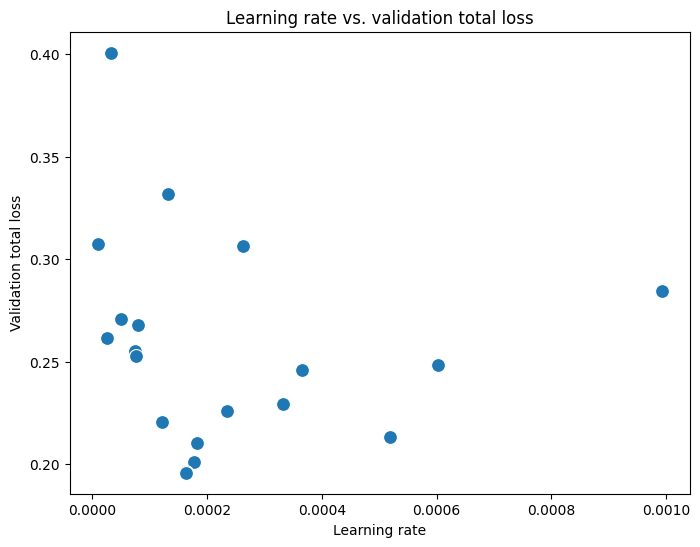

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=optuna_results_df, x='learning_rate', y='val_total_loss', palette='viridis', s=100)
plt.title('Learning rate vs. validation total loss')
plt.xlabel('Learning rate')
plt.ylabel('Validation total loss')
plt.show()

There does not appear to be a clear trend between the validation total loss and the learning rate across the tested values. However lower learning rates show a higher concentration with lower validation loss suggesting that smaller learning rates may lead to more effective training for this model.

<ipython-input-25-47d827548f1f>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=optuna_results_df, x='dropout_rate', y='val_gender_accuracy', palette='viridis', s=100)


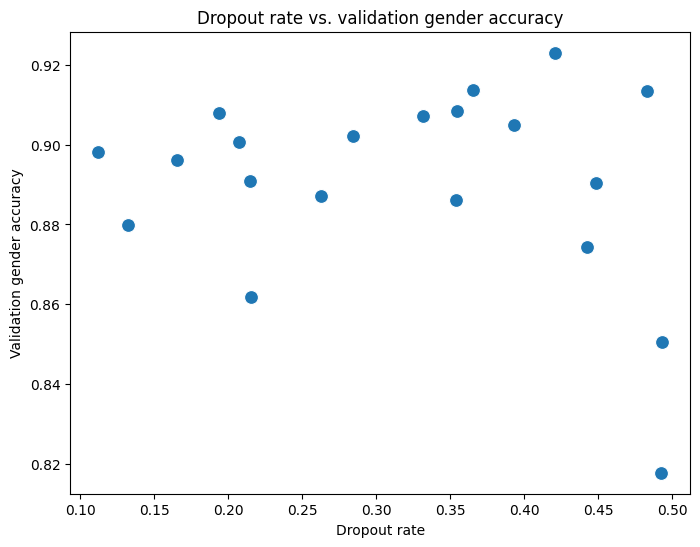

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=optuna_results_df, x='dropout_rate', y='val_gender_accuracy', palette='viridis', s=100)
plt.title('Dropout rate vs. validation gender accuracy')
plt.xlabel('Dropout rate')
plt.ylabel('Validation gender accuracy')
plt.show()

Validation gender accuracy remains consistently high across a wide range of dropout rates even from the first epoch. While the optuna trial recommended a relatively high dropout rate of around 48% this plot indicates that lower dropout rates could also yield comparable results.

<ipython-input-26-2abbcf954e65>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=optuna_results_df, x='weight_decay', y='val_total_loss', palette='viridis', s=100)


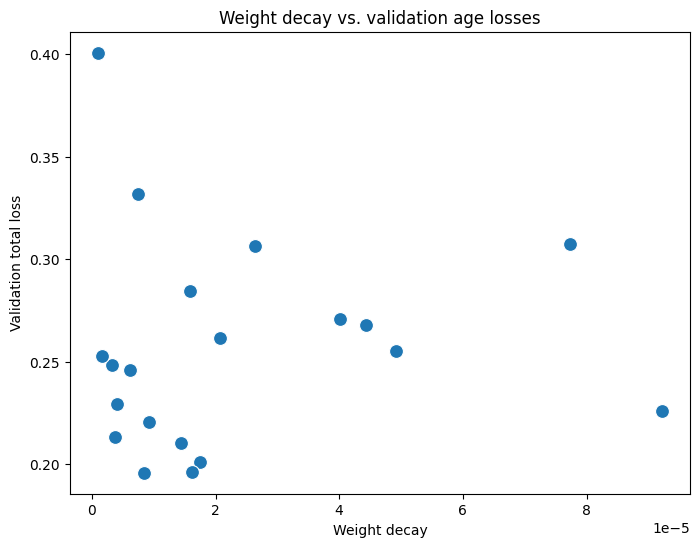

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=optuna_results_df, x='weight_decay', y='val_total_loss', palette='viridis', s=100)
plt.title('Weight decay vs. validation age losses')
plt.xlabel('Weight decay')
plt.ylabel('Validation total loss')
plt.show()

Similar to the trend observed with the learning rate we can see that lower validation total loss appears to be concentrated around lower weight decay values. Even though there are outliers this plot suggests that using a smaller weight decay might be better for achieving lower validation losses.

##### MobileNetV2 trained with the found hyperparameters set.

For first several experiments we will work with trial hyperparameters suggestions and will see how model behaves.

In [ ]:
class AgeGenderModelMobileNetV2(pl.LightningModule):
    def __init__(self, learning_rate=0.00016277082236748248, dropout_rate=0.4825418581622139,
                 weight_decay=8.365806893223885e-06):
        super(AgeGenderModelMobileNetV2, self).__init__()

        self.base_model = models.mobilenet_v2(weights="MobileNet_V2_Weights.IMAGENET1K_V1")
        in_features = self.base_model.last_channel

        self.base_model.classifier = nn.Identity()

        for param in self.base_model.parameters():
            param.requires_grad = True

        self.dropout = nn.Dropout(dropout_rate)
        self.gender_output = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.Sigmoid()
        )
        self.age_output = nn.Linear(in_features, 1)

        self.gender_accuracy = BinaryAccuracy()
        self.age_mae = MeanAbsoluteError()
        self.gender_loss_fn = nn.BCELoss()
        self.age_loss_fn = nn.MSELoss()
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

    def forward(self, x):
        features = self.base_model.features(x)
        features = features.mean([2, 3])
        features = self.dropout(features)
        gender_pred = self.gender_output(features).view(-1)
        age_pred = self.age_output(features).view(-1)
        return gender_pred, age_pred

    def training_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels)
        age_loss = self.age_loss_fn(age_pred, age_labels)
        total_loss = 0.5 * gender_loss + 0.5 * age_loss

        self.log("train_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("train_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("train_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("train_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def validation_step(self, batch, batch_idx):
        images, (gender_labels, age_labels) = batch
        gender_pred, age_pred = self(images)

        gender_loss = self.gender_loss_fn(gender_pred, gender_labels)
        age_loss = self.age_loss_fn(age_pred, age_labels)
        total_loss = 0.5 * gender_loss + 0.5 * age_loss

        self.log("val_gender_loss", gender_loss, on_step=False, on_epoch=True)
        self.log("val_age_loss", age_loss, on_step=False, on_epoch=True)
        self.log("val_total_loss", total_loss, on_step=False, on_epoch=True)
        self.log("val_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True)
        self.log("val_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True)

        return total_loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)

In [ ]:
model_MobileNetV2_best = AgeGenderModelMobileNetV2(
    learning_rate=0.00016277082236748248,
    dropout_rate=0.4825418581622139,
    weight_decay=8.365806893223885e-06)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 75.7MB/s]


In [ ]:
data_module_best = AgeGenderDataModule(
    train_df=train_data,
    val_df=val_data,
    test_df=test_data,
    batch_size=16
)

In [ ]:
csv_logger_best = CSVLogger("logs", name="AgeGenderModelMobileNetV2Best")

In [ ]:
checkpoint_callback_best = ModelCheckpoint(
    monitor="val_total_loss",
    filename="best-checkpoint",
    save_top_k=1,
    mode="min"
)

In [ ]:
early_stopping_best = EarlyStopping(
    monitor="val_total_loss",
    patience=5,
    mode="min"
)

In [ ]:
trainer_best = pl.Trainer(
    max_epochs=30,
    logger=csv_logger_best,
    callbacks=[checkpoint_callback_best, early_stopping_best],
    log_every_n_steps=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer_best.fit(model_MobileNetV2_best, data_module_best)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type              | Params | Mode 
--------------------------------------------------------------
0 | base_model      | MobileNetV2       | 2.2 M  | train
1 | dropout         | Dropout           | 0      | train
2 | gender_output   | Sequential        | 1.3 K  | train
3 | age_output      | Linear            | 1.3 K  | train
4 | gender_accuracy | BinaryAccuracy    | 0      | train
5 | age_mae         | MeanAbsoluteError | 0      | train
6 | gender_loss_fn  | BCELoss           | 0      | train
7 | age_loss_fn     | MSELoss           | 0      | train
--------------------------------------------------------------
2.2 M     Trainable params
0         Non-trainable params
2.2 M     Total params
8.906     Total estimated model params size (MB)
220       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
val_dataloader = data_module_best.val_dataloader()

gender_preds = []
gender_labels = []
age_preds = []
age_labels = []

In [ ]:
for batch in val_dataloader:
    images, (gender, age) = batch
    with torch.no_grad():
        gender_pred, age_pred = model_MobileNetV2_best(images)

    gender_preds.extend((gender_pred > 0.5).int().cpu().numpy().tolist())
    gender_labels.extend(gender.cpu().numpy().tolist())

    age_preds.extend(((age_pred.cpu().numpy() * age_std) + age_mean).tolist())
    age_labels.extend(((age.cpu().numpy() * age_std) + age_mean).tolist())
gender_preds = np.array(gender_preds)
gender_labels = np.array(gender_labels)
age_preds = np.array(age_preds)
age_labels = np.array(age_labels)

In [ ]:
print("Gender classification report:")
print(classification_report(gender_labels, gender_preds, target_names=["Male", "Female"]))

Gender classification report:
              precision    recall  f1-score   support

        Male       0.87      0.96      0.91      1796
      Female       0.95      0.84      0.89      1634

    accuracy                           0.90      3430
   macro avg       0.91      0.90      0.90      3430
weighted avg       0.90      0.90      0.90      3430



The models performance has improved based on accuracy and F1-score metrics after transitioning from feature extraction to full fine tuned model with explored hyperparametrs.

**Fine-tuned Model:**


Weighted avg accuracy: 90%

Weighted avg F1-score: 90%


**Baseline Model:**


Weighted avg accuracy: 82%

Weighted avg F1-score: 82%

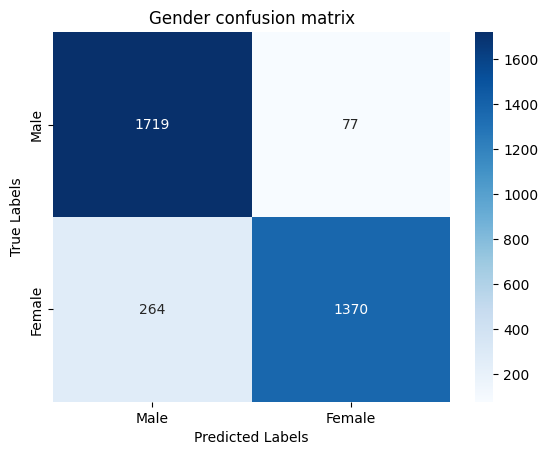

In [ ]:
conf_matrix = confusion_matrix(gender_labels, gender_preds)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Gender confusion matrix")
plt.show()

As per the classification report and confusion matrix we observed that the model performed better on male images compared to female images. Therefore in the next experiment, we will introduce sample weights for the gender loss to address the imbalance in the set and will evaluate its impact on gender classification results. Sample weights will assign weights to each sample in the batch based on gender proportions. This adjustment ensures that the model gives more importance to underrepresented during the computation of the loss.

In [ ]:
age_mae = mean_absolute_error(age_labels, age_preds)
age_rmse = mean_squared_error(age_labels, age_preds, squared=False)

print(f"Age Mean Absolute Error (MAE): {age_mae:.2f}")
print(f"Age Root Mean Squared Error (RMSE): {age_rmse:.2f}")

Age Mean Absolute Error (MAE): 6.61
Age Root Mean Squared Error (RMSE): 8.69


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Age mean absolute error and root mean squared error has significantly improved compared to the best results acieved by MobileNetV2 feature extraction model (Before: Age MAE 9.58, Age RMSE 12.37)

In [ ]:
log_dir = "logs/AgeGenderModelMobileNetV2Best/version_0/metrics.csv"
metrics_df = pd.read_csv(log_dir)

In [ ]:
train_data_metrics = metrics_df[metrics_df['train_age_loss'].notna()]
val_data_metrics = metrics_df[metrics_df['val_age_loss'].notna()]

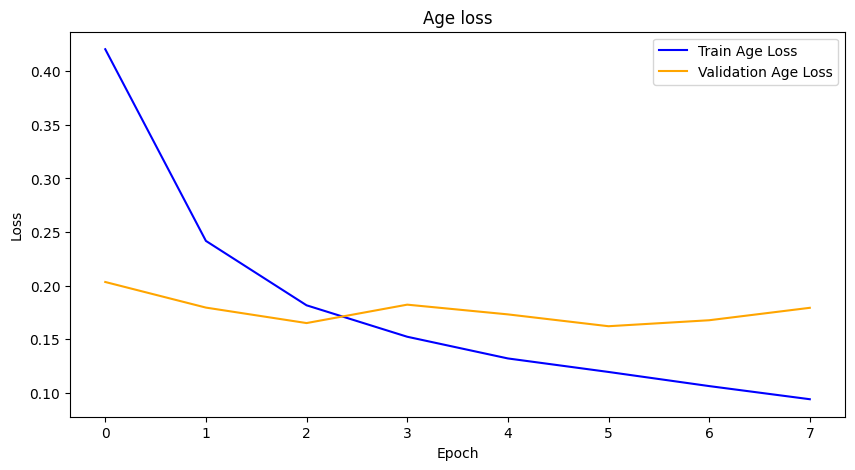

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_loss'], label='Train Age Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_loss'], label='Validation Age Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Age loss')
plt.legend()
plt.show()

Age loss trend suggests that the model is generalizing quite well with minimal overfitting as there is some divergence between training and validation losses but not extreme.

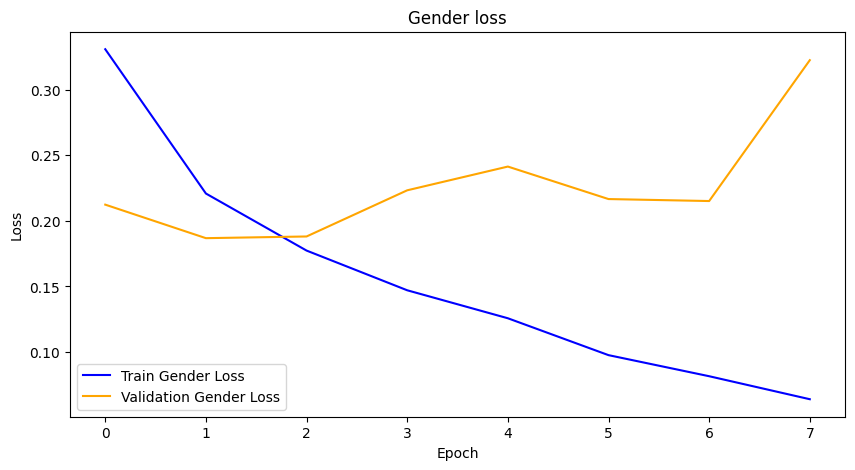

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_loss'], label='Train Gender Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_loss'], label='Validation Gender Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Gender loss')
plt.legend()
plt.show()

Contrary to age loss plot overfitting is evident in the gender task as the validation loss diverges from the training loss after 3rd epoch. Introduced sample weights in the next step might help with overfitting.

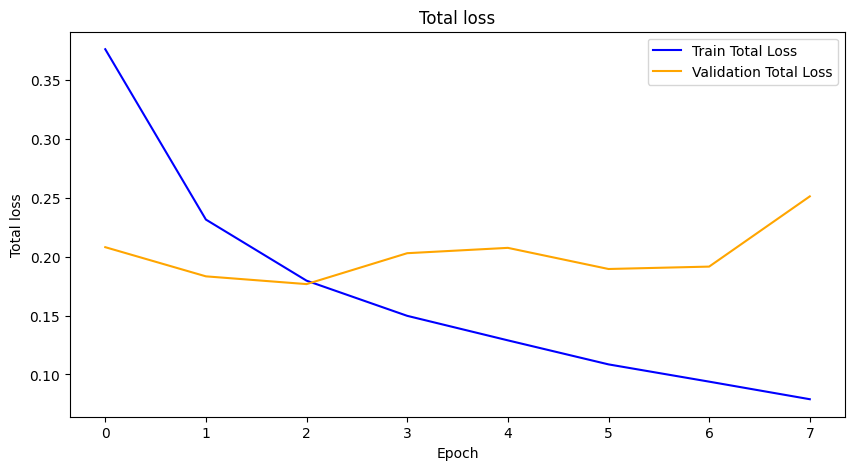

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_total_loss'], label='Train Total Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_total_loss'], label='Validation Total Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Total loss')
plt.title('Total loss')
plt.legend()
plt.show()

We can see combination of both age and gender losses and that gender task might be contributing disproportionately to the total loss in later epochs.

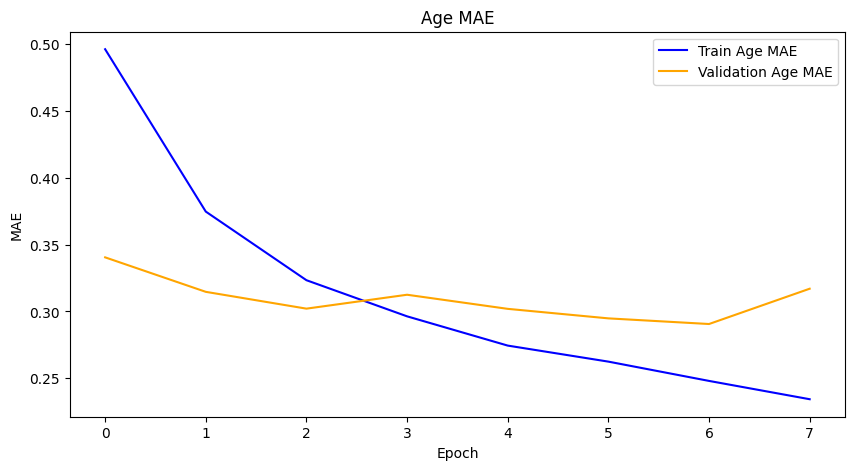

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_mae'], label='Train Age MAE', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_mae'], label='Validation Age MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age MAE')
plt.legend()
plt.show()

The model maintains a good balance between training and validation performance, with no severe overfitting in age regression.

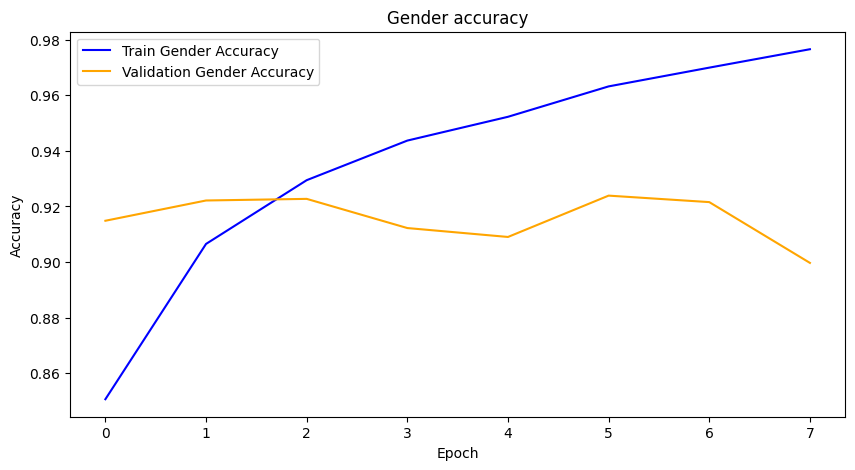

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_accuracy'], label='Train Gender Accuracy', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_accuracy'], label='Validation Gender Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender accuracy')
plt.legend()
plt.show()

Training accuracy shows that the model is confident in classifying gender during training, but validation accuracy suggests that the model might not be able to generalize equally well to unseen data which is another indication of overfitting in the gender classification.

In [ ]:
gender_probs = gender_preds.flatten()
roc_auc = roc_auc_score(gender_labels, gender_probs)
fpr, tpr, _ = roc_curve(gender_labels, gender_probs)

Gender ROC-AUC: 0.90


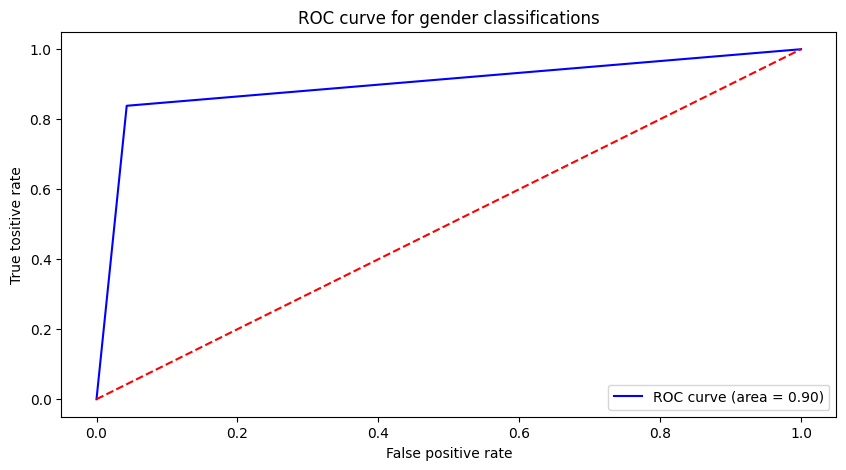

In [ ]:
print(f"Gender ROC-AUC: {roc_auc:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False positive rate")
plt.ylabel("True tositive rate")
plt.title("ROC curve for gender classifications")
plt.legend(loc="lower right")
plt.show()

 The ROC-AUC curve and score show that the model balances well the trade off between true positive and false positive.

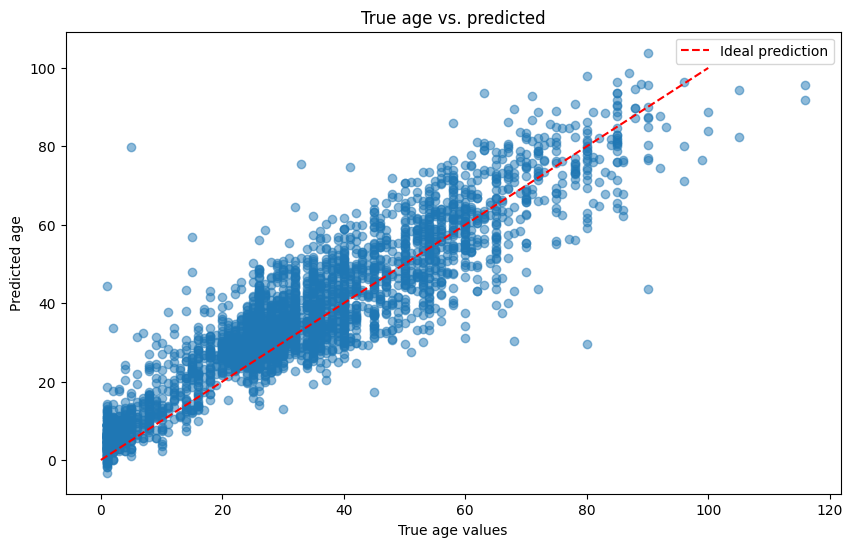

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(age_labels, age_preds, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--', label="Ideal prediction")
plt.xlabel("True age values")
plt.ylabel("Predicted age")
plt.title("True age vs. predicted")
plt.legend()
plt.show()

Scatter points show that the majority of age predictions align closely with the diagonal line which indices correct prediction. It particularly well aligns in the central age range. However there is noticeable dispersion where predictions deviate more from the ideal especially for child and senior individuals.

In [ ]:
model_MobileNetV2_best.eval()
total_time = 0.0
num_batches = len(val_dataloader)

In [ ]:
for batch in val_dataloader:
    images, _ = batch
    with torch.no_grad():
        start_time = time.time()
        _ = model_MobileNetV2_best(images)
        end_time = time.time()

    total_time += (end_time - start_time)

average_inference_time = total_time / num_batches
print(f"Average inference time per batch: {average_inference_time:.4f} seconds")

Average inference time per batch: 2.0413 seconds


Model takes on average 2.04 second per batch, our batch size is 16 so per images it takes approximately 0.13 to make a prediction.

##### **Introducing sample weights to the gender loss.**

In [ ]:
class AgeGenderDataset(Dataset):
    def __init__(self, dataframe, transform=None, normalize_age=True):
        self.dataframe = dataframe
        self.transform = transform
        self.normalize_age = normalize_age

        self.sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=self.dataframe["gender"]
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row['file_path']
        image = Image.open(img_path).convert('RGB')
        gender = row['gender']
        age = row['age']

        if self.normalize_age:
            age = (age - age_mean) / age_std

        if self.transform:
            image = self.transform(image)

        gender = torch.tensor(gender, dtype=torch.float32)
        age = torch.tensor(age, dtype=torch.float32)

        sample_weight = self.sample_weights[idx]
        return image, (gender, age), sample_weight

In [ ]:
class AgeGenderModelMobileNetV2w8(pl.LightningModule):
    def __init__(self, learning_rate=0.00016277082236748248, dropout_rate=0.4825418581622139,
                 weight_decay=8.365806893223885e-06):
        super().__init__()

        self.base_model = models.mobilenet_v2(weights="MobileNet_V2_Weights.IMAGENET1K_V1")
        in_features = self.base_model.last_channel

        self.base_model.classifier = nn.Identity()

        for param in self.base_model.parameters():
            param.requires_grad = True

        self.dropout = nn.Dropout(dropout_rate)
        self.gender_output = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.Sigmoid()
        )
        self.age_output = nn.Linear(in_features, 1)

        self.gender_accuracy = BinaryAccuracy()
        self.age_mae = MeanAbsoluteError()
        self.age_loss_fn = nn.MSELoss()

        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

    def forward(self, x):
        features = self.base_model.features(x)
        features = features.mean([2, 3])
        features = self.dropout(features)
        gender_pred = self.gender_output(features).view(-1)
        age_pred = self.age_output(features).view(-1)
        return gender_pred, age_pred

    def compute_sample_weights(self, gender_labels):
        gender_np = gender_labels.cpu().numpy()
        sample_weights = compute_sample_weight(class_weight="balanced", y=gender_np)
        return torch.tensor(sample_weights, device=self.device, dtype=torch.float32)

    def training_step(self, batch, batch_idx):
        images, (gender_labels, age_labels), age_groups = batch
        gender_pred, age_pred = self(images)

        sample_weights = self.compute_sample_weights(gender_labels)

        gender_loss = F.binary_cross_entropy(gender_pred, gender_labels, weight=sample_weights)
        age_loss = self.age_loss_fn(age_pred, age_labels)
        total_loss = 0.5 * gender_loss + 0.5 * age_loss

        self.log("train_gender_loss", gender_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_age_loss", age_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True, batch_size=images.size(0))

        return total_loss

    def validation_step(self, batch, batch_idx):
        images, (gender_labels, age_labels), age_groups = batch
        gender_pred, age_pred = self(images)

        sample_weights = self.compute_sample_weights(gender_labels)

        gender_loss = F.binary_cross_entropy(gender_pred, gender_labels, weight=sample_weights)
        age_loss = self.age_loss_fn(age_pred, age_labels)
        total_loss = 0.5 * gender_loss + 0.5 * age_loss

        self.log("val_gender_loss", gender_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_age_loss", age_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_total_loss", total_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True, batch_size=images.size(0))

        return total_loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        return optimizer

In [ ]:
model_MobileNetV2_best_w8 = AgeGenderModelMobileNetV2w8(
    learning_rate=0.00016277082236748248,
    dropout_rate=0.4825418581622139,
    weight_decay=8.365806893223885e-06)

In [ ]:
csv_logger_best_w8 = CSVLogger("logs", name="AgeGenderModelMobileNetV2Bestw8")

In [ ]:
trainer_best = pl.Trainer(
    max_epochs=20,
    logger=csv_logger_best_w8,
    callbacks=[checkpoint_callback_best, early_stopping_best],
    log_every_n_steps=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer_best.fit(model_MobileNetV2_best_w8, data_module_best)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type              | Params | Mode 
--------------------------------------------------------------
0 | base_model      | MobileNetV2       | 2.2 M  | train
1 | dropout         | Dropout           | 0      | train
2 | gender_output   | Sequential        | 1.3 K  | train
3 | age_output      | Linear            | 1.3 K  | train
4 | gender_accuracy | BinaryAccuracy    | 0      | train
5 | age_mae         | MeanAbsoluteError | 0      | train
6 | age_loss_fn     | MSELoss           | 0      | train
--------------------------------------------------------------
2.2 M     Trainable params
0         Non-trainable params
2.2 M     Total params
8.906     Total estimated model params size (MB)
219       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
val_dataloader = data_module_best.val_dataloader()

gender_preds = []
gender_labels = []
age_preds = []
age_labels = []

In [ ]:
for batch in val_dataloader:
    images, (gender, age), _ = batch
    with torch.no_grad():
        gender_pred, age_pred = model_MobileNetV2_best_w8(images)

    gender_preds.extend((gender_pred > 0.5).int().cpu().numpy().tolist())
    gender_labels.extend(gender.cpu().numpy().tolist())

    age_preds.extend(((age_pred.cpu().numpy() * age_std) + age_mean).tolist())
    age_labels.extend(((age.cpu().numpy() * age_std) + age_mean).tolist())

gender_preds = np.array(gender_preds)
gender_labels = np.array(gender_labels)
age_preds = np.array(age_preds)
age_labels = np.array(age_labels)

In [ ]:
print("Gender classification report:")
print(classification_report(gender_labels, gender_preds, target_names=["Male", "Female"]))

Gender classification report:
              precision    recall  f1-score   support

        Male       0.95      0.90      0.92      1796
      Female       0.90      0.94      0.92      1634

    accuracy                           0.92      3430
   macro avg       0.92      0.92      0.92      3430
weighted avg       0.92      0.92      0.92      3430




**Model with sample weights:**

Weighted avg accuracy: 92%

Weighted avg F1 score: 92%


**Model results without sample weights:**


Weighted avg accuracy: 90%

Weighted avg F1-score: 90%



**Baseline Model:**


Weighted avg accuracy: 82%

Weighted avg F1-score: 82%

By intoducing sample weights model improved both accuracy and f1 score.

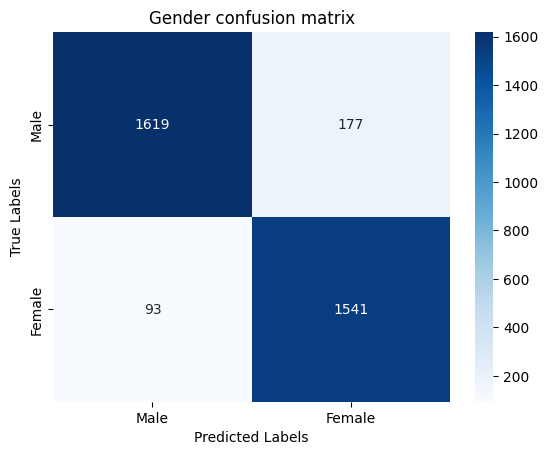

In [ ]:
conf_matrix = confusion_matrix(gender_labels, gender_preds)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Gender confusion matrix")
plt.show()

Even though the classification report shows improved overall results after introducing sample weights it is evident that more male images were misclassified compared to the results of the model without sample weights (results provided below). The improvement in overall performance metrics is primarily affected by increase in the classification performance for female images.

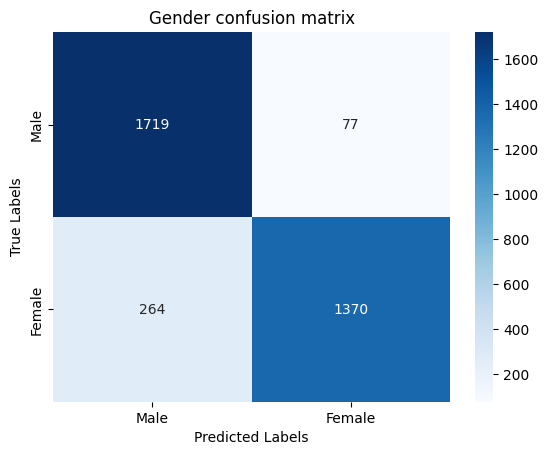

In [ ]:
age_mae = mean_absolute_error(age_labels, age_preds)
age_rmse = mean_squared_error(age_labels, age_preds, squared=False)

print(f"Age Mean Absolute Error (MAE): {age_mae:.2f}")
print(f"Age Root Mean Squared Error (RMSE): {age_rmse:.2f}")

Age Mean Absolute Error (MAE): 5.91
Age Root Mean Squared Error (RMSE): 8.14


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Changes to the gender loss helped to improve age predictions as well since losses are combined for optimization.

Model without sample weights results: MAE 6.61, RMSE 8.69 and now we have 5.91 and 8.14 accordingly.

In [ ]:
log_dir = "logs/AgeGenderModelMobileNetV2Bestw8/version_1/metrics.csv"
metrics_df = pd.read_csv(log_dir)

In [ ]:
train_data_metrics = metrics_df[metrics_df['train_age_loss'].notna()]
val_data_metrics = metrics_df[metrics_df['val_age_loss'].notna()]

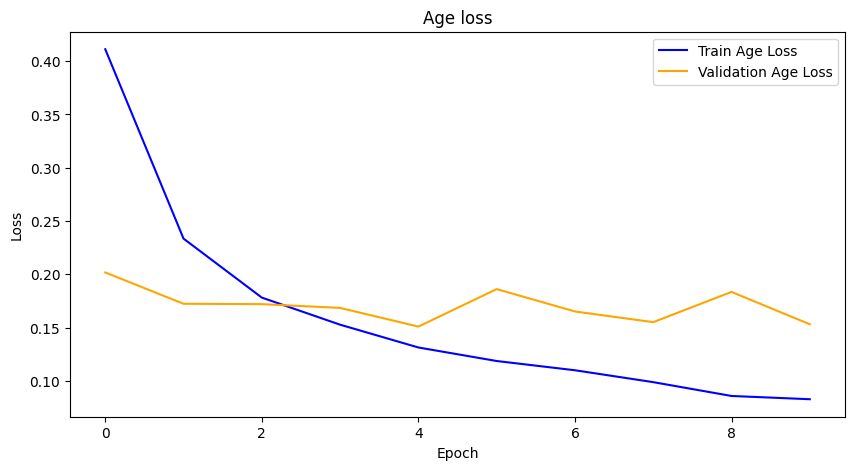

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_loss'], label='Train Age Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_loss'], label='Validation Age Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Age loss')
plt.legend()
plt.show()

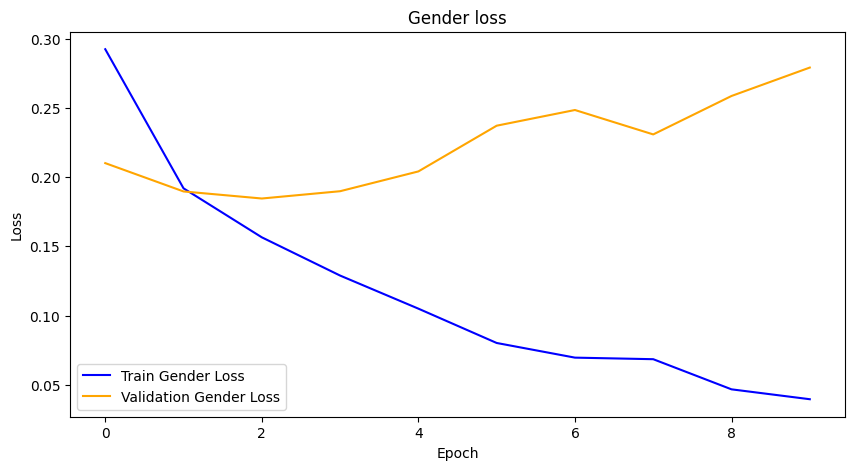

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_loss'], label='Train Gender Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_loss'], label='Validation Gender Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Gender loss')
plt.legend()
plt.show()

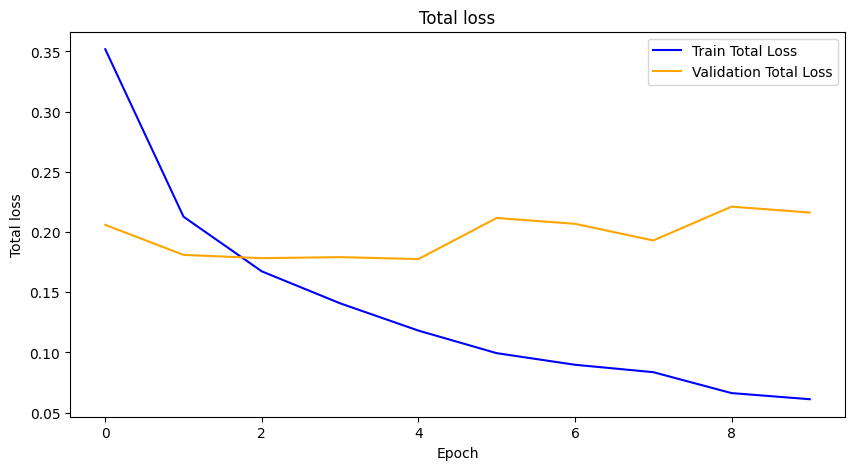

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_total_loss'], label='Train Total Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_total_loss'], label='Validation Total Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Total loss')
plt.title('Total loss')
plt.legend()
plt.show()

From all 3 plots we can see no actual changes to the losses, model is still overfitting and mostly because of gender classification. To address this we will introduce images augmenations to increase samples of data.

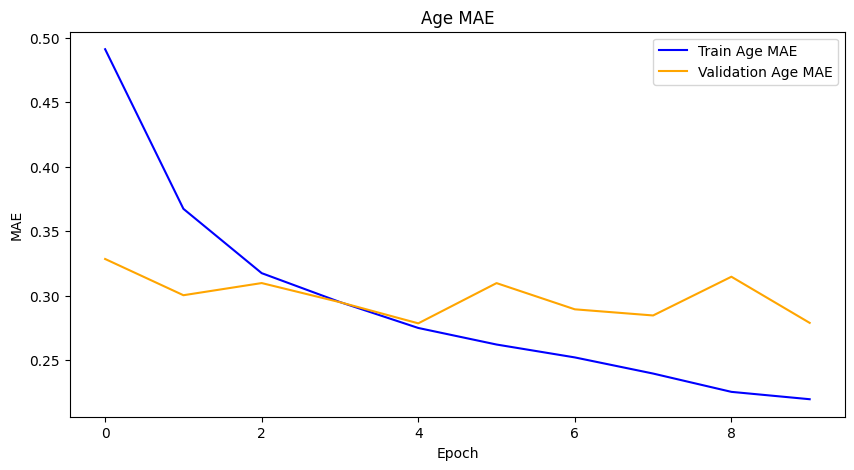

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_mae'], label='Train Age MAE', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_mae'], label='Validation Age MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age MAE')
plt.legend()
plt.show()

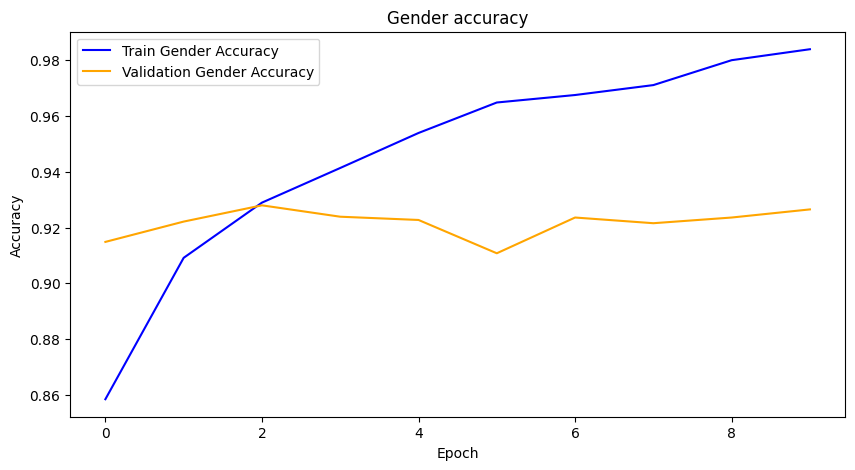

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_accuracy'], label='Train Gender Accuracy', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_accuracy'], label='Validation Gender Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender accuracy')
plt.legend()
plt.show()

Both Age MAE and gender accuracy still have place for improvement.

In [ ]:
gender_probs = gender_preds.flatten()
roc_auc = roc_auc_score(gender_labels, gender_probs)
fpr, tpr, _ = roc_curve(gender_labels, gender_probs)

Gender ROC-AUC: 0.92


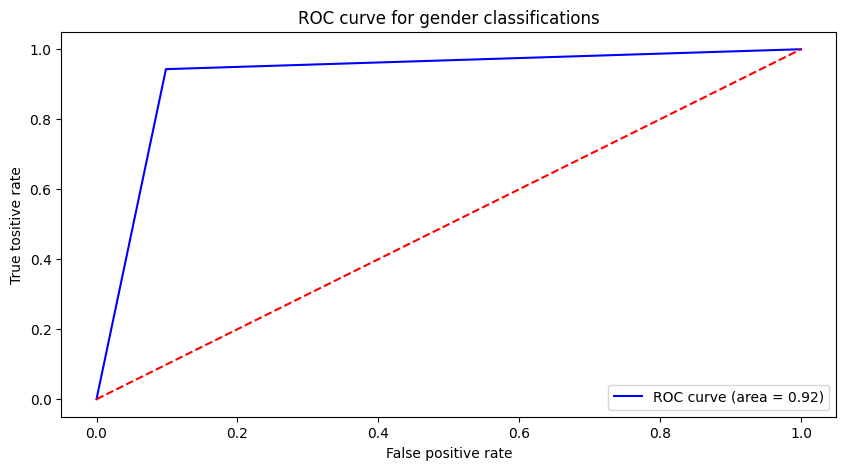

In [ ]:
print(f"Gender ROC-AUC: {roc_auc:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False positive rate")
plt.ylabel("True tositive rate")
plt.title("ROC curve for gender classifications")
plt.legend(loc="lower right")
plt.show()

Sample weights improved ROC-AUC score from 0.9 to 0.92.

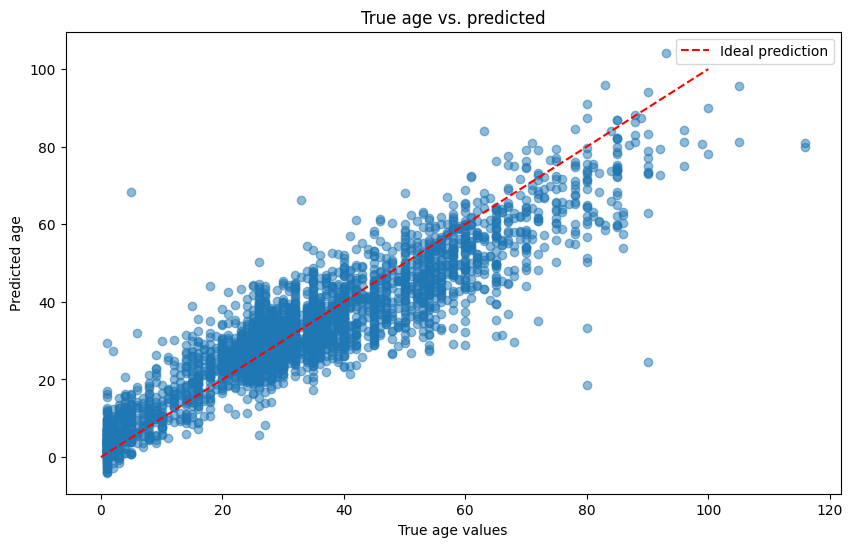

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(age_labels, age_preds, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--', label="Ideal prediction")
plt.xlabel("True age values")
plt.ylabel("Predicted age")
plt.title("True age vs. predicted")
plt.legend()
plt.show()

We can still see some strong deviations from true age values.

In [ ]:
model_MobileNetV2_best_w8.eval()
total_time = 0.0
num_batches = len(val_dataloader)

for batch in val_dataloader:
    images, _, _ = batch
    with torch.no_grad():
        start_time = time.time()
        _ = model_MobileNetV2_best_w8(images)
        end_time = time.time()

    total_time += (end_time - start_time)

average_inference_time = total_time / num_batches
print(f"Average inference time per batch: {average_inference_time:.4f} seconds")

Average inference time per batch: 2.4040 seconds


This version of the model increased the time it takes to make prediction by about 0.4 per batch.

##### Model with images augmentations

Despite having a relatively high dropout rate the model continues to overfit, likely due to the full fine tuning of all layers and relatively little data. To address this we will apply basic image augmentations to increase the diversity of the training set. These augmentations include horizontal flipping, 10 degree rotation and slight adjustments to brightness, contrast and saturation. Additionally since we have notice that we have lower quality images in the dataset we will use Gaussian blur to simulate similar images.

In [ ]:
general_augmentations = transforms.Compose([
    transforms.Pad((12, 12, 12, 12)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [ ]:
basic_preprocessing = transforms.Compose([
    transforms.Pad((12, 12, 12, 12)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
class AgeGenderTrainDataset(Dataset):
    def __init__(self, dataframe, general_transform=None, normalize_age=True, age_mean=None, age_std=None):
        self.dataframe = dataframe
        self.general_transform = general_transform
        self.normalize_age = normalize_age
        self.age_mean = age_mean or dataframe['age'].mean()
        self.age_std = age_std or dataframe['age'].std()

        self.sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=self.dataframe["gender"]
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["file_path"]
        gender = row["gender"]
        age = row["age"]

        if self.normalize_age:
            age = (age - self.age_mean) / self.age_std

        image = Image.open(image_path).convert("RGB")

        if self.general_transform:
            image = self.general_transform(image)

        if not isinstance(image, torch.Tensor):
            raise TypeError(f"Transformation did not return a tensor. Got {type(image)} instead.")

        gender = torch.tensor(gender, dtype=torch.float32)
        age = torch.tensor(age, dtype=torch.float32)

        sample_weight = torch.tensor(self.sample_weights[idx], dtype=torch.float32)
        return image, (gender, age), sample_weight

In [ ]:
class AgeGenderDataModule_augm(pl.LightningDataModule):
    def __init__(self, train_df, val_df, test_df, batch_size=32, normalize_age=True):
        super().__init__()
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.batch_size = batch_size
        self.normalize_age = normalize_age

        self.age_mean = train_df['age'].mean()
        self.age_std = train_df['age'].std()

    def setup(self, stage=None):
        self.train_dataset = AgeGenderTrainDataset(
            dataframe=self.train_df,
            general_transform=general_augmentations,
            normalize_age=self.normalize_age,
            age_mean=self.age_mean,
            age_std=self.age_std
        )

        self.val_dataset = AgeGenderTrainDataset(
            dataframe=self.val_df,
            general_transform=basic_preprocessing,
            normalize_age=self.normalize_age,
            age_mean=self.age_mean,
            age_std=self.age_std
        )

        self.test_dataset = AgeGenderTrainDataset(
            dataframe=self.test_df,
            general_transform=basic_preprocessing,
            normalize_age=self.normalize_age,
            age_mean=self.age_mean,
            age_std=self.age_std
        )

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2)

In [ ]:
model_MobileNetV2_best_w8_augm = AgeGenderModelMobileNetV2w8(
    learning_rate=0.00016277082236748248,
    dropout_rate=0.4825418581622139,
    weight_decay=8.365806893223885e-06)

In [ ]:
data_module_with_augmentations = AgeGenderDataModule_augm(
    train_df=train_data,
    val_df=val_data,
    test_df=test_data,
    batch_size=16,
    normalize_age=True
)

In [ ]:
csv_logger_best_w8_augm = CSVLogger("logs", name="AgeGenderModelMobileNetV2Bestw8Augm")

In [ ]:
trainer_best = pl.Trainer(
    max_epochs=20,
    logger=csv_logger_best_w8_augm,
    callbacks=[checkpoint_callback_best, early_stopping_best],
    log_every_n_steps=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer_best.fit(model_MobileNetV2_best_w8_augm, data_module_with_augmentations)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type              | Params | Mode 
--------------------------------------------------------------
0 | base_model      | MobileNetV2       | 2.2 M  | train
1 | dropout         | Dropout           | 0      | train
2 | gender_output   | Sequential        | 1.3 K  | train
3 | age_output      | Linear            | 1.3 K  | train
4 | gender_accuracy | BinaryAccuracy    | 0      | train
5 | age_mae         | MeanAbsoluteError | 0      | train
6 | age_loss_fn     | MSELoss           | 0      | train
--------------------------------------------------------------
2.2 M     Trainable params
0         Non-trainable params
2.2 M     Total params
8.906     Total estimated model params size (MB)
219       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
val_dataloader = data_module_with_augmentations.val_dataloader()

gender_preds = []
gender_labels = []
age_preds = []
age_labels = []

In [ ]:
for batch in val_dataloader:
    images, (gender, age), _ = batch
    with torch.no_grad():
        gender_pred, age_pred = model_MobileNetV2_best_w8_augm(images)

    gender_preds.extend((gender_pred > 0.5).int().cpu().numpy().tolist())
    gender_labels.extend(gender.cpu().numpy().tolist())

    age_preds.extend(((age_pred.cpu().numpy() * age_std) + age_mean).tolist())
    age_labels.extend(((age.cpu().numpy() * age_std) + age_mean).tolist())

gender_preds = np.array(gender_preds)
gender_labels = np.array(gender_labels)
age_preds = np.array(age_preds)
age_labels = np.array(age_labels)

In [ ]:
print("Gender classification report:")
print(classification_report(gender_labels, gender_preds, target_names=["Male", "Female"]))

Gender classification report:
              precision    recall  f1-score   support

        Male       0.94      0.94      0.94      1796
      Female       0.93      0.93      0.93      1634

    accuracy                           0.93      3430
   macro avg       0.93      0.93      0.93      3430
weighted avg       0.93      0.93      0.93      3430



Augmentation resulted into both better accuracy and f1 score. We can see that males images still have better results.


**Model with sample weights and image augmentation:**

Weighted avg accuracy: 93%

Weighted avg F1 score: 93%



**Model with sample weights:**

Weighted avg accuracy: 92%

Weighted avg F1 score: 92%


**Model results without sample weights:**


Weighted avg accuracy: 90%

Weighted avg F1-score: 90%



**Baseline Model:**


Weighted avg accuracy: 82%

Weighted avg F1-score: 82%



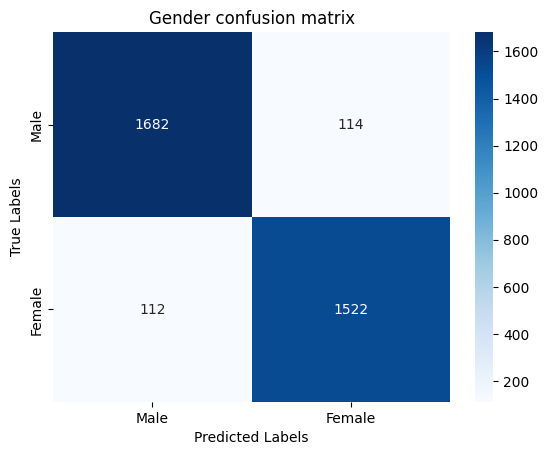

In [ ]:
conf_matrix = confusion_matrix(gender_labels, gender_preds)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Gender confusion matrix")
plt.show()

If we look at the total count of missclassfied images we can see that results are a quite balanced and we have less missclassfication in total compared to the model without augmentation. 226 <  270 (from below confusion matrix of model without augmenation)

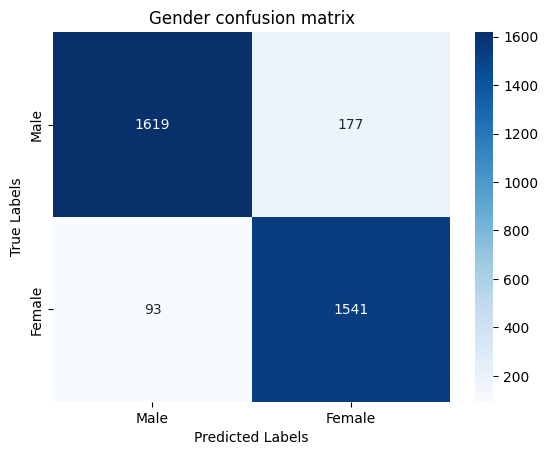

In [ ]:
age_mae = mean_absolute_error(age_labels, age_preds)
age_rmse = mean_squared_error(age_labels, age_preds, squared=False)

print(f"Age Mean Absolute Error (MAE): {age_mae:.2f}")
print(f"Age Root Mean Squared Error (RMSE): {age_rmse:.2f}")

Age Mean Absolute Error (MAE): 5.51
Age Root Mean Squared Error (RMSE): 7.76


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Also we can still see improvement with every implementation to the age predictions as well. Compare to the model without augmentation (Age Mean Absolute Error (MAE): 5.91
Age Root Mean Squared Error (RMSE): 8.14) now we have 5.51 and 7.76 accordingly.

In [ ]:
log_dir = "logs/AgeGenderModelMobileNetV2Bestw8Augm/version_1/metrics.csv"
metrics_df = pd.read_csv(log_dir)

In [ ]:
train_data_metrics = metrics_df[metrics_df['train_age_loss'].notna()]
val_data_metrics = metrics_df[metrics_df['val_age_loss'].notna()]

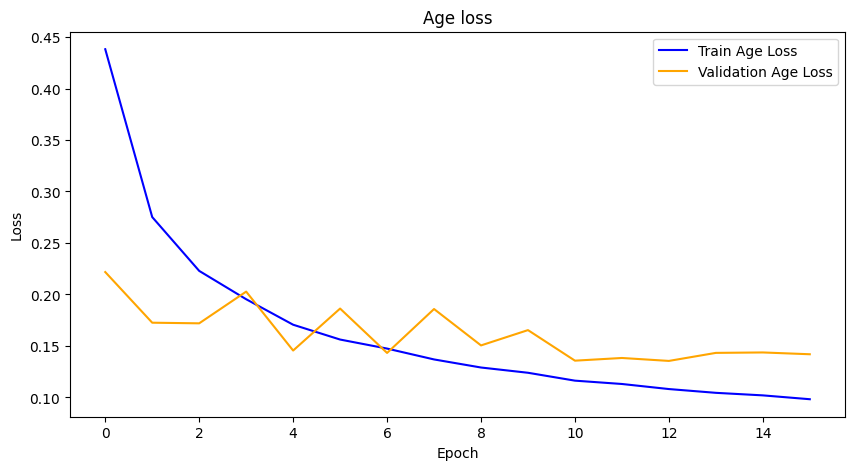

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_loss'], label='Train Age Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_loss'], label='Validation Age Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Age loss')
plt.legend()
plt.show()

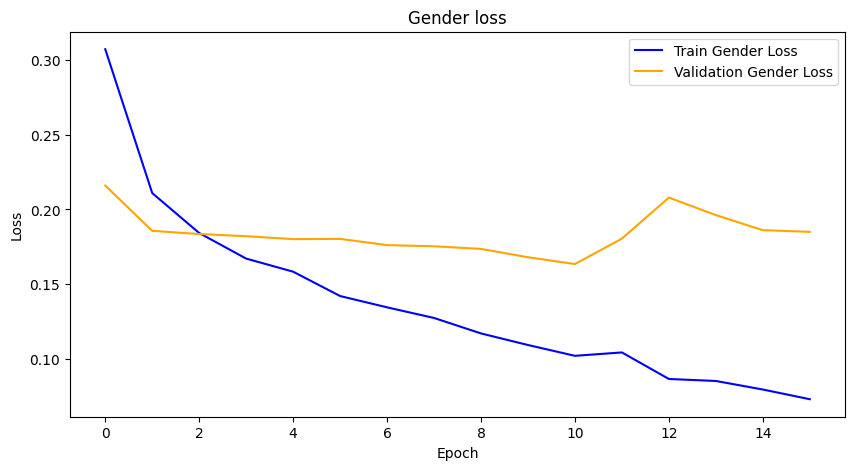

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_loss'], label='Train Gender Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_loss'], label='Validation Gender Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Gender loss')
plt.legend()
plt.show()

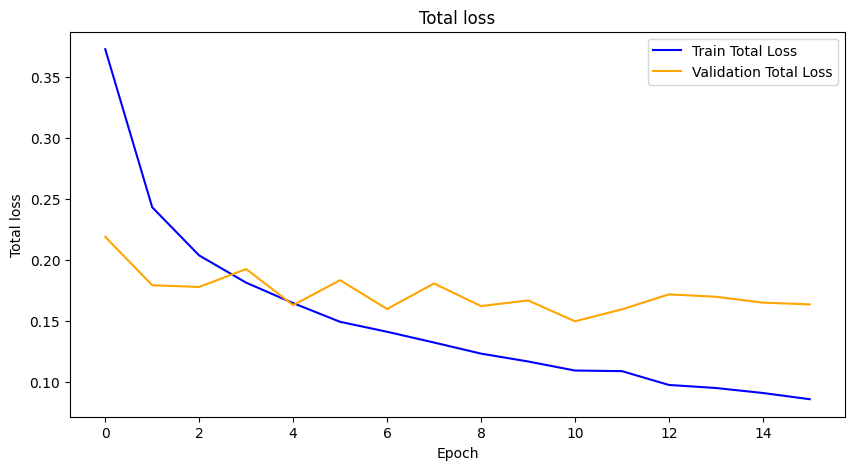

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_total_loss'], label='Train Total Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_total_loss'], label='Validation Total Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Total loss')
plt.title('Total loss')
plt.legend()
plt.show()

Augmentations have generally improved the models ability to generalize and even we can see that overfitting in gender classification has been reduced but it is still evident.

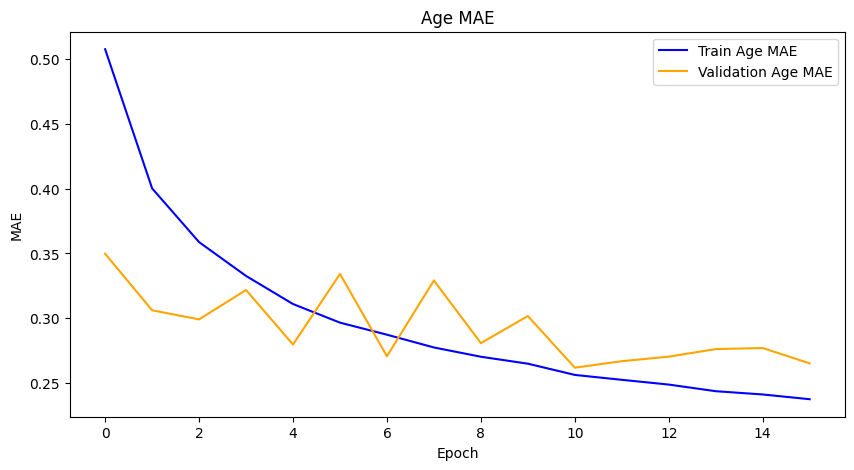

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_mae'], label='Train Age MAE', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_mae'], label='Validation Age MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age MAE')
plt.legend()
plt.show()

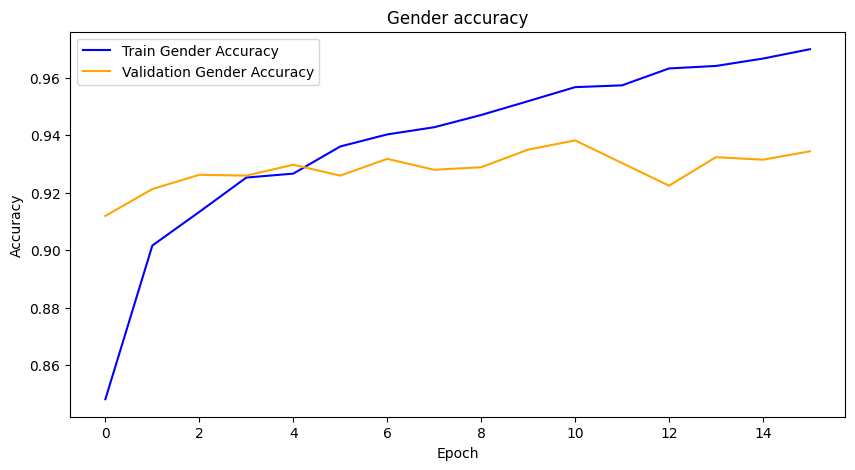

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_accuracy'], label='Train Gender Accuracy', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_accuracy'], label='Validation Gender Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender accuracy')
plt.legend()
plt.show()

We also observe reduced overfitting from gender validation and train accuracy plots. We will proceed with the augmented data.

In [ ]:
gender_probs = gender_preds.flatten()
roc_auc = roc_auc_score(gender_labels, gender_probs)
fpr, tpr, _ = roc_curve(gender_labels, gender_probs)

Gender ROC-AUC: 0.93


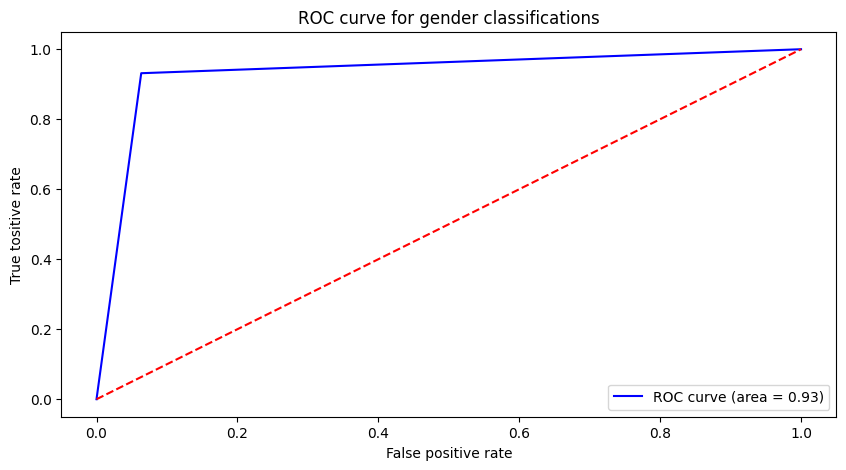

In [ ]:
print(f"Gender ROC-AUC: {roc_auc:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False positive rate")
plt.ylabel("True tositive rate")
plt.title("ROC curve for gender classifications")
plt.legend(loc="lower right")
plt.show()

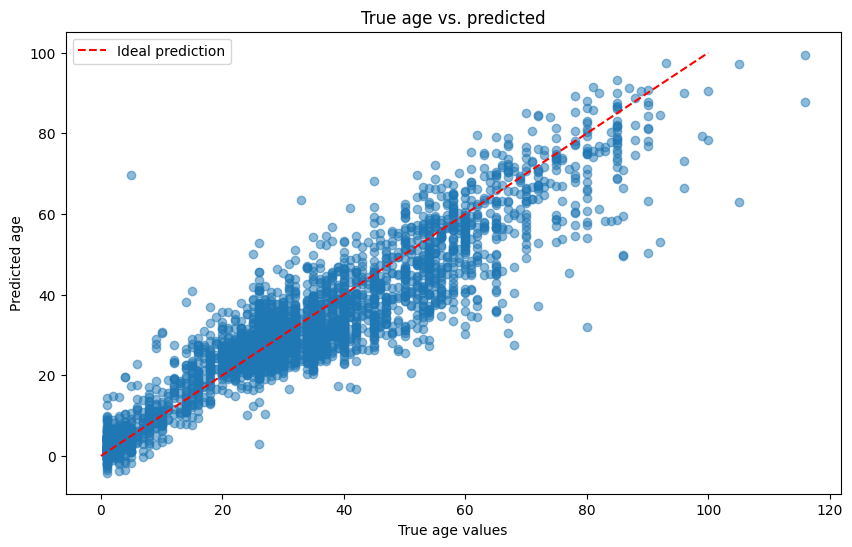

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(age_labels, age_preds, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--', label="Ideal prediction")
plt.xlabel("True age values")
plt.ylabel("Predicted age")
plt.title("True age vs. predicted")
plt.legend()
plt.show()

If we compare results of the model with and without augmentation we can see that there a slithly less extreme deviations from true age values when it comes to senior individuals. Below is the plot from previous model without augmentations.

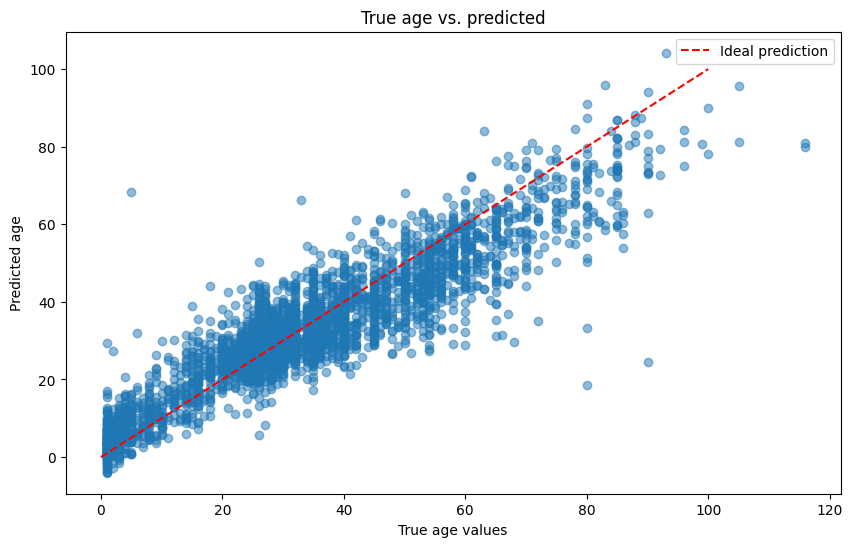

In [ ]:
model_MobileNetV2_best_w8_augm.eval()
total_time = 0.0
num_batches = len(val_dataloader)

for batch in val_dataloader:
    images, _, _ = batch
    with torch.no_grad():
        start_time = time.time()
        _ = model_MobileNetV2_best_w8_augm(images)
        end_time = time.time()

    total_time += (end_time - start_time)

average_inference_time = total_time / num_batches
print(f"Average inference time per batch: {average_inference_time:.4f} seconds")

Average inference time per batch: 1.9562 seconds


This also helped to improve model inference time.

We have a lot better results but we still can see some signs of overfitting. To combat that we will start by introduing learning rate scheduler with 3 epochs patience and factor 0.5.

##### Model with learning rate scheduler

In [ ]:
class AgeGenderModelMobileNetV2w8V2(pl.LightningModule):
    def __init__(self, learning_rate=0.00016277082236748248, dropout_rate=0.4825418581622139,
                 weight_decay=8.365806893223885e-06):
        super().__init__()

        self.base_model = models.mobilenet_v2(weights="MobileNet_V2_Weights.IMAGENET1K_V1")
        in_features = self.base_model.last_channel

        self.base_model.classifier = nn.Identity()

        for param in self.base_model.parameters():
            param.requires_grad = True

        self.dropout = nn.Dropout(dropout_rate)
        self.gender_output = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.Sigmoid()
        )
        self.age_output = nn.Linear(in_features, 1)

        self.gender_accuracy = BinaryAccuracy()
        self.age_mae = MeanAbsoluteError()
        self.age_loss_fn = nn.MSELoss()

        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

    def forward(self, x):
        features = self.base_model.features(x)
        features = features.mean([2, 3])
        features = self.dropout(features)
        gender_pred = self.gender_output(features).view(-1)
        age_pred = self.age_output(features).view(-1)
        return gender_pred, age_pred

    def compute_sample_weights(self, gender_labels):
        gender_np = gender_labels.cpu().numpy()
        sample_weights = compute_sample_weight(class_weight="balanced", y=gender_np)
        return torch.tensor(sample_weights, device=self.device, dtype=torch.float32)

    def training_step(self, batch, batch_idx):
        images, (gender_labels, age_labels), age_groups = batch
        gender_pred, age_pred = self(images)

        sample_weights = self.compute_sample_weights(gender_labels)

        gender_loss = F.binary_cross_entropy(gender_pred, gender_labels, weight=sample_weights)
        age_loss = self.age_loss_fn(age_pred, age_labels)
        total_loss = 0.5 * gender_loss + 0.5 * age_loss

        self.log("train_gender_loss", gender_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_age_loss", age_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True, batch_size=images.size(0))

        return total_loss

    def validation_step(self, batch, batch_idx):
        images, (gender_labels, age_labels), age_groups = batch
        gender_pred, age_pred = self(images)

        sample_weights = self.compute_sample_weights(gender_labels)

        gender_loss = F.binary_cross_entropy(gender_pred, gender_labels, weight=sample_weights)
        age_loss = self.age_loss_fn(age_pred, age_labels)
        total_loss = 0.5 * gender_loss + 0.5 * age_loss

        self.log("val_gender_loss", gender_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_age_loss", age_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_total_loss", total_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True, batch_size=images.size(0))

        return total_loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        scheduler = {
            'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3),
            'monitor': 'val_total_loss',
        }
        return [optimizer], [scheduler]

In [ ]:
model_MobileNetV2_updated = AgeGenderModelMobileNetV2w8V2(
    learning_rate=0.00016277082236748248,
    dropout_rate=0.4825418581622139,
    weight_decay=8.365806893223885e-06
)

In [ ]:
csv_logger_best_w8_augm_lrsch = CSVLogger("logs", name="AgeGenderModelMobileNetV2Bestw8Augmlrsch")

In [ ]:
trainer_best = pl.Trainer(
    max_epochs=20,
    logger=csv_logger_best_w8_augm_lrsch,
    callbacks=[checkpoint_callback_best, early_stopping_best],
    log_every_n_steps=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer_best.fit(model_MobileNetV2_updated, data_module_with_augmentations)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type              | Params | Mode 
--------------------------------------------------------------
0 | base_model      | MobileNetV2       | 2.2 M  | train
1 | dropout         | Dropout           | 0      | train
2 | gender_output   | Sequential        | 1.3 K  | train
3 | age_output      | Linear            | 1.3 K  | train
4 | gender_accuracy | BinaryAccuracy    | 0      | train
5 | age_mae         | MeanAbsoluteError | 0      | train
6 | age_loss_fn     | MSELoss           | 0      | train
--------------------------------------------------------------
2.2 M     Trainable params
0         Non-trainable params
2.2 M     Total params
8.906     Total estimated model params size (MB)
219       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
val_dataloader = data_module_with_augmentations.val_dataloader()

gender_preds = []
gender_labels = []
age_preds = []
age_labels = []

In [ ]:
for batch in val_dataloader:
    images, (gender, age), _ = batch
    with torch.no_grad():
        gender_pred, age_pred = model_MobileNetV2_updated(images)

    gender_preds.extend((gender_pred > 0.5).int().cpu().numpy().tolist())
    gender_labels.extend(gender.cpu().numpy().tolist())

    age_preds.extend(((age_pred.cpu().numpy() * age_std) + age_mean).tolist())
    age_labels.extend(((age.cpu().numpy() * age_std) + age_mean).tolist())

gender_preds = np.array(gender_preds)
gender_labels = np.array(gender_labels)
age_preds = np.array(age_preds)
age_labels = np.array(age_labels)

In [ ]:
print("Gender classification report:")
print(classification_report(gender_labels, gender_preds, target_names=["Male", "Female"]))

Gender classification report:
              precision    recall  f1-score   support

        Male       0.96      0.91      0.94      1796
      Female       0.91      0.96      0.93      1634

    accuracy                           0.93      3430
   macro avg       0.93      0.93      0.93      3430
weighted avg       0.94      0.93      0.93      3430



We can see that even there were few changes to the predictions accuracy and f1 score results did not change we still have 93% for both.

**Model with sample weights and image augmentation (+learning rate scheduler):**

Weighted avg accuracy: 93%

Weighted avg F1 score: 93%

**Model with sample weights and image augmentation:**

Weighted avg accuracy: 93%

Weighted avg F1 score: 93%

**Model with sample weights:**

Weighted avg accuracy: 92%

Weighted avg F1 score: 92%

**Model results without sample weights:**

Weighted avg accuracy: 90%

Weighted avg F1-score: 90%

**Baseline Model:**

Weighted avg accuracy: 82%

Weighted avg F1-score: 82%

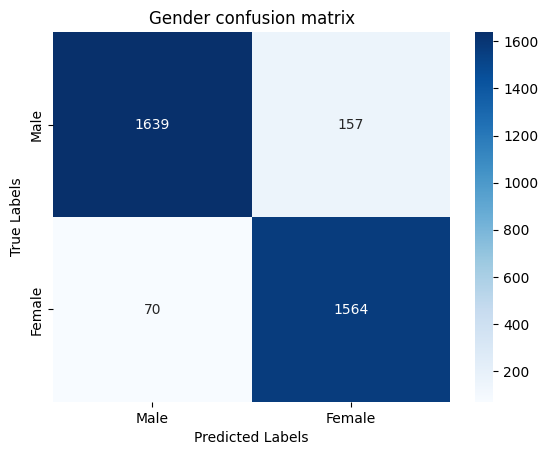

In [ ]:
conf_matrix = confusion_matrix(gender_labels, gender_preds)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Gender confusion matrix")
plt.show()

We can see that we have higher male accuracy, but lower recall and 1 extra missclassfication compared to the best model from before.

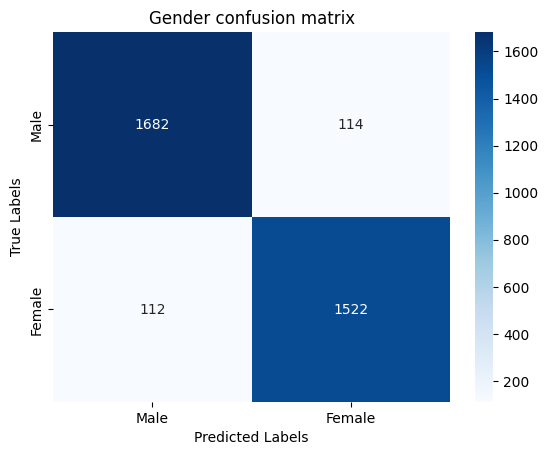

In [ ]:
age_mae = mean_absolute_error(age_labels, age_preds)
age_rmse = mean_squared_error(age_labels, age_preds, squared=False)

print(f"Age Mean Absolute Error (MAE): {age_mae:.2f}")
print(f"Age Root Mean Squared Error (RMSE): {age_rmse:.2f}")

Age Mean Absolute Error (MAE): 5.38
Age Root Mean Squared Error (RMSE): 7.54


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


With evey implementation we manage to get better age regression results even though at the slower rate. Results after introducing learning rate scheduler:

Age Mean Absolute Error (MAE): 5.38

Age Root Mean Squared Error (RMSE): 7.54

Without LR scheduler:

Age Mean Absolute Error (MAE): 5.51

Age Root Mean Squared Error (RMSE): 7.76

In [ ]:
log_dir = "logs/AgeGenderModelMobileNetV2Bestw8Augmlrsch/version_1/metrics.csv"
metrics_df = pd.read_csv(log_dir)

In [ ]:
train_data_metrics = metrics_df[metrics_df['train_age_loss'].notna()]
val_data_metrics = metrics_df[metrics_df['val_age_loss'].notna()]

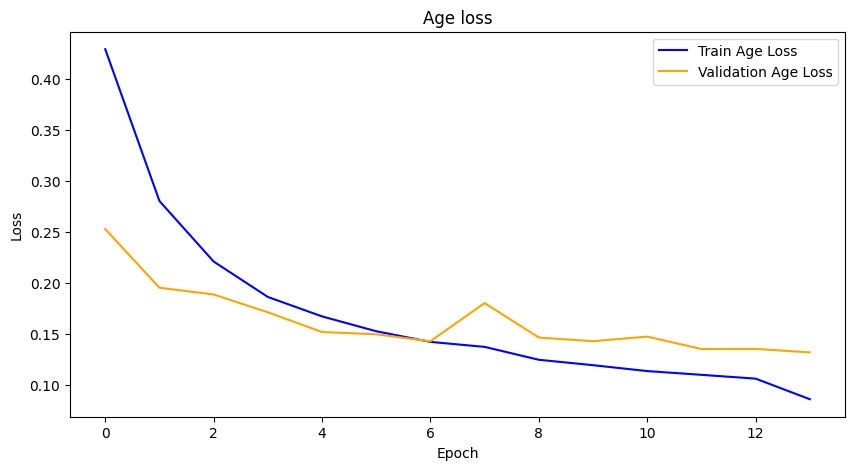

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_loss'], label='Train Age Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_loss'], label='Validation Age Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Age loss')
plt.legend()
plt.show()

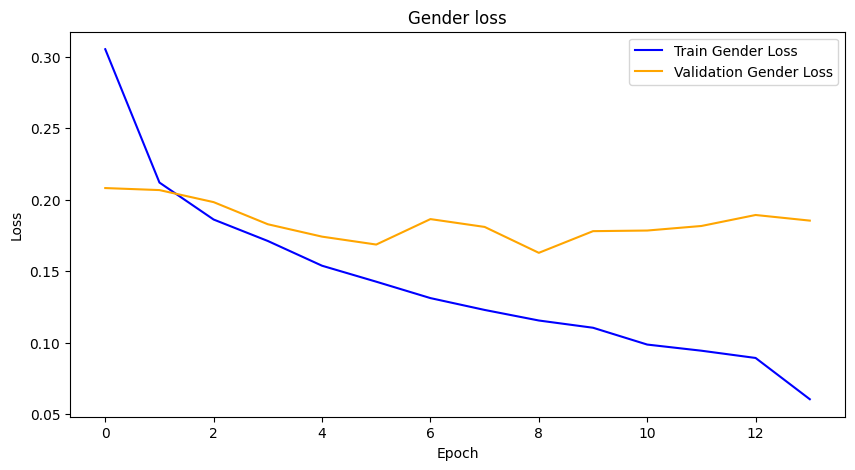

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_loss'], label='Train Gender Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_loss'], label='Validation Gender Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Gender loss')
plt.legend()
plt.show()

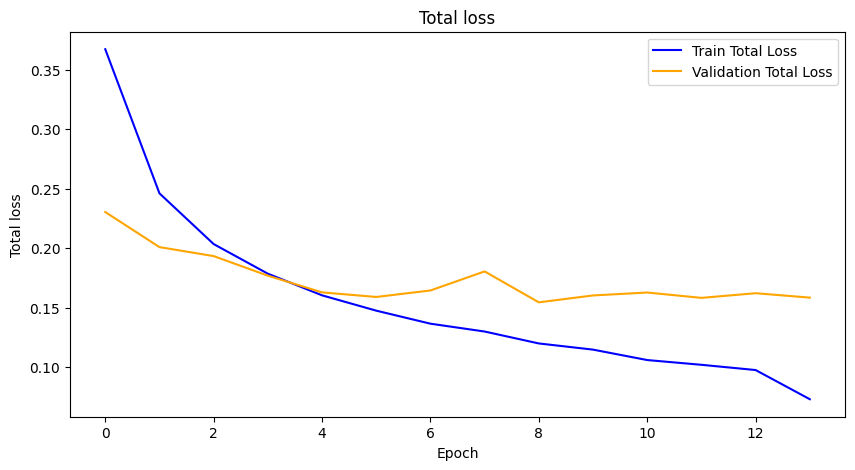

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_total_loss'], label='Train Total Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_total_loss'], label='Validation Total Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Total loss')
plt.title('Total loss')
plt.legend()
plt.show()

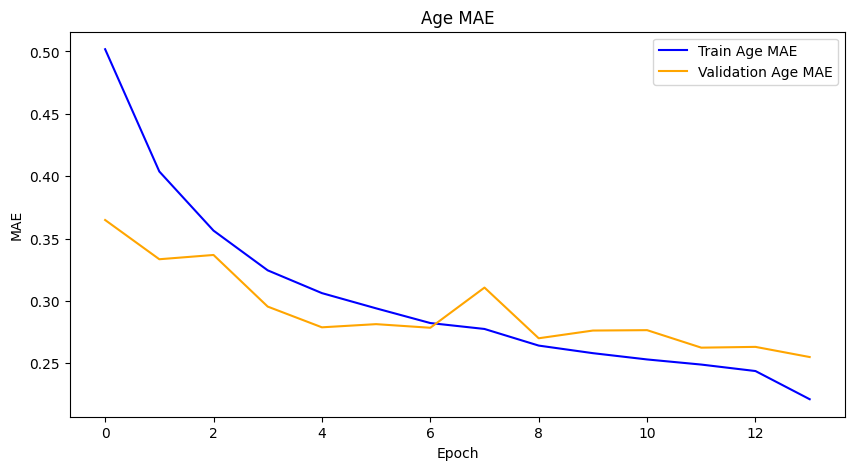

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_mae'], label='Train Age MAE', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_mae'], label='Validation Age MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age MAE')
plt.legend()
plt.show()

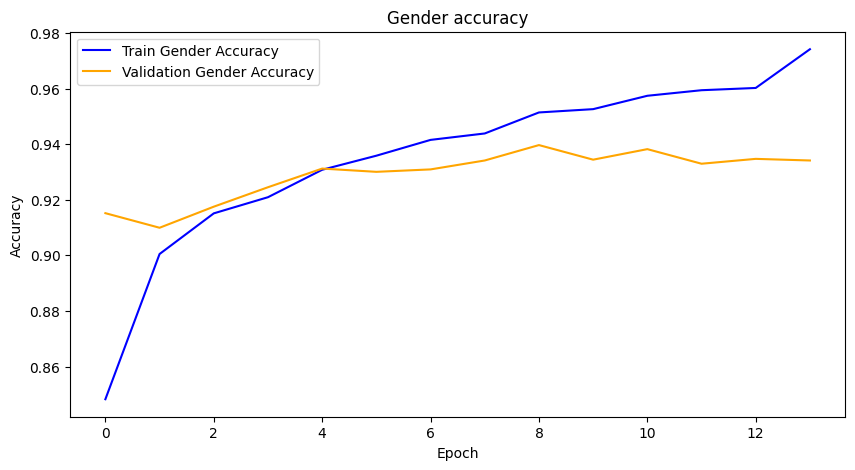

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_accuracy'], label='Train Gender Accuracy', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_accuracy'], label='Validation Gender Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender accuracy')
plt.legend()
plt.show()

From all 5 plots it is visible that the learning rate scheduler has improved the alignment between training and validation metrics reducing signs of overfitting.

Since the gender loss appears to contribute more to the total loss while the age loss shows better convergence we will adjust the weighting of the losses. We will reduce the weight for the gender loss to 0.45 and increase the weight for the age loss to 0.55 to observe how this adjustment impacts our results.

In [ ]:
gender_probs = gender_preds.flatten()
roc_auc = roc_auc_score(gender_labels, gender_probs)
fpr, tpr, _ = roc_curve(gender_labels, gender_probs)

Gender ROC-AUC: 0.93


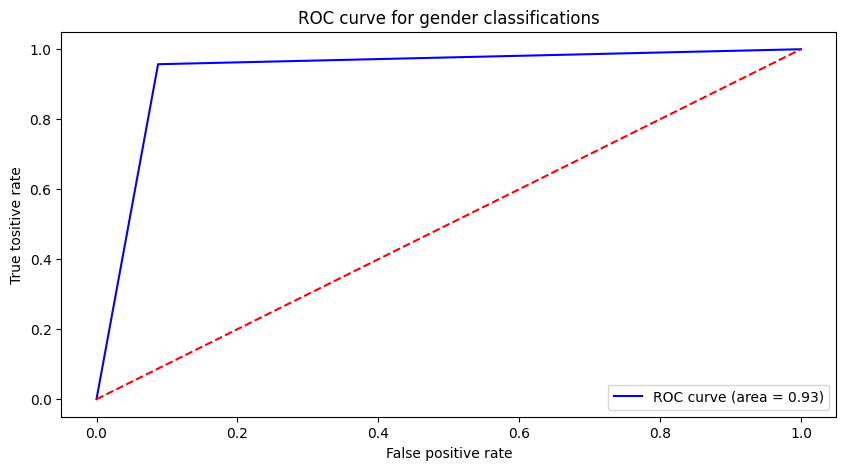

In [ ]:
print(f"Gender ROC-AUC: {roc_auc:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False positive rate")
plt.ylabel("True tositive rate")
plt.title("ROC curve for gender classifications")
plt.legend(loc="lower right")
plt.show()

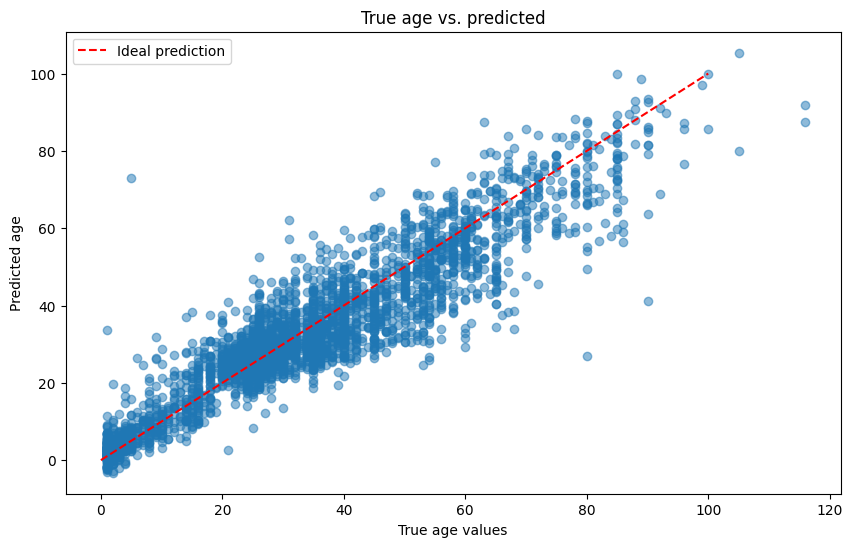

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(age_labels, age_preds, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--', label="Ideal prediction")
plt.xlabel("True age values")
plt.ylabel("Predicted age")
plt.title("True age vs. predicted")
plt.legend()
plt.show()

From both ROC-AUC curve and age predictions plot we can'st strong differences.

In [ ]:
model_MobileNetV2_updated.eval()
total_time = 0.0
num_batches = len(val_dataloader)

for batch in val_dataloader:
    images, _, _ = batch
    with torch.no_grad():
        start_time = time.time()
        _ = model_MobileNetV2_updated(images)
        end_time = time.time()

    total_time += (end_time - start_time)

average_inference_time = total_time / num_batches
print(f"Average inference time per batch: {average_inference_time:.4f} seconds")

Average inference time per batch: 2.0523 seconds


Even though model improved it's age prediction abilities model inference time is a bit slower.

##### Model with updated total loss weights

As a final experiment we are going to see what it does to our results different weights asigned to the total loss, we are going to give a bit greater weight to age loss as it is converging better than gender accuracy. Total loss will be a combination of 45% of gender loss and 55% of age loss.

In [ ]:
class AgeGenderModelMobileNetV2w8V3(pl.LightningModule):
    def __init__(self, learning_rate=0.00016277082236748248, dropout_rate=0.4825418581622139,
                 weight_decay=8.365806893223885e-06):
        super().__init__()

        self.base_model = models.mobilenet_v2(weights="MobileNet_V2_Weights.IMAGENET1K_V1")
        in_features = self.base_model.last_channel

        self.base_model.classifier = nn.Identity()

        for param in self.base_model.parameters():
            param.requires_grad = True

        self.dropout = nn.Dropout(dropout_rate)
        self.gender_output = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.Sigmoid()
        )
        self.age_output = nn.Linear(in_features, 1)

        self.gender_accuracy = BinaryAccuracy()
        self.age_mae = MeanAbsoluteError()
        self.age_loss_fn = nn.MSELoss()

        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

    def forward(self, x):
        features = self.base_model.features(x)
        features = features.mean([2, 3])
        features = self.dropout(features)
        gender_pred = self.gender_output(features).view(-1)
        age_pred = self.age_output(features).view(-1)
        return gender_pred, age_pred

    def compute_sample_weights(self, gender_labels):
        gender_np = gender_labels.cpu().numpy()
        sample_weights = compute_sample_weight(class_weight="balanced", y=gender_np)
        return torch.tensor(sample_weights, device=self.device, dtype=torch.float32)

    def training_step(self, batch, batch_idx):
        images, (gender_labels, age_labels), age_groups = batch
        gender_pred, age_pred = self(images)


        sample_weights = self.compute_sample_weights(gender_labels)

        gender_loss = F.binary_cross_entropy(gender_pred, gender_labels, weight=sample_weights)
        age_loss = self.age_loss_fn(age_pred, age_labels)
        total_loss = 0.45 * gender_loss + 0.55 * age_loss #changing weights

        self.log("train_gender_loss", gender_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_age_loss", age_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("train_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True, batch_size=images.size(0))

        return total_loss

    def validation_step(self, batch, batch_idx):
        images, (gender_labels, age_labels), age_groups = batch
        gender_pred, age_pred = self(images)

        sample_weights = self.compute_sample_weights(gender_labels)

        gender_loss = F.binary_cross_entropy(gender_pred, gender_labels, weight=sample_weights)
        age_loss = self.age_loss_fn(age_pred, age_labels)
        total_loss = 0.45 * gender_loss + 0.55 * age_loss

        self.log("val_gender_loss", gender_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_age_loss", age_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_total_loss", total_loss, on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_gender_accuracy", self.gender_accuracy(gender_pred, gender_labels), on_step=False, on_epoch=True, batch_size=images.size(0))
        self.log("val_age_mae", self.age_mae(age_pred, age_labels), on_step=False, on_epoch=True, batch_size=images.size(0))

        return total_loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        scheduler = {
            'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3),
            'monitor': 'val_total_loss',
        }
        return [optimizer], [scheduler]

In [ ]:
model_MobileNetV2_updated_diffw8 = AgeGenderModelMobileNetV2w8V3(
    learning_rate=0.00016277082236748248,
    dropout_rate=0.4825418581622139,
    weight_decay=8.365806893223885e-06
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 36.9MB/s]


In [ ]:
csv_logger_best_w8_augm_lrsch_lossw8 = CSVLogger("logs", name="AgeGenderModelMobileNetV2Bestw8Augmlrschanddiffw8")

In [ ]:
trainer_best = pl.Trainer(
    max_epochs=20,
    logger=csv_logger_best_w8_augm_lrsch_lossw8,
    callbacks=[checkpoint_callback_best, early_stopping_best],
    log_every_n_steps=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer_best.fit(model_MobileNetV2_updated_diffw8, data_module_with_augmentations)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type              | Params | Mode 
--------------------------------------------------------------
0 | base_model      | MobileNetV2       | 2.2 M  | train
1 | dropout         | Dropout           | 0      | train
2 | gender_output   | Sequential        | 1.3 K  | train
3 | age_output      | Linear            | 1.3 K  | train
4 | gender_accuracy | BinaryAccuracy    | 0      | train
5 | age_mae         | MeanAbsoluteError | 0      | train
6 | age_loss_fn     | MSELoss           | 0      | train
--------------------------------------------------------------
2.2 M     Trainable params
0         Non-trainable params
2.2 M     Total params
8.906     Total estimated model params size (MB)
219       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
val_dataloader = data_module_with_augmentations.val_dataloader()

gender_preds = []
gender_labels = []
age_preds = []
age_labels = []

In [ ]:
for batch in val_dataloader:
    images, (gender, age), _ = batch
    with torch.no_grad():
        gender_pred, age_pred = model_MobileNetV2_updated_diffw8(images)

    gender_preds.extend((gender_pred > 0.5).int().cpu().numpy().tolist())
    gender_labels.extend(gender.cpu().numpy().tolist())

    age_preds.extend(((age_pred.cpu().numpy() * age_std) + age_mean).tolist())
    age_labels.extend(((age.cpu().numpy() * age_std) + age_mean).tolist())

gender_preds = np.array(gender_preds)
gender_labels = np.array(gender_labels)
age_preds = np.array(age_preds)
age_labels = np.array(age_labels)

In [ ]:
print("Gender classification report:")
print(classification_report(gender_labels, gender_preds, target_names=["Male", "Female"]))

Gender classification report:
              precision    recall  f1-score   support

        Male       0.94      0.93      0.93      1796
      Female       0.92      0.94      0.93      1634

    accuracy                           0.93      3430
   macro avg       0.93      0.93      0.93      3430
weighted avg       0.93      0.93      0.93      3430



**Model with sample weights and image augmentation (+learning rate scheduler, + weighted total loss):**

Weighted avg accuracy: 93%

Weighted avg F1 score: 93%


**Model with sample weights and image augmentation (+learning rate scheduler):**

Weighted avg accuracy: 93%

Weighted avg F1 score: 93%

**Model with sample weights and image augmentation:**

Weighted avg accuracy: 93%

Weighted avg F1 score: 93%

**Model with sample weights:**

Weighted avg accuracy: 92%

Weighted avg F1 score: 92%

**Model results without sample weights:**

Weighted avg accuracy: 90%

Weighted avg F1-score: 90%

**Baseline Model:**

Weighted avg accuracy: 82%

Weighted avg F1-score: 82%

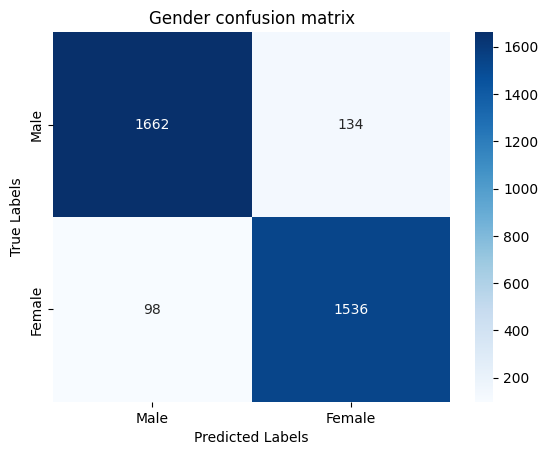

In [ ]:
conf_matrix = confusion_matrix(gender_labels, gender_preds)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Gender confusion matrix")
plt.show()

We have a again slightly more missclassification (6 more) compared to the model where we introduced augmentation and did not use lr scheduler. That model had the lowest number of missclassfication 226 in total.

In [ ]:
age_mae = mean_absolute_error(age_labels, age_preds)
age_rmse = mean_squared_error(age_labels, age_preds, squared=False)

print(f"Age Mean Absolute Error (MAE): {age_mae:.2f}")
print(f"Age Root Mean Squared Error (RMSE): {age_rmse:.2f}")

Age Mean Absolute Error (MAE): 5.24
Age Root Mean Squared Error (RMSE): 7.41


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Changed total loss weights improved age MAE and RMSE by 0.14 and 0.13 accordingly.

Best results from the model before:
Age Mean Absolute Error (MAE): 5.38
Age Root Mean Squared Error (RMSE): 7.54

In [ ]:
log_dir = "logs/AgeGenderModelMobileNetV2Bestw8Augmlrschanddiffw8/version_0/metrics.csv"
metrics_df = pd.read_csv(log_dir)

In [ ]:
train_data_metrics = metrics_df[metrics_df['train_age_loss'].notna()]
val_data_metrics = metrics_df[metrics_df['val_age_loss'].notna()]

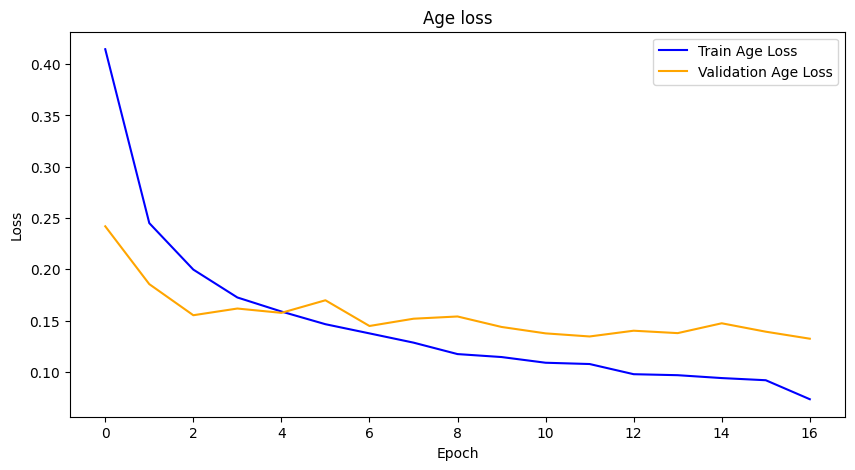

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_loss'], label='Train Age Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_loss'], label='Validation Age Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Age loss')
plt.legend()
plt.show()

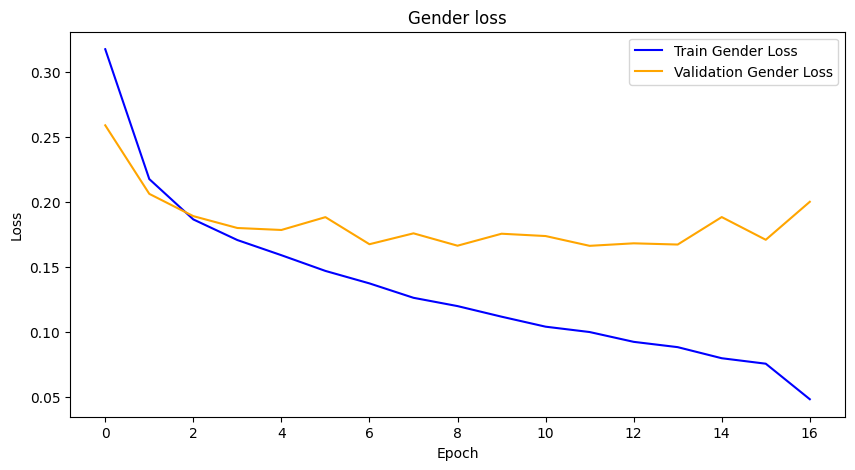

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_loss'], label='Train Gender Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_loss'], label='Validation Gender Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Gender loss')
plt.legend()
plt.show()

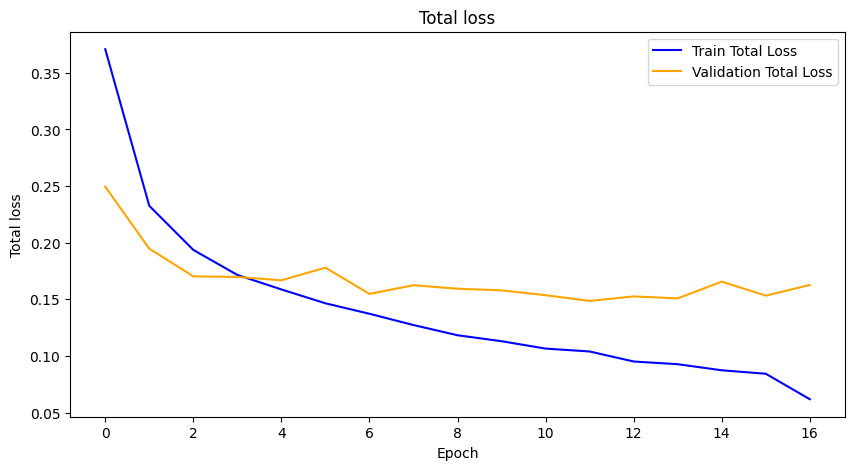

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_total_loss'], label='Train Total Loss', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_total_loss'], label='Validation Total Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Total loss')
plt.title('Total loss')
plt.legend()
plt.show()

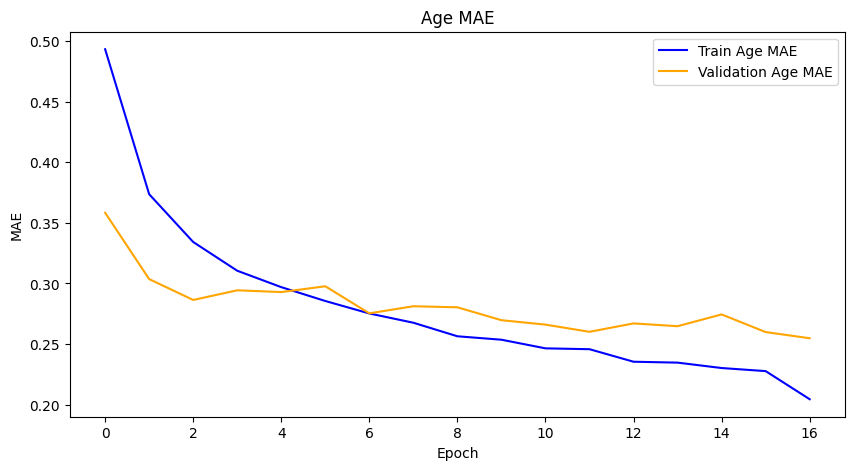

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_age_mae'], label='Train Age MAE', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_age_mae'], label='Validation Age MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age MAE')
plt.legend()
plt.show()

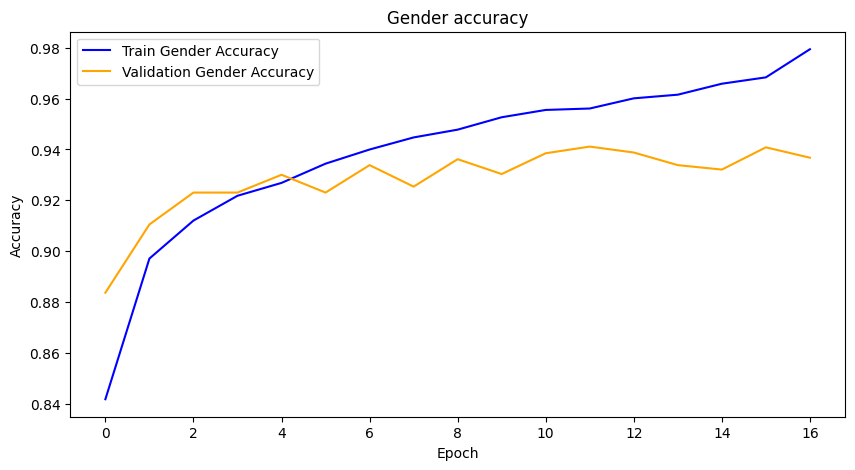

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_data_metrics['epoch'], train_data_metrics['train_gender_accuracy'], label='Train Gender Accuracy', color='blue')
plt.plot(val_data_metrics['epoch'], val_data_metrics['val_gender_accuracy'], label='Validation Gender Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender accuracy')
plt.legend()
plt.show()

It is challenging to evaluate the impact of small changes made to the total loss and the accuracy of each task. We continue to observe signs of overfitting particularly in gender classification which suggests that additional adjustments to hyperparameters may be necessary to better regularize the model or more possibly few more suitable augmentations that would reflect real life images.

In [ ]:
gender_probs = gender_preds.flatten()
roc_auc = roc_auc_score(gender_labels, gender_probs)
fpr, tpr, _ = roc_curve(gender_labels, gender_probs)

Gender ROC-AUC: 0.93


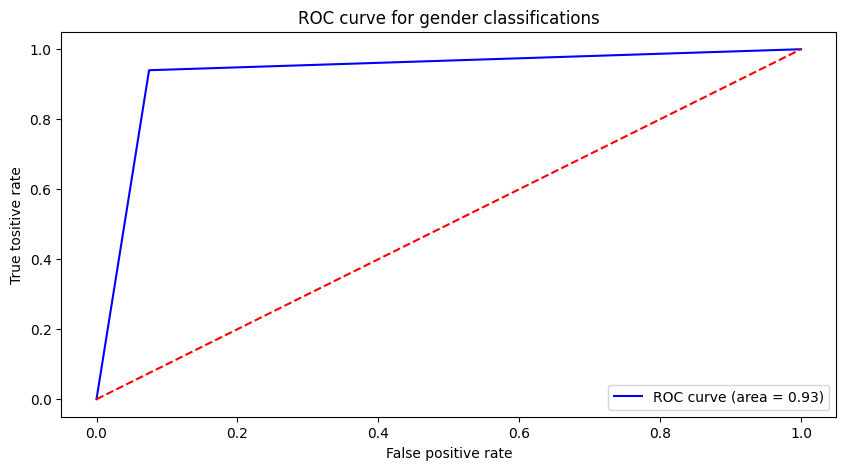

In [ ]:
print(f"Gender ROC-AUC: {roc_auc:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False positive rate")
plt.ylabel("True tositive rate")
plt.title("ROC curve for gender classifications")
plt.legend(loc="lower right")
plt.show()

ROC-AUC score did not improve.

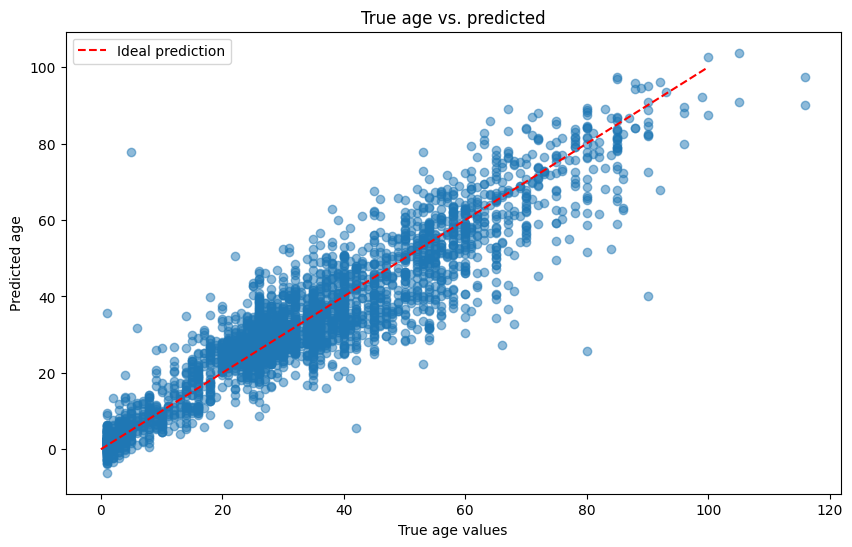

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(age_labels, age_preds, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--', label="Ideal prediction")
plt.xlabel("True age values")
plt.ylabel("Predicted age")
plt.title("True age vs. predicted")
plt.legend()
plt.show()

We are not oberserving any significant differences to the age regression results.

In [ ]:
model_MobileNetV2_updated_diffw8.eval()
total_time = 0.0
num_batches = len(val_dataloader)

for batch in val_dataloader:
    images, _, _ = batch
    with torch.no_grad():
        start_time = time.time()
        _ = model_MobileNetV2_updated_diffw8(images)
        end_time = time.time()

    total_time += (end_time - start_time)

average_inference_time = total_time / num_batches
print(f"Average inference time per batch: {average_inference_time:.4f} seconds")

Average inference time per batch: 1.9394 seconds


So far this model is the fastest when it comes to the inference: 1.94 second per batch on average and so 0.12 second per image.

We have selected to evaluate the last model with slightly weighted total loss for the evaluation. To conclude this part we see it is important to mention about what else has been considered to this multitask project. VGG16 model demonstrated promising results and could have been a worthwhile candidate for further exploration. Given the imbalance in the dataset across all three dimensions gender, age and race targeted augmentation might have been the experiment to address these imbalances. Also exploring different weights for the total loss function might have yield improvements by balancing the contributions of each task. It would also be valuable to investigate whether optimizing each task independently could have enhance overall performance and reduce overfitting.

### Model evaluation

In this part we will check our final model with the test set. First we will check how different main evaluation metrics are, accuracy, f1 score, ROC-AUC, MAE and RMSE. Second we will check how different are results on several dimensions gender, age and race groups. Finally, we will have a look at what areas model is paying attention when making a predictions using LIME.

#### General evaluation metrics

In [ ]:
model = AgeGenderModelMobileNetV2w8V3.load_from_checkpoint(
    "logs/AgeGenderModelMobileNetV2Bestw8Augmlrschanddiffw8/version_0/checkpoints/best-checkpoint.ckpt"
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
model.eval()

AgeGenderModelMobileNetV2w8V3(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(1

In [ ]:
data_module_with_augmentations.setup(stage="test")
test_dataloader = data_module_with_augmentations.test_dataloader()

In [ ]:
gender_preds, gender_labels = [], []
age_preds, age_labels = [], []

In [ ]:
for batch in test_dataloader:
    images, (gender, age), _ = batch

    images = images.to(device)
    gender = gender.to(device)
    age = age.to(device)

    with torch.no_grad():
        gender_pred, age_pred = model(images)

    gender_preds.extend((gender_pred > 0.5).int().cpu().numpy().tolist())
    gender_labels.extend(gender.cpu().numpy().tolist())

    age_preds.extend(((age_pred.cpu().numpy() * age_std) + age_mean).tolist())
    age_labels.extend(((age.cpu().numpy() * age_std) + age_mean).tolist())

In [ ]:
gender_preds = np.array(gender_preds)
gender_labels = np.array(gender_labels)
age_preds = np.array(age_preds)
age_labels = np.array(age_labels)

In [ ]:
gender_classification_report = classification_report(gender_labels, gender_preds, target_names=["Male", "Female"])

In [ ]:
print(gender_classification_report)

              precision    recall  f1-score   support

        Male       0.96      0.91      0.93      1794
      Female       0.91      0.95      0.93      1636

    accuracy                           0.93      3430
   macro avg       0.93      0.93      0.93      3430
weighted avg       0.93      0.93      0.93      3430



We observe that the results on the test set closely align with those from the validation set, which indicates strong generalization and consistency. While there is still room for improvement in specific areas the model demonstrates its ability to perform well on unseen data at this stage.

In [ ]:
conf_matrix = confusion_matrix(gender_labels, gender_preds)

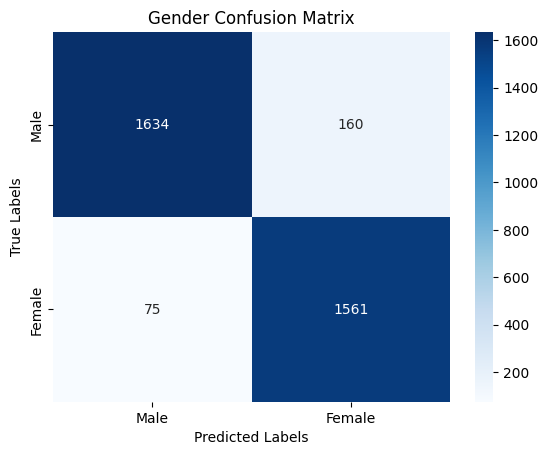

In [ ]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Gender Confusion Matrix")
plt.show()

The confusion matrix results are good as well showing that only 160 males and 75 females were misclassified. We will take a closer look at these misclassified images to better understand the specific challenges the model might have had and identify potential areas for improvement.

In [ ]:
age_mae = mean_absolute_error(age_labels, age_preds)
age_rmse = mean_squared_error(age_labels, age_preds, squared=False)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
print(f"Age Mean Absolute Error (MAE): {age_mae:.2f}")
print(f"Age Root Mean Squared Error (RMSE): {age_rmse:.2f}")

Age Mean Absolute Error (MAE): 5.16
Age Root Mean Squared Error (RMSE): 7.21


The Age MAE and RMSE results are even better than those from the validation set. On average the models age predictions are off by only 5.16 years. We will also closely examine these predictions to better understand where the model performs well and where it struggles.

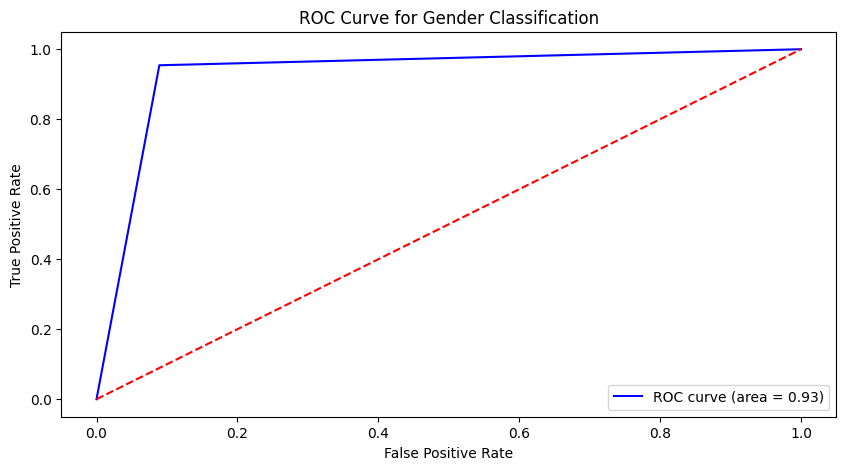

In [ ]:
gender_probs = gender_preds.flatten()
roc_auc = roc_auc_score(gender_labels, gender_probs)
fpr, tpr, _ = roc_curve(gender_labels, gender_probs)

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Gender Classification")
plt.legend(loc="lower right")
plt.show()

The ROC-AUC score of 0.93 indicates a strong balance between true positives and false positives demonstrating that the model is making confident predictions for gender.

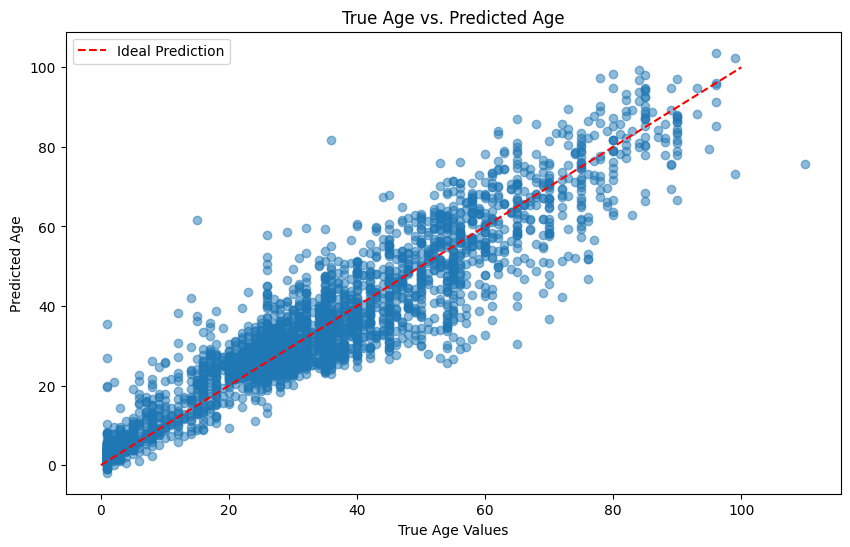

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(age_labels, age_preds, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--', label="Ideal Prediction")
plt.xlabel("True Age Values")
plt.ylabel("Predicted Age")
plt.title("True Age vs. Predicted Age")
plt.legend()
plt.show()

While there are still some severely incorrect age predictions, the predictions appear to be well concentrated around the ideal prediction line.

In [ ]:
eval_df = pd.DataFrame({
    "True Age": age_labels,
    "Predicted Age": age_preds,
    "True Gender": gender_labels,
    "Predicted Gender": gender_preds,
    "Race": test_data["race"].tolist(),
    "Age Group": test_data["age_group"].tolist()
})

In [ ]:
eval_df["Residuals"] = eval_df["True Age"] - eval_df["Predicted Age"]

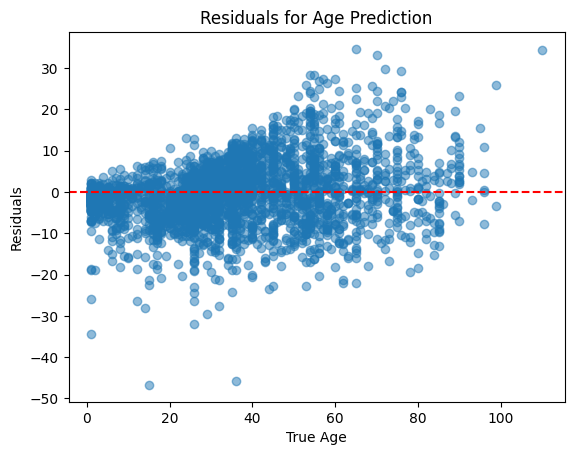

In [ ]:
plt.scatter(eval_df["True Age"], eval_df["Residuals"], alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("True Age")
plt.ylabel("Residuals")
plt.title("Residuals for Age Prediction")
plt.show()

Most residuals are around the red line which indicates zero residuals showing that the predictions are generally unbiased across age groups, but residuals becomes spread out around higher age indicating that the model struggles to predict age accurately for older individuals. We can see that for children model seems to be overestimating age as for those individuals we can see high negative residuals values. We will take a loot at few examples that have the highest absulute age error.


In [ ]:
eval_df["Absolute Error"] = np.abs(eval_df["True Age"] - eval_df["Predicted Age"])
largest_errors = eval_df.nlargest(5, "Absolute Error")

True Age: 15.0, Predicted Age: 61.73139190673828, Error: 46.73139190673828


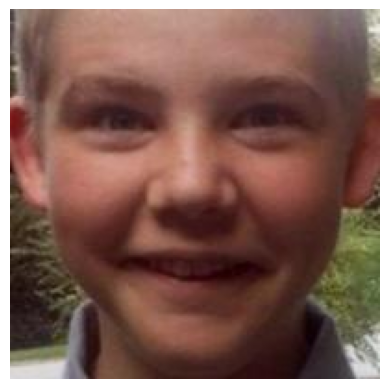

True Age: 36.0, Predicted Age: 81.67939758300781, Error: 45.67939758300781


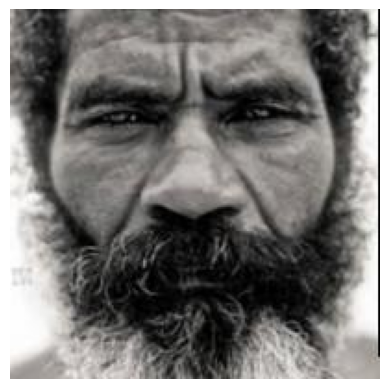

True Age: 65.0, Predicted Age: 30.373388290405273, Error: 34.62661170959473


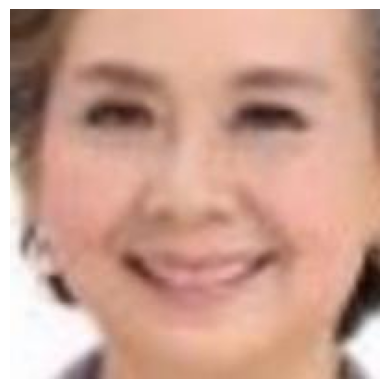

True Age: 110.0, Predicted Age: 75.57955932617188, Error: 34.420440673828125


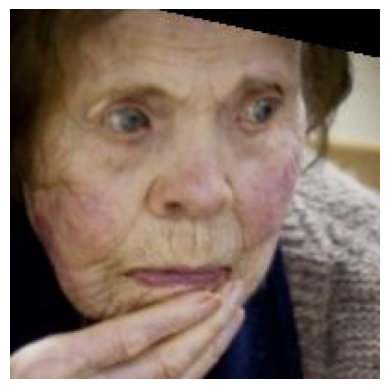

True Age: 1.0, Predicted Age: 35.40334701538086, Error: 34.40334701538086


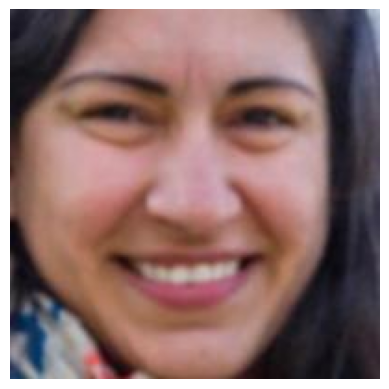

In [ ]:
for _, row in largest_errors.iterrows():
    print(f"True Age: {row['True Age']}, Predicted Age: {row['Predicted Age']}, Error: {row['Absolute Error']}")
    image = Image.open(row["File Path"]).convert("RGB")
    plt.imshow(image)
    plt.axis("off")
    plt.show()

We can see that it is well possible that one of the images is incorrectly label. The last picture of what seems a woman true age is 1 year, which not possible. One other example is very blur this could have influenced model not to capture important features and therefor prediction was younger than the true value, most likely there are more case like this, model has to be either thought to be able to campture features even in the blurry pictures or images quality has to be improved. Other cases are interesting as well, but it is hard to see what features influenced the prediction.

#### Grouped metrics by gender, age groups and race.

In [ ]:
male_mae = mean_absolute_error(age_labels[gender_labels == 0], age_preds[gender_labels == 0])
female_mae = mean_absolute_error(age_labels[gender_labels == 1], age_preds[gender_labels == 1])

In [ ]:
print(f"Male Age MAE: {male_mae:.2f}")
print(f"Female Age MAE: {female_mae:.2f}")

Male Age MAE: 5.48
Female Age MAE: 4.82


We can see that the model predicts ages for females more accurately than for males, with an entire 1 year difference in mean absolute error.

In [ ]:
grouped_metrics_age = eval_df.groupby("Age Group").apply(
    lambda df: pd.Series({
        "Age MAE": mean_absolute_error(df["True Age"], df["Predicted Age"]),
        "Gender Accuracy": accuracy_score(df["True Gender"], df["Predicted Gender"])
    })
)

In [ ]:
print("Metrics grouped by Age Group:")
print(grouped_metrics_age)

Metrics grouped by Age Group:
              Age MAE  Gender Accuracy
Age Group                             
Adult        7.079759         0.984273
Child        3.093766         0.730769
Senior       7.957410         0.964876
Teen         6.001584         0.906433
Young Adult  3.885126         0.962451


From the results we can see that senior individuals exhibit the highest age prediction error while children have the lowest error. This trend can be expected as absolute errors tend to increase with larger true age values making predictions errors for seniors more challenging.

Additionally, the model struggles the most with gender classification for children. This is also reasonable as distinguishing gender features in very young individuals can be hard. Improving performance in this group would likely require more diverse and better quality examples.

The model performs exceptionally well for adults, achieving the highest gender accuracy 98% even though it did not have great amount of images.

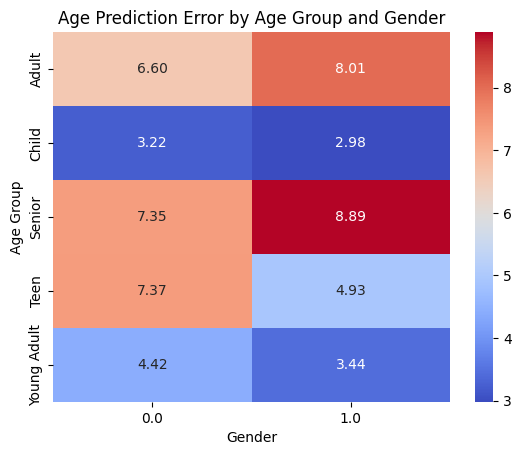

In [ ]:
heatmap_data = eval_df.groupby(["Age Group", "True Gender"]).apply(
    lambda df: mean_absolute_error(df["True Age"], df["Predicted Age"])
).unstack()

sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Age Prediction Error by Age Group and Gender")
plt.xlabel("Gender")
plt.ylabel("Age Group")
plt.show()

We can see that age regression performs well for children and young adults but struggles with adults, seniors and male teens. If we address these biases this will likely reduce errors and improve overall performance. We have seen from EDA part that adult group was most imbalanced when it comes gender only about 34% of that group images are females and age MAE is worse by almost year and half, targeted augmenations could also be method that could improve these results. We can also see a biggest difference in teen group, even though it was only slithly imbalanced (1:44%, 0:56%). This can't be explained by dataset bias. Images of this group and especially males images should be reviewed.

Results from EDA:

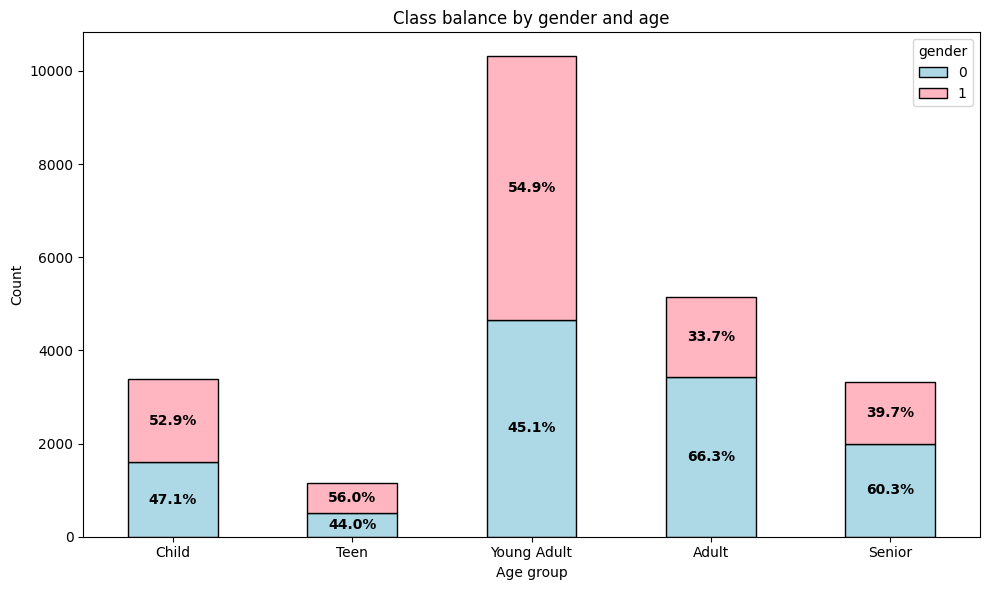

In [ ]:
grouped_metrics_age_race = eval_df.groupby(["Age Group", "Race"]).apply(
    lambda df: pd.Series({
        "Age MAE": mean_absolute_error(df["True Age"], df["Predicted Age"]),
        "Gender Accuracy": accuracy_score(df["True Gender"], df["Predicted Gender"]),
        "Gender F1 Score": f1_score(df["True Gender"], df["Predicted Gender"], average="binary")
    })
).reset_index()

In [ ]:
race_mapping = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others"
}

In [ ]:
grouped_metrics_age_race["Race"] = grouped_metrics_age_race["Race"].map(race_mapping)

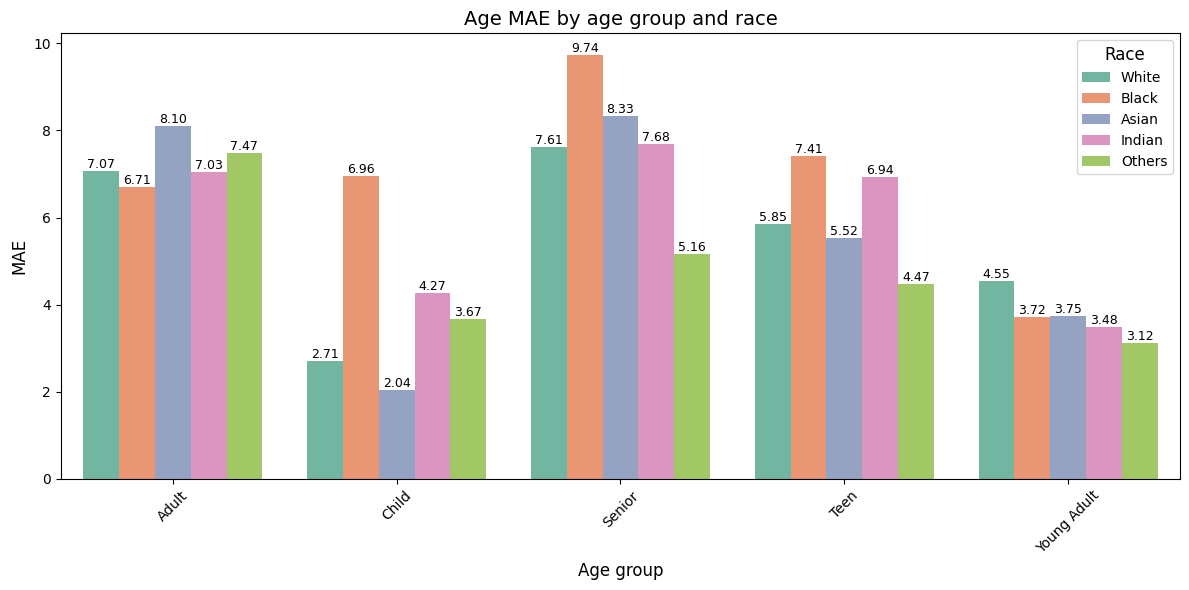

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=grouped_metrics_age_race,
    x="Age Group",
    y="Age MAE",
    hue="Race",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=9)

plt.title("Age MAE by age group and race", fontsize=14)
plt.xlabel("Age group", fontsize=12)
plt.ylabel("MAE", fontsize=12)
plt.legend(title="Race", fontsize=10, title_fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()

We can see that highest MAE was amongst black senior individuals and lowest among asian children. Most consinstent mean average error was amongst Young Adults.

In [ ]:
grouped_metrics_race = eval_df.groupby("Race").apply(
    lambda df: pd.Series({
        "Age MAE": mean_absolute_error(df["True Age"], df["Predicted Age"]),
        "Gender Accuracy": accuracy_score(df["True Gender"], df["Predicted Gender"])
    })
)

In [ ]:
print("\nMetrics grouped by Race:")
print(grouped_metrics_race)


Metrics grouped by Race:
       Age MAE  Gender Accuracy
Race                           
0     5.722077         0.941217
1     5.251937         0.934451
2     4.171185         0.904192
3     4.964251         0.926957
4     4.019482         0.931915


From the results we can see that white (0) and black (1) individuals exhibit the highest age prediction errors, even though these groups have the largest number of samples in the dataset. This might indicate that the increased data diversity within these groups introduces more variation leading to higher errors. The lowest MAE is observed for other (4) individuals despite their underrepresentation in the dataset.

In terms of gender classification accuracy the pattern is opposite. White individuals achieve the highest accuracy, while asian individuals (2) have a gender accuracy that is almost 4% lower. Model might be bias towards the majority class during training.

From these reults we can see that well balanced on the race dimension set could improve it's overall results. Targeted more extensive augmentation might improve our results maybe with even slight undersampling to reduce possible bias. More advanced way could be to use generative adversarial networks and generate synthetic data for the underrepresented groups.

#### LIME analysis

First we will take a look at the areas that contributed positively to the female probabilities as we had a little less images of them in the set.

In [ ]:
def lime_explain_gender(model, image, device):
    explainer = lime_image.LimeImageExplainer()
    segmentation_fn = SegmentationAlgorithm('slic', n_segments=50, compactness=10, sigma=1)

    def classifier_fn(images):
        images_tensor = torch.tensor(images).permute(0, 3, 1, 2).to(device).float()
        with torch.no_grad():
            gender_pred, _ = model(images_tensor)
        gender_probs = torch.sigmoid(gender_pred).cpu().numpy()
        return np.column_stack((1 - gender_probs, gender_probs))

    if len(image.shape) == 4:
        image = image[0]
    if image.shape[0] == 3:
        image = image.permute(1, 2, 0)

    explanation = explainer.explain_instance(
        image=image.cpu().numpy(),
        classifier_fn=classifier_fn,
        top_labels=2,
        segmentation_fn=segmentation_fn
    )
    return explanation

In [ ]:
def visualize_lime_gender_explanation(explanation, image):
    if 1 not in explanation.local_exp:
        print("Gender label not found in the explanation.")
        return

    temp, mask = explanation.get_image_and_mask(
        label=1,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )
    plt.figure(figsize=(8, 8))

    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    if image.shape[0] == 3:
        image = image.transpose(1, 2, 0)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("LIME Explanation")
    plt.imshow(mark_boundaries(temp, mask))
    plt.axis("off")
    plt.show()

In [ ]:
def visualize_gender_samples(df, model, device, num_samples=5, lime=False):
    selected_samples = df.sample(min(num_samples, len(df)))

    for _, row in selected_samples.iterrows():
        image_path = row["File Path"]
        true_label = row["True Gender"]
        pred_label = row["Predicted Gender"]

        try:
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            plt.figure(figsize=(4, 4))
            plt.imshow(image_np)
            plt.title(f"True: {true_label}, Pred: {pred_label}")
            plt.axis("off")
            plt.show()

            if lime:
                image_tensor = transforms.ToTensor()(image).unsqueeze(0).to(device)
                explanation = lime_explain_gender(model, image_tensor, device)
                visualize_lime_gender_explanation(explanation, np.array(image))
        except FileNotFoundError:
            print(f"Image file not found: {image_path}")

In [ ]:
eval_df["File Path"] = test_data["file_path"].tolist()

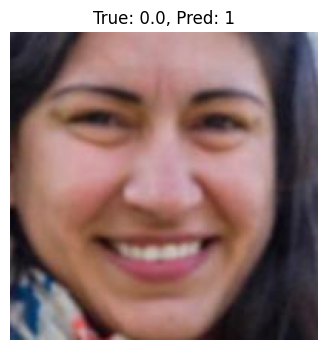

  0%|          | 0/1000 [00:00<?, ?it/s]

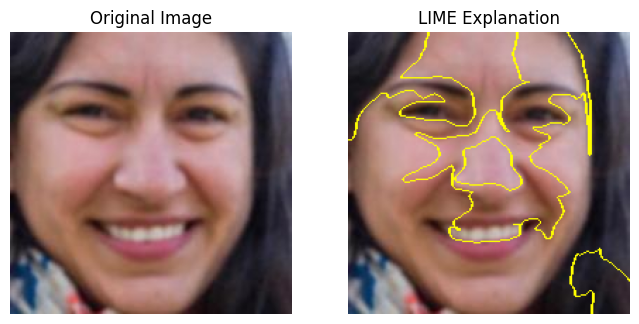

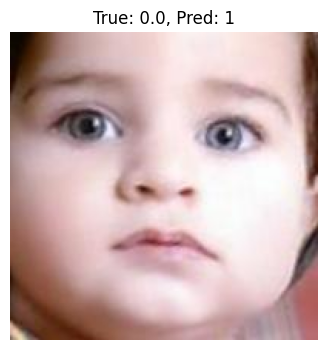

  0%|          | 0/1000 [00:00<?, ?it/s]

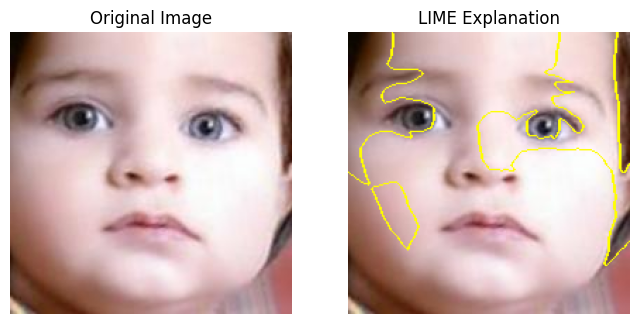

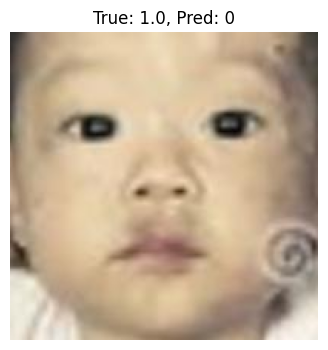

  0%|          | 0/1000 [00:00<?, ?it/s]

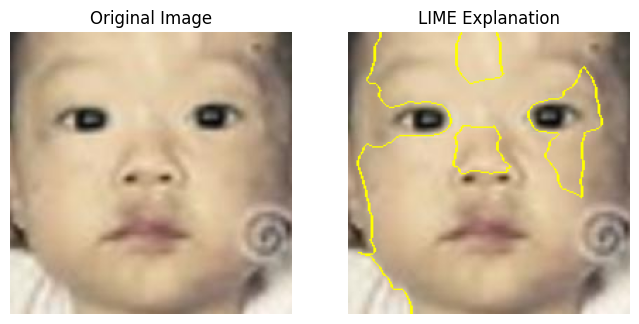

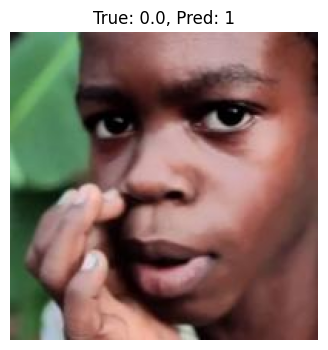

  0%|          | 0/1000 [00:00<?, ?it/s]

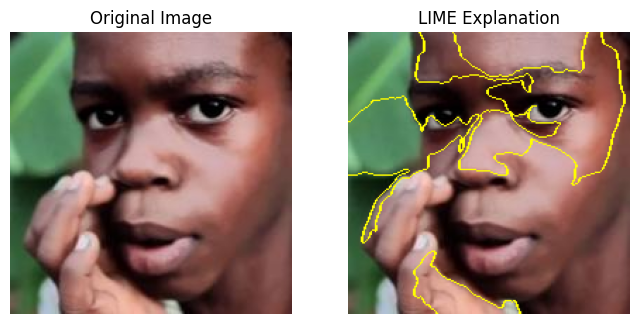

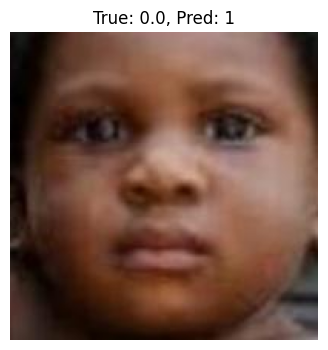

  0%|          | 0/1000 [00:00<?, ?it/s]

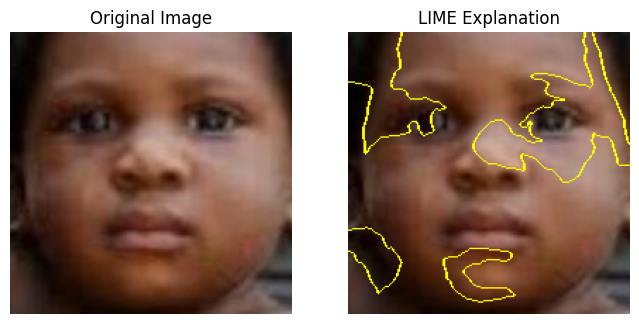

In [ ]:
misclassified_gender = eval_df[eval_df["True Gender"] != eval_df["Predicted Gender"]]
visualize_gender_samples(misclassified_gender, model, device, num_samples=5, lime=True)

If we have closer at the images that have gender missclassified we can see that eyes and nose regions are consistently highlighted in the explanations and seems that model rely on these features when it is assigning higher probability to females. Areas like hairline or mouth or face structure are not highlithed and could potentially be important as well. Another issue is that we can see that model seems to be taking in the account the background noice as in some pictures we see some part of it highlighted like in the 4th picture. One solution could be not to do the padding and just resize images. Also it would be interesting to implement attention mechanism which could give weights to more important regions and pay less attention to the not so relavant parts for the classification.

### Results and conclusions

We have explored several models briefly, MobileNetV2 and VGG16 showed most promise. It would be interesting to explore VGG16 more extensively and compare the results with MobileNetV2. Additionaly we ran 20 hyperparameters optuna trials for 1 epoch and based our training on the trial results. These hyperparameters: `learning_rate': 0.00016277082236748248, 'dropout_rate': 0.4825418581622139, 'weight_decay': 8.365806893223885e-06, 'batch_size': 16, 'unfreeze_layers': 0, 'optimizer': 'Adam'` yielded lowest total validation loss. Later on gender sample weights and images augmentation were implemented and improved gender classification results, however model was slightly overfitting. In efforts to address tht learning rate scheduler and total loss scalling was used, plots showed some improvement to the overfitting, but gender classification results were not changing, it was only improving age regression part.
Below is a summary of models results. We are including only the best baseline model results for the comparison.

| **Model Configuration**                                          | **Weighted Avg Accuracy** | **Weighted Avg F1 Score** | **Age MAE** | **Age RMSE** | **Description**                                                                                  |
|-------------------------------------------------------------------|---------------------------|---------------------------|-------------|--------------|----------------------------------------------------------------------------------------------|
| **Baseline MobileNETV2 Model**                                               | 82%                       | 82%                       | 9.58         | 12.37          | Only the output layer was trained, the rest of the model frozen. |
| **MobileNETV2 Model without sample weights**                                 | 90%                       | 90%                       | 6.61        | 8.69         | All layers of the model were trained using hyperparameters from the optuna trial.       |
| **MobileNETV2 Model with sample weights**                                    | 92%                       | 92%                       | 5.91        | 8.14         | Sample weights were introduced for gender.  |
| **MobileNETV2 Model with sample weights and image augmentation**             | 93%                       | 93%                       | 5.51        | 7.76         | Added image augmentations.    |
| **MobileNETV2 Model with sample weights, augmentation, and LR scheduler**    | 93%                       | 93%                       | 5.38        | 7.54         | Integrated a learning rate scheduler to adjust learning rates during training.      |
| **MobileNETV2 Model with weights, augmentation, LR scheduler, and modified total loss weights** | 93%          | 93%                       | 5.24        | 7.41         | Adjusted total loss weights: 45% gender and 55% age loss. |

 **Test results**



```
 precision    recall  f1-score   support

        Male       0.96      0.91      0.93      1794
      Female       0.91      0.95      0.93      1636

    accuracy                           0.93      3430
   macro avg       0.93      0.93      0.93      3430
weighted avg       0.93      0.93      0.93      3430
```



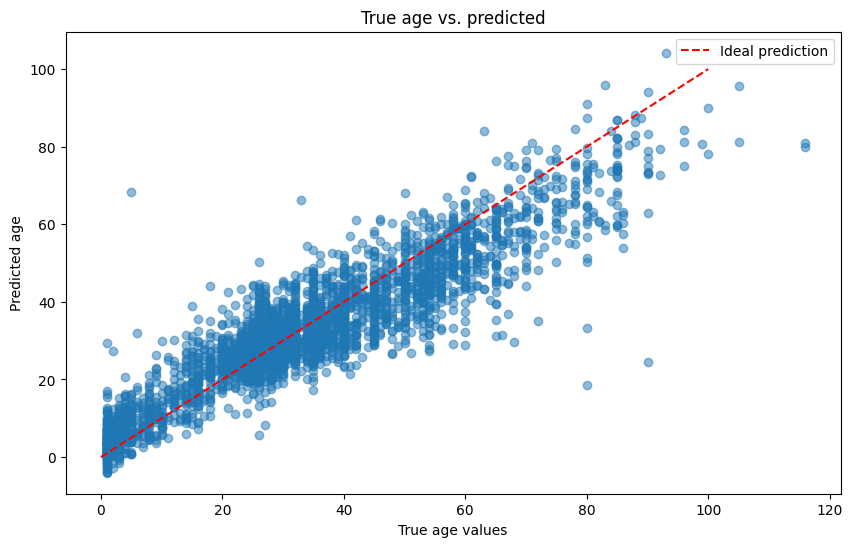



```
Age Mean Absolute Error (MAE): 5.16
Age Root Mean Squared Error (RMSE): 7.21

Male Age MAE: 5.48
Female Age MAE: 4.82

Metrics grouped by Age Group:
              Age MAE  Gender Accuracy
Age Group                             
Adult        7.079759         0.984273
Child        3.093766         0.730769
Senior       7.957410         0.964876
Teen         6.001584         0.906433
Young Adult  3.885126         0.962451

Metrics grouped by Race:
       Age MAE  Gender Accuracy
Race                           
0     5.722077         0.941217
1     5.251937         0.934451
2     4.171185         0.904192
3     4.964251         0.926957
4     4.019482         0.931915

```



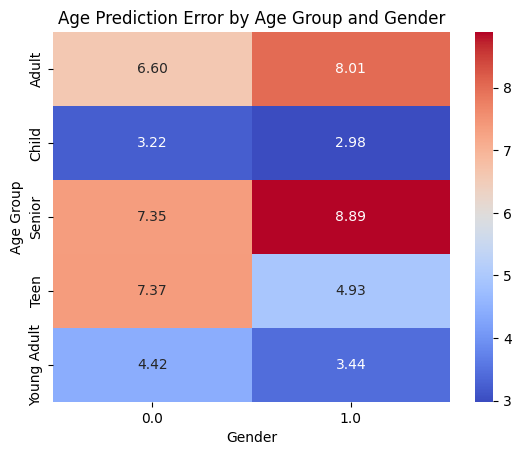

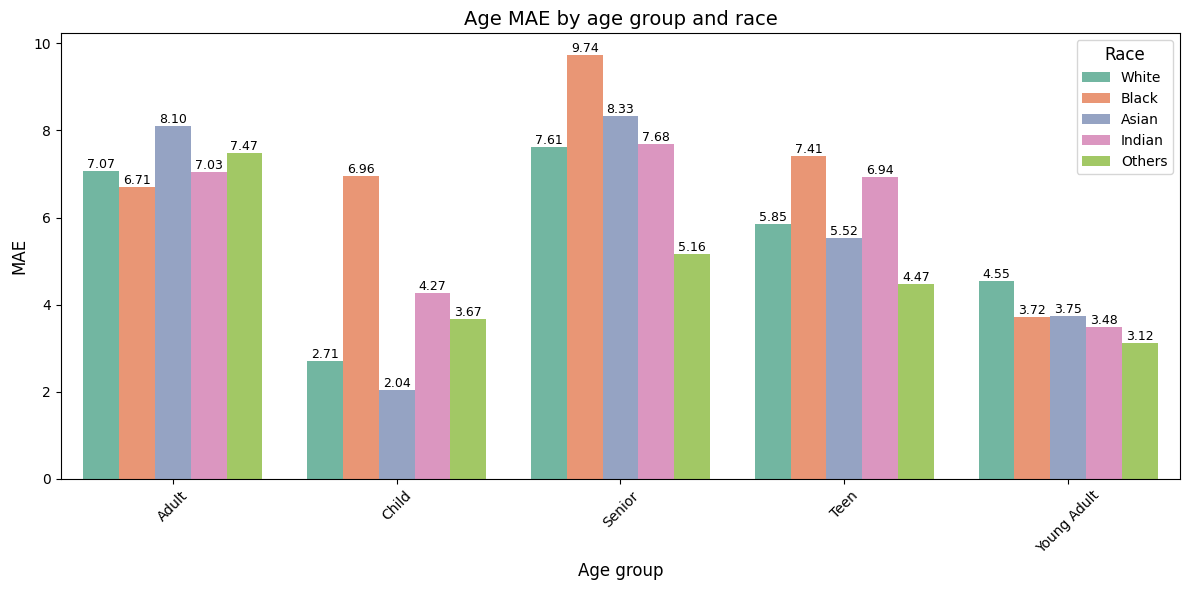

We observed that gender accuracy and age MAE vary significantly across different groups indicating biased results. This aligns with some imbalances present in the data. We identified some biases possibly coming from the dataset like in adult age group where males have better MAE results than females as well as others that require deeper investigation such as the unexpected age regression results among teenagers which images were approximately balanced. A closer look at the images is we think necessary to better understand these anomalies.

**Future directions and possible actions:**

1. Targeted augmentation and data balancing

Given the imbalances in results across gender, race and age groups targeted augmentation could help focus on underrepresented groups.Also synthetic data generation using generative adversarial netowrks to create new data and balance the dataset more effectively at those group level.

2. Exploration of VGG16 architecture

While MobileNetV2 was the backbone selected VGG16 demonstrated promising results. This suggests that VGG16 might outperform MobileNetV2 if explored more extensively.

3. Hyperparameter optimization

Although Optuna provided a good starting point the hyperparameter search space was only slightly explored. Expanding the hyperparameter search could reveal configurations that could yield better performance.

4. LIME analysis

From the LIME analysis we observed that the model sometimes focuses on background noise and doesn't highlight important facial features such as the hairline or mouth area. Introducing an attention mechanism to the model could prioritize important regions in the image by assigning higher weights to them and minimize reliance on those less relevant areas possibly improving both gender classification and age regression results.